# Imports

In [254]:
# Imports and setup
import pandas as pd
from pandas.plotting import scatter_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import GroupKFold
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import GroupShuffleSplit 


from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mutual_info_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler


from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import HuberRegressor

import xgboost as xgb
from xgboost import XGBRegressor
from xgboost import XGBClassifier

from sklearn.ensemble import StackingRegressor

from sklearn.feature_selection import mutual_info_regression 
from sklearn.feature_selection import f_regression

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder

from sklearn import metrics


import category_encoders as ce

from datetime import datetime
import time
from IPython.display import display, HTML

from scipy.stats import gaussian_kde
from scipy.stats import norm
from scipy import stats
from scipy.stats import mannwhitneyu

import os
import itables
from itables import show
import warnings
from typing import Protocol
from sklearn.exceptions import ConvergenceWarning


pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Constants

In [2]:
# Some useful constants
TARGET_COL = "SalePrice"
LOGP_TARGET_COL = f"{TARGET_COL}_log1p"
RANDOM_STATE = 0
TEST_PORCENT = 0.2  # Proportion of the dataset to include in the test split
MAX_OHE_CARDINALITY = 18  # Maximum unique values for one-hot encoding

g_df_scores = pd.DataFrame() #  DataFrame to store scores
g_run_id = 0  # Global run id to use in scores


# Columns

In [129]:
# Ordinal Columns
# OverallCond and OverallQuall are ordinal but no process is necessary

ORD_COLS_VALUES = { 
    "LandSlope": {"Gtl": 1, "Mod": 2, "Sev": 3},
    "ExterQual": {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1},
    "ExterCond": {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1},
    "BsmtQual": {"Ex": 10, "Gd": 9, "TA": 8, "Fa": 7, "Po": 3, "NA": 0},
    "BsmtCond": {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1, "NA": 0},
    "BsmtExposure": {"Gd": 5, "Av": 4, "Mn": 3, "No": 2, "NA": 0},
    'HeatingQC':{'Ex':5,'Gd':4,'TA':3,'Fa':2,'Po':1},
    "KitchenQual": {'Ex':5,'Gd':4,'TA':3,'Fa':2,'Po':1},
    'FireplaceQu':{'Ex':10,'Gd':9,'TA':8,'Fa':7,'Po':3,'NA':0},
    'GarageQual':{'Ex':10,'Gd':9,'TA':8,'Fa':7,'Po':3,'NA':0},
    'GarageCond':{'Ex':10,'Gd':9,'TA':8,'Fa':7,'Po':3,'NA':0},
    'PoolQC' : {'Ex' :10 , 'Gd' :9 , 'TA' :8 , 'Fa' :7 , 'Po' :3 , 'NA' :0},
}

ORD_COLS = list(ORD_COLS_VALUES.keys())

## Class categories
CLASS_COLS_VALUES = {
    "MSSubClass": [20, 30, 40, 45, 50, 60, 70, 75, 80, 85, 90, 120, 150, 160, 180, 190],
    "MSZoning": ["A", "C", "FV", "I", "RH", "RL", "RP", "RM"],
    "Street": ["Grvl", "Pave"],
    "Alley": ["Grvl", "Pave", "NA"],
    "LotShape": ["Reg", "IR1", "IR2", "IR3"],
    "LandContour": ["Lvl", "Bnk", "HLS", "Low"],
    "Utilities": ["AllPub", "NoSewr", "NoSeWa", "ELO"],
    "LotConfig": ["Inside", "Corner", "CulDSac", "FR2", "FR3"],
    "LandSlope": ["Gtl", "Mod", "Sev"],
    "Condition1": ["Artery", "Feedr", "Norm", "RRNn", "RRAn", "PosN", "PosA", "RRNe", "RRAe"],
    "Condition2": ["Artery", "Feedr", "Norm", "RRNn", "RRAn", "PosN", "PosA", "RRNe", "RRAe"],
    "BldgType": ["1Fam", "2FmCon", "Duplx", "TwnhsE", "TwnhsI"],
    "HouseStyle": ["1Story", "1.5Fin", "1.5Unf", "2Story", "2.5Fin", "2.5Unf", "SFoyer", "SLvl"],
    "RoofStyle": ["Flat", "Gable", "Gambrel", "Hip", "Mansard", "Shed"],
    "RoofMatl": ["ClyTile", "CompShg", "Membran", "Metal", "Roll", "Tar&Grv", "WdShake", "WdShngl"],
    "Exterior1st": ["AsbShng", "AsphShn", "BrkComm", "BrkFace", "CBlock", "CemntBd", "HdBoard", "ImStucc", "MetalSd", "Other", "Plywood", "PreCast", "Stone", "Stucco", "VinylSd", "Wd Sdng", "WdShing"],
    "Exterior2nd": ["AsbShng", "AsphShn", "BrkComm", "BrkFace", "CBlock", "CemntBd", "HdBoard", "ImStucc", "MetalSd", "Other", "Plywood", "PreCast", "Stone", "Stucco", "VinylSd", "Wd Sdng", "WdShing"],
    "MasVnrType": ["BrkCmn", "BrkFace", "CBlock", "None", "Stone"],
    "Foundation": ["BrkTil", "CBlock", "PConc", "Slab", "Stone", "Wood"],
    "Heating": ["Floor", "GasA", "GasW", "Grav", "OthW", "Wall"],
    "Electrical": ["SBrkr", "FuseA", "FuseF", "FuseP", "Mix"],
    "Functional": ["Typ", "Min1", "Min2", "Mod", "Maj1", "Maj2", "Sev", "Sal"],
    "GarageType": ["2Types", "Attchd", "Basment", "BuiltIn", "CarPort", "Detchd", "NA"],
    "GarageFinish": ["Fin", "RFn", "Unf", "NA"],
    "PavedDrive": ["Y", "P", "N"],
    "MiscFeature": ["Elev", "Gar2", "Othr", "Shed", "TenC", "NA"],
    "SaleType": ["WD", "CWD", "VWD", "New", "COD", "Con", "ConLw", "ConLI", "ConLD", "Oth"],
    "SaleCondition": ["Normal", "Abnorml", "AdjLand", "Alloca", "Family", "Partial"], 
    "CentralAir": ["Y", "N"],
    "BsmtFinType1": ["GLQ", "ALQ", "BLQ", "Rec", "LwQ", "Unf", 'NA'],
    'BsmtFinType2': ['GLQ','ALQ','BLQ','Rec','LwQ','Unf','NA'],
    "Fence": ["GdPrv", "MnPrv", "GdWo", "MnWw", "NA"],
}

CLASS_COLS = list(CLASS_COLS_VALUES.keys())

# Functions

## Print Info Functions

In [4]:
def print_null_count(df, col_name):
    """
    Print the number of null values in a specific column of a DataFrame.

    Parameters:
    df (pd.DataFrame): The DataFrame to check.
    col_name (str): The name of the column to check for null values.
    """
    print(f"Column '{col_name}' has {df[col_name].isnull().sum()} null values.")

def println(ch="-", n=30):
  print(ch * n)

def printspace():
  println(ch=" ")

def show_global_scores():
    global g_df_scores
    display(g_df_scores)


## Plot functions

In [5]:
def compute_fig_matrix_size(features):
  plot_count = len(features)
  if plot_count == 0:
    return
    
  # Show 'num_cols' plots per row
  col_count = min(plot_count, 3)
  row_count = plot_count // col_count
  row_count += 0 if (plot_count % col_count) == 0 else 1
  
  return row_count, col_count

### Show Histograms

In [6]:

def show_histogram(data, features, debug=False):
  build_bar_plot(data, features, ptype="histogram", debug=debug)
  
def show_bar_plot(data, features, debug=False):
  build_bar_plot(data, features, ptype="bar", debug=debug)

def build_bar_plot(data, features, ptype="bar", debug=False):
    if type(features) is not list:
        features = [features]

    row_count, num_cols = compute_fig_matrix_size(features)
    # Create subplots
    fig, axes = plt.subplots(ncols=num_cols, nrows=row_count, figsize=(10, 10), squeeze=False)
    fig.tight_layout(pad=2.0)

    curr_row = 0
    curr_col = 0
    for feat_idx, feat_name in enumerate(features):
        if debug:
            print("Processing feature:", feat_name)
        curr_row = feat_idx // num_cols
        ax = axes[curr_row, curr_col]
        if ptype == "histogram":
          ax.hist(data[feat_name], bins=30, color="skyblue", alpha=0.7, edgecolor="black", density=True)
        elif ptype == "bar":
          categories = data[feat_name].unique()
          counts =  data[feat_name].value_counts()
          #print("Categories for", feat_name, ":", categories)
          #print("counts for", feat_name, ":", counts)
          ax.bar(categories, counts) 
        ax.set_title("")
        ax.set_xlabel(feat_name)
        ax.set_ylabel("Frequency") 
        if curr_col == num_cols - 1:
            curr_col = 0
        else:
            curr_col += 1

    # Show plot
    plt.show()

### Show Distribution

In [7]:
def show_distribution(data, features, debug=False):
    if type(features) is not list:
        features = [features]

    plot_count = len(features)
    if plot_count == 0:
        return


    # Show 'num_cols' plots per row
    num_cols = min(plot_count, 3)
    row_count = plot_count // num_cols
    row_count += 0 if (plot_count % num_cols) == 0 else 1
    # Create subplots
    fig, axes = plt.subplots(ncols=num_cols, nrows=row_count, figsize=(10, 5), squeeze=False)
    fig.tight_layout(pad=2.0)

    curr_row = 0
    curr_col = 0
    for feat_idx, feat_name in enumerate(features):
        if debug:
          print("Processing feature:", feat_name)
        kde = gaussian_kde(data[feat_name])
        mu, sigma = np.mean(data[feat_name]), np.std(data[feat_name])
        x_vals = np.linspace(data[feat_name].min(), data[feat_name].max(), 200)

        curr_row = feat_idx // num_cols
        ax = axes[curr_row, curr_col]
        ax.plot(x_vals, kde(x_vals), color="red", lw=2)
        ax.plot(x_vals, norm.pdf(x_vals, mu, sigma), color="yellow", lw=2)
        ax.hist(data[feat_name], bins=30, color="skyblue", alpha=0.7, edgecolor="black", density=True)
        #ax.set_title(f"Distribution for {feat_name}")
        ax.set_title("")
        ax.set_xlabel(feat_name)
        ax.set_ylabel("Frequency") 
        if curr_col == num_cols - 1:
            curr_col = 0
        else:
            curr_col += 1

    # Show plot
    plt.show()

### Show Q-Q Plot

In [8]:
def show_qq_plot(df, features):
  if type(features) is not list:
    features = [features]
    
  plot_count = len(features)
  if plot_count == 0:
    return

  # Show 'num_cols' plots per row
  num_cols = min(plot_count, 3)
  row_count = plot_count // num_cols
  row_count += (0 if plot_count % num_cols == 0 else 1)
  print("Row count", row_count)
  # Create subplots
  curr_row = 0
  curr_col = 0
  fig, axes = plt.subplots(ncols=num_cols, nrows=row_count, figsize=(7, 5), squeeze=False)
  fig.tight_layout(pad=2.0)
  for i, f in enumerate(features):
    curr_row = i // num_cols
    ax = axes[curr_row, curr_col]
    stats.probplot(df[f], dist="norm", plot=ax)
    ax.set_ylabel(f)
    ax.set_xlabel("q") 
    ax.set_title(f"Q-Q Plot for {f}")
    if curr_col == num_cols - 1:
      curr_col = 0
    else:
      curr_col += 1
  plt.show()

### Scores

In [9]:
def clear_global_scores():
  global g_df_scores
  global g_run_id
  g_run_id = 0
  g_df_scores = pd.DataFrame()

def mark_failed_score(run_id):
  g_df_scores.loc[g_df_scores["run_id"] == run_id, "failed"] = True

SHOW_ALL="all"
SHOW_LAST_10="last_10"
SHOW_LABEL="label"
SHOW_BEST_5="best_5"
def plot_scores(show_test=False, show=SHOW_LAST_10, label=""):

  df = g_df_scores.copy()

  if show == SHOW_LAST_10:
    df = df.tail(10)
  elif show == SHOW_LABEL:
    df = df[df["run_label"] == label]
  elif show == SHOW_BEST_5:
    df = df.sort_values(by="CV_MEAN").tail(5)
    
  # Combine model + run label for easier plotting
  df["model_run"] = df["model"].astype(str) + "\n(" + df["run_label"].astype(str) + ")"

  # Assign a unique color per model
  unique_models = df["model"].unique()
  colors = plt.cm.tab10(range(len(unique_models)))  # 10 distinct colors
  color_map = dict(zip(unique_models, colors))

  # Map the colors to each row
  df["color"] = df["model"].map(color_map)

  # Set figure and subplots
  splot_count = 2
  if show_test:
    splot_count = 3

  fig, axes = plt.subplots(splot_count, 1, figsize=(14, 5))

  axnum = 0
  # --- Bar chart for Train RMSE ---
  bars = axes[axnum].bar(df["model_run"], df["TRN_RMSE"], color=df["color"])
  axes[axnum].set_title("Train set (RMSE)")
  axes[axnum].set_ylabel("RMSE")
  axes[axnum].bar_label(bars, fmt="%.4f", rotation=90, padding=3)   

  if show_test:
    axnum += 1
    # --- Bar chart for Test RMSE ---
    bars = axes[axnum].bar(df["model_run"], df["TST_RMSE"], color=df["color"])
    axes[axnum].set_title("Test set (RMSE)")
    axes[axnum].set_ylabel("RMSE")
    axes[axnum].bar_label(bars, fmt="%.4f", rotation=90, padding=3)

  # --- Bar chart for CV_MEAN ---
  axnum += 1
  bars = axes[axnum].bar(df["model_run"], df["CV_MEAN"], color=df["color"])
  axes[axnum].set_title("Cross validation (CV_MEAN)")
  axes[axnum].set_ylabel("CV_MEAN")
  axes[axnum].bar_label(bars, fmt="%.4f", rotation=90, padding=3)

  plt.tight_layout()
  plt.show() 

### Show Scores Stats

In [10]:
def show_run_desc(run_id, model):
    df = g_df_scores[g_df_scores["run_id"] == run_id]
    df = df[df["model"] == model]
    df = df.iloc[0]
    print("RunId:", f"{run_id} ({df["run_label"]}) - model:", df["model"], ("[Failed]" if df["failed"] else ""))
    print("Score:", nfmt(df["CV_MEAN"]), "- TRN_RMSE:", nfmt(df["TRN_RMSE"]))
    print("Description:")
    print(g_df_scores[g_df_scores["run_id"] == run_id]["DESC"]) 

#show_run_desc(103, "Rig")

In [402]:
def show_scores_stats(by_label_list=False, process_time=False, by_model_desc=False, show_test=False, run_id=None):
  global g_df_scores
  curr_validation_tag = "GroupKFolds+cross_val_score"
  df_base = g_df_scores[g_df_scores["failed"] == False].copy()
  # Adding filter to display values after changing cross val split
  df_base = df_base[df_base["validation_tag"] == curr_validation_tag]
  # Adding variance from train and cv
  df_base["VAR"] = df_base["CV_MEAN"] - df_base["TRN_RMSE"]

  if run_id is None:
      run_id = df_base["run_id"].max()
  df_last = df_base[df_base["run_id"] == run_id]
  println()

  """
   Display last experiment run data
  """
  print("Last Run:", df_last["run_id"].iloc[0], "-", df_last["run_label"].iloc[0])
  println()
  for i, row in df_last.iterrows():
    line = f"Model: {row["model"]} CV_MEAN: {nfmt(row['CV_MEAN'])} \
    ({nfmt(row['CV_STD'])}), TRN_RMSE: {nfmt(row['TRN_RMSE'])}, VAR: {nfmt(row["VAR"])}"
    if show_test:
      line+= f" TST_RMSE: {nfmt(row["TST_RMSE"])}"
    print(line)
  print("Description:", df_last["DESC"].iloc[0])

  """
    Display average by Run Label
  """
  if by_label_list:
    df = df_base.groupby("run_label")
    println()
    print("Score Stats")
    println()
    for name, group in df:
      print("Name:", name)
      print("Avg Tr:", nfmt(group["TRN_RMSE"].mean()))
      print("Avg CV:", nfmt(group["CV_MEAN"].mean()), f"({nfmt(group["CV_STD"].mean())})")
      if show_test:
        print("Avg Test:", nfmt(group["TST_RMSE"].mean()))
      df_grp_best = group[group["CV_MEAN"] == group["CV_MEAN"].min()].iloc[0]

      proc_time = ""
      if process_time:
        proc_time = "Proc.Time:" + nfmt(df_grp_best["EVAL_TIME_SEC"]) + "secs"

      """
       Best by Run Label detail
      """
      print("Best(CV):", f"[{df_grp_best['run_label']}]", f"({df_grp_best['run_id']})", df_grp_best["model"], \
            "--> Score:", nfmt(df_grp_best["CV_MEAN"]), f"({nfmt(df_grp_best['CV_STD'])})", \
            f", VAR: {nfmt(row["VAR"])}")
      print("Description:")
      print(df_grp_best["DESC"])
      printspace()

  """
   Display Top  5 run performances CV
  """
  rank = df_base.copy().sort_values(by="CV_MEAN", ascending=True).reset_index(drop=True)
  rank["delta"] = rank["CV_MEAN"] - rank["CV_MEAN"].shift(1)
  println()
  print("Top 5 (CV)")
  println()
  for i, row in rank[:5].iterrows():
    proc_time = ""
    if process_time:
      proc_time = f"Proc.Time: {nfmt(row['EVAL_TIME_SEC'])} secs"
    print(f"{row['run_label']}({row['run_id']}) - {row['model']} --> CV_MEAN: {nfmt(row['CV_MEAN'])}, \
    {nfmt(row['CV_STD'])}, delta: {nfmt(row['delta'])}", f", VAR: {nfmt(row["VAR"])}", proc_time)

  printspace()
  println()

  """
   Display Top  5 run performances by less VAR (CV - TRN) 
  """
  var_rank = df_base.copy().sort_values(by="VAR", ascending=True).reset_index(drop=True)
  println()
  print("Top 5 VAR (CV - TRN)")
  println()
  for i, row in var_rank[:5].iterrows():
    proc_time = ""
    if process_time:
      proc_time = f"Proc.Time: {nfmt(row['EVAL_TIME_SEC'])} secs"
    print(f"{row['run_label']}({row['run_id']}) - {row['model']} --> CV_MEAN: {nfmt(row['CV_MEAN'])}, \
    {nfmt(row['CV_STD'])}", f", VAR: {nfmt(row["VAR"])}", proc_time)

  printspace()
  println()

  """
   Display Top  5 run TEST performances
  """
  rank = df_base.copy().sort_values(by="TST_RMSE", ascending=True).reset_index(drop=True)
  rank["delta"] = rank["TST_RMSE"] - rank["TST_RMSE"].shift(1)
  println()
  print("Top 5 (TEST)")
  println()
  for i, row in rank[:5].iterrows():
    proc_time = ""
    if process_time:
      proc_time = f"Proc.Time: {nfmt(row['EVAL_TIME_SEC'])} secs"
    print(f"{row['run_label']}({row['run_id']}) - {row['model']} --> TEST RMSE: {nfmt(row['TST_RMSE'])}, delta: {nfmt(row['delta'])}", proc_time)

  printspace()
  println()
  
  # Global Best detail
  gdf = df_base.copy()
  df_best = gdf[gdf["CV_MEAN"] == gdf["CV_MEAN"].min()].iloc[0]
  line = f"Global Best(CV): [{df_best['run_label']}] ({df_best['run_id']}) {df_best['model']}, \
        --> Score: {nfmt(df_best['CV_MEAN'])} ({nfmt(df_best['CV_MEAN'])})"
  if show_test:
    line+= "TST_RMSE: " + nfmt(df_best["TST_RMSE"])
  print(line)
  if process_time:
    print("Process time:", nfmt(df_best["EVAL_TIME_SEC"]), "sec")
  print("Description:")
  print(df_best["DESC"])

  # Top five by Run Id. Average of CV_MEAN
  df = df_base.groupby("run_id").agg({"CV_MEAN": "mean", "CV_STD": "mean", "TRN_RMSE": "mean"}).sort_values(by="CV_MEAN", ascending=True)
  println()
  print("Top 5 Mean by run_id")
  println()
  for run_id, group in df[:5].iterrows():
    print(f"{run_id} --> CV_MEAN: {nfmt(group['CV_MEAN'])}({nfmt(group['CV_STD'])}), TRN_RMSE: {nfmt(group['TRN_RMSE'])}")
  printspace()
  println()
  if df.shape[0] > 0:
    run_id = df.iloc[0].name
    df = df_base[df_base["run_id"] == run_id]
    #  Global Best by Run Id detail
    print("Best AVG CV: ", f"({run_id}) --> Score:", nfmt(df["CV_MEAN"].mean()), f"({nfmt(df['CV_STD'].mean())})", "- TRN_RMSE:", nfmt(df["TRN_RMSE"].mean()))
    print("Description:")
    print(g_df_scores[g_df_scores["run_id"] == run_id].iloc[0]["DESC"]) 

  # Best by model list
  df_model = df_base.groupby("model")

  print("Best by Model")
  println()
  for model, group in df_model:
    df_best = group[group["CV_MEAN"] == group["CV_MEAN"].min()].iloc[0]
    line = f"{model} Run Id: {df_best['run_id']} ({df_best["run_label"]}) -> CV_MEAN: {nfmt(df_best['CV_MEAN'])}  \
          ({nfmt(df_best['CV_STD'])}) TRN_RMSE: {nfmt(df_best['TRN_RMSE'])})"
    if by_model_desc:
      print("Description:")
      print(df_best["DESC"])



#show_scores_stats()

## Show Target Pairplot

In [12]:
def show_target_pairplot(df, features, target):
  if type(features) is not list:
    features = [features]

  plot_count = len(features)
  if plot_count == 0:
    return

  # Show 'num_cols' plots per row
  num_cols = min(plot_count, 3)
  row_count = plot_count // num_cols
  row_count += (0 if plot_count % num_cols == 0 else 1)
  # Create subplots
  curr_row = 0
  curr_col = 0
  fig, axes = plt.subplots(ncols=num_cols, nrows=row_count, figsize=(9, 9), squeeze=False)
  fig.tight_layout(pad=2.0)
  for i, f in enumerate(features):
    curr_row = i // num_cols
    ax = axes[curr_row, curr_col]
    ax.plot(df[f], df[target], ".")
    ax.set_ylabel(target)
    ax.set_xlabel(f)
    #ax.set_title(f"Pair Plot {f} - {target}") // Consumes spaces
    if curr_col == num_cols - 1:
      curr_col = 0
    else:
      curr_col += 1
  plt.show()

## Metrics Functions

In [302]:
# Metric functions 
def compute_rmse(y, y_pred):
  """Compute Root Mean Squared Error (RMSE)"""
  return root_mean_squared_error(y, y_pred)

def compute_nrmse(y, y_pred):
  """Computes Normalized Root Mean Squared Error (NRMSE)"""
  rmse = compute_rmse(y, y_pred)
  return rmse / np.mean(y)

def compute_perc_nrmse(y, y_pred):
  return compute_nrmse(y, y_pred) * 100

def compute_metrics(y, y_pred):
  result = {}
  result["RMSE"] = compute_rmse(y, y_pred)
  result["NRMSE"] = compute_nrmse(y, y_pred)
  result["PERC_NRMSE"] = compute_perc_nrmse(y, y_pred)
  return result

def mean(vals):
  return vals.mean() if len(vals) > 0 else 0

## Eval functions

### Models Config

In [547]:





# v3 params // Using second approach
# xgbreg_params ={'learning_rate': 0.1, 'n_estimators': 82, 'max_depth': 3, 'min_child_weight': 3.253085737531595, 'subsample': 0.5969192662698124, 'colsample_bytree': 0.7320808520425763, 
#                 'gamma': 0.012199053588004086, 'reg_lambda': 1.001187324408089, 'random_state': 0, 'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'tree_method': 'hist', 
#                 'n_jobs': -1, 'seed': 27}

# XGBRegressor
# Using intentionally max_depth == 2 and subsample=0.5 to try to reduce overfitting.
# Also, reg_lambda and reg_alpha are set to prevent that
xgbreg_params = {"enable_categorical": True, 'learning_rate': 0.03, 'n_estimators': 3000, 'max_depth': 2, 'min_child_weight': 0.8547846749285817,
                 'colsample_bytree': 0.15395734275277406, 'subsample': 0.5, 'gamma': 0.008263817764264547, 'random_state': 0, 
                 'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'tree_method': 'hist', 'n_jobs': -1, 'seed': 27}

#elnet_params = {'alpha': 0.0002559547922699536, 'l1_ratio': np.float64(0.9713602349430156), 'fit_intercept': True, 
#'precompute': False, 'max_iter': 20000, 'copy_X': True, 'tol': np.float64(0.009736102524944824), 'warm_start': False, 
#'positive': False, 'random_state': 0, 'selection': 'cyclic'}
elnet_params = {'alpha': np.float64(0.011089127410497343), 'l1_ratio': np.float64(0.12313725726547456), 'fit_intercept': True,
                'precompute': False, 'max_iter': 20000, 'copy_X': True, 'tol': np.float64(0.00437146274561372), 'warm_start': False,
                'positive': False, 'random_state': 0, 'selection': 'cyclic'}


alpha_ridge = 4.641588833612782
alpha_ridge = 10.0#4.641588833612782

alpha_ridge_stk1 = 0.8019597659954303

def get_xgb_params():
  return xgbreg_params

def get_ridge_alpha():
  return alpha_ridge

def get_ridge_sk1_alpha():
  return alpha_ridge_stk1

def get_elnet_params():
  return elnet_params


lasso_params = {
        "alpha": 0.0007187203411199203, "fit_intercept": True, "precompute": False, "max_iter": 20000,
        "copy_X": True, "tol": 0.0038968245196834795, "warm_start": False, "positive": False,
        "random_state": RANDOM_STATE, "selection": "cyclic"
    }

def add_step_to_pip(pip, step_name, step):
  steps = pip.steps.copy()
  steps.append((step_name, step))
  return Pipeline(steps)

def add_model_step_to_pip(pip, step):
  return add_step_to_pip(pip, "model", step)

### Commented for now. To remove. 
### Replaced by build_full_pipeline
def create_stack_1(pips):
  linear_pip = pips[0]
  tree_pip = pips[1]
  estimators = [
    #('Rig', Ridge(alpha=alpha_ridge)),
    #("Lasso", Lasso(**lasso_params)),
    ('LiRe', add_model_step_to_pip(linear_pip, LinearRegression())),
    ('XBReg', add_model_step_to_pip(tree_pip, XGBRegressor(**xgbreg_params))),
    ('ENet', add_model_step_to_pip(linear_pip, ElasticNet(**elnet_params))),
  ]
  return StackingRegressor(
    estimators=estimators,
    #final_estimator=Lasso(**lasso_params),
    final_estimator=Ridge(alpha=alpha_ridge_stk1),
  )

# def create_stack_2():
#   estimators = [
#     ('XBReg', XGBRegressor(**xgbreg_params)),
#     ("Lasso", Lasso(**lasso_params)),
#     ('Rig', Ridge(alpha=alpha_ridge)),
#     ('ENet', ElasticNet(**elnet_params)),
#   ]
#   return StackingRegressor(
#     estimators=estimators,
#     final_estimator=Ridge(alpha=alpha_ridge_stk1),
#   )

def get_models():
    return [
        {
          "name": "Linear Regression",
          "abrev": "LiRe",
          "instance": LinearRegression(),
        },
        {
          "name": "Lasso",
          "abrev": "Lasso",
          "instance": Lasso(**lasso_params),
        },
        {
          "name": "ElasticNet",
          "abrev": "ENet",
          "instance": ElasticNet(**elnet_params),
        },
        {
          "name": "Ridge",
          "abrev": "Rig",
          "instance": Ridge(alpha=alpha_ridge),
        },
        {
          "name": "Ridge Final Stk1",
          "abrev": "RiFS1",
          "instance": Ridge(alpha=alpha_ridge_stk1),
        },
        # {
        #   "name": "Huber Regressor",
        #   "abrev": "HuRe",
        #   "instance": HuberRegressor(alpha=alpha_ridge),
        # },
        {
          "name": "XGBRegressor",
          "abrev": "XBReg",
          "instance": XGBRegressor(**xgbreg_params),
          "type": "tree",
        },
        {
          "name": "Stack1",
          "abrev": "Stk1",
          "estimators":  {"weak": ["LiRe", "XBReg", "ENet"], "final": "RiFS1" },
          "type": "stack",
        },
        {
          "name": "Stack2",
          "abrev": "Stk2",
          "estimators":  {"weak": ["XBReg", "Lasso", "ENet"], "final": "RiFS1" },
          "type": "stack",
        }
    ]

def get_model(abrev, debug=False):
  model = [model for model in get_models() if model["abrev"] == abrev]
  if len(model) == 0:
    raise ValueError(f"Model with abrev '{abrev}' not found.")

  print(model[0])
  if model[0].get("type", "linear") == "stack":
    print("Stack model cannot be return in this function")
    return None

  if debug:
    print("Parameters:", model["instance"].get_params())
  return model[0]["instance"]

def list_models():
  for model in get_models():
    print(f"{model['abrev']}: {model['name']}")

def get_model_abrevs():
  return [x["abrev"] for x in get_models()]

def get_model_config(abrev):
  model = [model for model in get_models() if model["abrev"] == abrev]
  if len(model) == 0:
    raise ValueError(f"Model with abrev '{abrev}' not found.")
  return model[0]



### Evaluation

#### Helpers

In [545]:
# Evaluation functions
def build_full_pipeline(trans_pip, model_cfg):
    """
    Builds a full machine learning pipeline by combining a transformation pipeline with a model configuration.

    Parameters:
        trans_pip: List of transformation pipelines (e.g., for linear or tree models).
        model_cfg (dict or str): Configuration name or dictionary specifying the model type and its parameters.

    Returns:
        A scikit-learn compatible pipeline or estimator.
    """
    if isinstance(model_cfg, str):
      model_cfg = get_model_config(model_cfg)

    model_type = model_cfg.get("type", "linear")
    if model_type == "stack":
        model_estimators = model_cfg["estimators"]
        stk_estimators = []
        for est in model_estimators["weak"]:
            est_cfg = get_model_config(est)
            est_type = est_cfg.get("type", "linear")
            stk_estimators.append((est, build_full_pipeline(trans_pip, est_cfg)))
        return StackingRegressor(
            estimators=stk_estimators,
            final_estimator=get_model(model_estimators["final"])
        )
    else:
        model_step_name = f"model_{model_cfg['abrev']}"
        steps = trans_pip[0 if model_type == "linear" else 1].steps.copy()
        steps.append((model_step_name, model_cfg["instance"]))
        return Pipeline(steps)

def rndnum(n):
    return round(n, 5)

def clear_scores():
    global g_df_scores
    g_df_scores = pd.DataFrame()

def standard_neg_rmse_scorer(estimator, X, y):
    return -1 * compute_rmse(y, estimator.predict(X))

def standard_rmse_scorer(estimator, X, y):
    return compute_rmse(y, estimator.predict(X))


def eval_models(X, Y, X_test, Y_test, transf_pipeline, label="run_label", models=None,
                clear_scores=False, desc="", show_model_params=False, pred_test=False,
                save_score=True, show_cv_error=False, show_coef=False, debug_pipe=False, groups=None):
  global g_run_id
  clear = clear_scores
  ev_models = models
  if ev_models is None:
      ev_models = get_models()
  if clear_scores:
      clear_global_scores()
  g_run_id+=1
  for model in ev_models:
      eval_model(model, X, Y, X_test, Y_test, transf_pipeline, label=run_label, run_id=g_run_id, desc=desc, \
                 show_model_params=show_model_params, save_score=save_score, show_cv_error=show_cv_error, \
                 show_coef=show_coef, debug_pipe=debug_pipe, pred_test=pred_test, groups=groups)
  if (g_run_id  % 5) == 0:
    save_scores(g_df_scores)

#### Run

In [16]:
def eval_model(model_cfg, X, Y, X_test, Y_test, transf_pipeline, label="no_label", desc="", pred_test=False,
               run_id=0, show_model_params=False, save_score=True, show_cv_error=True, show_coef=False,
               debug_pipe=False, groups=None):

  global g_df_scores
  start_time = time.time()
  scorer = standard_rmse_scorer

  # Supporting model name too
  if isinstance(model_cfg, str):
      model_cfg = get_model_config(model_cfg)

  if groups is not None:
    cv = GroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_STATE
    )
  else:
    cv = RepeatedKFold(
        n_splits=5,
        n_repeats= 3,
        random_state=RANDOM_STATE
    )

  train_pipeline = build_full_pipeline(transf_pipeline, model_cfg)
  cv_pipeline = build_full_pipeline(transf_pipeline, model_cfg)

  cv_error = None
  if show_cv_error:
    cv_error = "raise"

  # The following line is used to ignore warnings about unknown categories in OneHotEncoder
  # with warnings.catch_warnings():
  #   warnings.filterwarnings("ignore", message=".*Found unknown categories.*", category=UserWarning)
  scores = cross_val_score(cv_pipeline, X, Y, cv=cv, scoring=scorer, error_score=cv_error, groups=groups)

  """
    Debug output columns
  """
  if debug_pipe or show_coef:
    pip = train_pipeline[:-1]
    X_trans = pip.fit_transform(X, Y)
    model_columns = X_trans.columns
    if debug_pipe:
      print("X Shape:", X_trans.shape, type(X_trans))
      print("X Columns:", model_columns.tolist())
  else:
    # with warnings.catch_warnings():
    #     warnings.filterwarnings("ignore", message=".*Found unknown categories.*", category=UserWarning)
    train_pipeline.fit(X, Y)

  """
    Show model parameteres
  """
  if show_model_params:
    print(f"Model: {model_cfg["name"]},  Params: {model_inst.get_params()}")

  pred_train = train_pipeline.predict(X)

  """
    Inspecting model coeficients
  """
  if show_coef:
    model_ins = model["instance"]
    if hasattr(model_ins, "coef_"):
      coef_info = pd.Series(model_ins.coef_, index=model_columns).sort_values(key=abs, ascending=False)
      print("Coef info:", coef_info)

  result = compute_metrics(Y, pred_train)
  result_test = None
  if pred_test:
    pred_test = train_pipeline.predict(X_test)
    result_test = compute_metrics(Y_test, pred_test)

  if not save_score:
    print("Model:", model_cfg["name"])
    print("Cross val scores:", scores)
    print("Train score:", result)
    print("Score not saved")
    return
  print(f"Saving score in memory result for model: {model_cfg["name"]}")
  eval_time = time.time() - start_time
  new_row = {
      "run_id": run_id,
      "date": datetime.now().strftime("%Y-%m-%d %H:%M"),
      "model": model_cfg["abrev"],
      "run_label": label,
      "TRN_RMSE": rndnum(result["RMSE"]),
      "TRN_NRMSE": rndnum(result["NRMSE"]),
      "TRN_PERC_NRMSE": rndnum(result["PERC_NRMSE"]),
      "TST_RMSE": rndnum(0 if result_test is None else result_test["RMSE"]),
      "TST_NRMSE": rndnum(0 if result_test is None else result_test["NRMSE"]),
      "TST_PERC_NRMSE": rndnum(0 if result_test is None else result_test["PERC_NRMSE"]),
      "CV_MEAN": rndnum(mean(scores)),
      "CV_STD": rndnum(np.std(scores)),
      "CV_01": rndnum(scores[0]),
      "CV_02": rndnum(scores[1]),
      "CV_03": rndnum(scores[2]),
      "CV_04": rndnum(scores[3]),
      "CV_05": rndnum(scores[4]),
      "CV_06": rndnum(0 if groups is not None else scores[5]),
      "CV_07": rndnum(0 if groups is not None else scores[6]),
      "CV_08": rndnum(0 if groups is not None else scores[7]),
      "CV_09": rndnum(0 if groups is not None else scores[8]),
      "CV_10": rndnum(0 if groups is not None else scores[9]),
      "CV_11": rndnum(0 if groups is not None else scores[10]),
      "CV_12": rndnum(0 if groups is not None else scores[11]),
      "CV_13": rndnum(0 if groups is not None else scores[12]),
      "CV_14": rndnum(0 if groups is not None else scores[13]),
      "CV_15": rndnum(0 if groups is not None else scores[14]),
      "DESC": desc,
      "EVAL_TIME_SEC": eval_time,
      "failed": False, # Used to mark when something wrong discovered in evaluation
      "validation_tag": "GroupKFolds+cross_val_score",
  }
  df_new_row = pd.DataFrame([new_row])
  if len(g_df_scores) == 0:
      g_df_scores = df_new_row
  else:
      g_df_scores = pd.concat([g_df_scores, df_new_row], ignore_index=True)


## Helpers

# Load Data

In [17]:
# Loading data and split datasets
df_raw_data = pd.read_csv("./data/train.csv")
df_data = df_raw_data.copy()

In [18]:
def nfmt(n):
    """Format number to 4 decimal places"""
    return f"{n:,.4f}" if n is not None else "None"

def pfmt(n):
    """Format number for porcentage"""
    return f"{(n*100):.2f}%" if n is not None else "None"

def save_scores(df=g_df_scores, file_prefix="scores", folder="score_data"):
  # Step 1: Get current date in YYMMDD format
  date_str = datetime.now().strftime("%y%m%d")
  filename = f"./{folder}/{file_prefix}_{date_str}.csv"

  # Step 2: Check if file exists
  file_exists = os.path.isfile(filename)

  # Step 3: Save or append data
  df.to_csv(
      filename,
      mode='a' if file_exists else 'w',
      header=not file_exists,
      index=False
  )
  print("Saved scores to file:", filename)

def this_year():
  return datetime.now().year

def stop():
  raise Exception("Stop execution")

# EDA

## General data exploration

In [19]:
df_data.describe()


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [20]:
df_types = pd.DataFrame(df_data.dtypes, columns=["dType"])
df_types["dType"] = df_types["dType"].astype(str)
df_types.sort_values(by="dType")

,dType
LotFrontage,float64
MasVnrArea,float64
GarageYrBlt,float64
Id,int64
BsmtUnfSF,int64
TotalBsmtSF,int64
1stFlrSF,int64
2ndFlrSF,int64
LowQualFinSF,int64
GrLivArea,int64


In [21]:
def show_columns_by_type():
  df_gtypes = df_types.groupby("dType")
  for g, c in df_gtypes:
    print(g)
    println()
    print(c.index.tolist())
    printspace()
  
show_columns_by_type()

float64
------------------------------
['LotFrontage', 'MasVnrArea', 'GarageYrBlt']
                              
int64
------------------------------
['Id', 'MSSubClass', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']
                              
str
------------------------------
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'Bsmt

## Checking Null values

In [22]:

null_cols = df_data.columns[df_data.isnull().sum() > 0]
print("Total Rows", len(df_data))
df_data[null_cols].info()

Total Rows 1460
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   LotFrontage   1201 non-null   float64
 1   Alley         91 non-null     str    
 2   MasVnrType    588 non-null    str    
 3   MasVnrArea    1452 non-null   float64
 4   BsmtQual      1423 non-null   str    
 5   BsmtCond      1423 non-null   str    
 6   BsmtExposure  1422 non-null   str    
 7   BsmtFinType1  1423 non-null   str    
 8   BsmtFinType2  1422 non-null   str    
 9   Electrical    1459 non-null   str    
 10  FireplaceQu   770 non-null    str    
 11  GarageType    1379 non-null   str    
 12  GarageYrBlt   1379 non-null   float64
 13  GarageFinish  1379 non-null   str    
 14  GarageQual    1379 non-null   str    
 15  GarageCond    1379 non-null   str    
 16  PoolQC        7 non-null      str    
 17  Fence         281 non-null    str    
 18  MiscFeature   54 non-nu

In [23]:

# Cell used to analyze null column values to fix in the cell below
null_field = "Fence"
#print("unique: ", df_data[df_data[null_field].notnull()][null_field].unique())
print_null_count(df_data, null_field)
#df_data[df_data[null_field].isnull()][null_field]
print("Mode for ", null_field, "is:", df_data[null_field].mode()[0])
df_data[df_data.columns[df_data.isnull().sum() > 0]].head(15)
df_data["Fence"].value_counts()
#print("cnt:", len(df_data.query('PoolQC.isnull() and PoolArea != 0')))

Column 'Fence' has 1179 null values.
Mode for  Fence is: MnPrv


Fence
MnPrv    157
GdPrv     59
GdWo      54
MnWw      11
Name: count, dtype: int64

## Fixing null cols

Trying to fill null values based on documentation and data analysis examining each column individually.<BR>
Fixing columns in EDA to be able to check distribution on features

In [24]:
df_base_data = df_data.copy()
dfne = df_base_data.copy()


nmean = dfne.groupby("Neighborhood")["LotFrontage"].mean()

dfne["LotFrontage__mean"] = df_base_data["LotFrontage"].mean()
dfne["LotFrontage_nmean"] = df_base_data["Neighborhood"].apply(lambda x: df_base_data[df_base_data["Neighborhood"] == x]["LotFrontage"].mean())
dfne["LotFrontage__map_mean"] = dfne["Neighborhood"].map(nmean)

dfne[["Neighborhood", "LotFrontage", "LotFrontage_nmean", "LotFrontage__map_mean", "LotFrontage__mean"]].head()


,Neighborhood,LotFrontage,LotFrontage_nmean,LotFrontage__map_mean,LotFrontage__mean
0,CollgCr,65.0,71.682540,71.682540,70.049958
1,Veenker,80.0,59.714286,59.714286,70.049958
2,CollgCr,68.0,71.682540,71.682540,70.049958
3,Crawfor,60.0,71.804878,71.804878,70.049958
4,NoRidge,84.0,91.878788,91.878788,70.049958


In [25]:
def fix_nulls(df, df_train, debug=False):
    if debug:
      print("Total null columns Before:", len(df.columns[df.isnull().sum() > 0]))
    # Let's apply "None" to all nans
    df["MiscFeature"] = df["MiscFeature"].fillna("NA")

    # Let's set to the mean to lotFrontage. Always using train data to "learn" values
    dfneig = df_train.groupby("Neighborhood")["LotFrontage"].mean()
    df["LotFrontage_neig_mean"] = df["Neighborhood"].map(dfneig)
    df["LotFrontage"] = df["LotFrontage"].fillna(df["LotFrontage_neig_mean"])
    df = df.drop(columns="LotFrontage_neig_mean", errors="raise")

    df["MSZoning"] = df["MSZoning"].fillna(df_train[df_train["MSZoning"].notnull()]["MSZoning"].mode()[0])
    df["Utilities"] = df["Utilities"].fillna(df_train[df_train["Utilities"].notnull()]["Utilities"].mode()[0])
    df["Exterior1st"] = df["Exterior1st"].fillna(df_train[df_train["Exterior1st"].notnull()]["Exterior1st"].mode()[0])
    df["Exterior2nd"] = df["Exterior2nd"].fillna(df_train[df_train["Exterior2nd"].notnull()]["Exterior2nd"].mode()[0])
    df["KitchenQual"] = df["KitchenQual"].fillna(df_train[df_train["KitchenQual"].notnull()]["KitchenQual"].mode()[0])
    df["Functional"] = df["Functional"].fillna(df_train[df_train["Functional"].notnull()]["Functional"].mode()[0])
    df["SaleType"] = df["SaleType"].fillna(df_train[df_train["SaleType"].notnull()]["SaleType"].mode()[0]) 


    ##################### DEBUG
    df["LotFrontage"] = df["LotFrontage"].fillna(df_train["LotFrontage"].mean())
    # df["MSZoning"] = df["MSZoning"].fillna(0)
    # df["Utilities"] = df["Utilities"].fillna(0)
    # df["Exterior1st"] = df["Exterior1st"].fillna(0)
    # df["Exterior2nd"] = df["Exterior2nd"].fillna(0)
    # df["KitchenQual"] = df["KitchenQual"].fillna(0)
    # df["Functional"] = df["Functional"].fillna(0)
    # df["SaleType"] = df["SaleType"].fillna(0)

    ##################### END DEBUG
    #print("Filling LotFrontage nulls with mean by Neighborhood")

    #df["LotFrontage"] = df["LotFrontage"].fillna(df_train[df_train["LotFrontage"].notnull()]["LotFrontage"].mean())

    # Setting "None" to Alley
    df["Alley"] = df["Alley"].fillna("NA")

    # Setting "None" to MasVnrType (Masonry Veneer Type)
    df["MasVnrType"] = df["MasVnrType"].fillna("None")

    # Setting "0" to MasVnrArea (Masonry Veneer Area)
    df["MasVnrArea"] = df["MasVnrArea"].fillna(0)

    # Setting NA to BsmtQual for null values (Based on documentation)
    df["BsmtQual"] = df["BsmtQual"].fillna("NA")
    df["BsmtCond"] = df["BsmtCond"].fillna("NA")
    df["BsmtExposure"] = df["BsmtExposure"].fillna("NA")
    df["BsmtFinType1"] = df["BsmtFinType1"].fillna("NA")
    df["BsmtFinType2"] = df["BsmtFinType2"].fillna("NA")

    # Electrical column has 1 null value, let's set it to "SBrkr" (mode)
    df["Electrical"] = df["Electrical"].fillna("SBrkr")


    # FireplaceQu is null for all rows having Fireplaces == 0. Let's set it to "NA"
    df["FireplaceQu"] = df["FireplaceQu"].fillna("NA")

    # GarageType, Finish, Qual and Cond and GarageYrBlt is null for all rows having GarageCars == 0. Let's set it to "NA" and 0 respectibly
    df["GarageType"] = df["GarageType"].fillna("NA")
    df["GarageFinish"] = df["GarageFinish"].fillna("NA")
    df["GarageQual"] = df["GarageQual"].fillna("NA")
    df["GarageCond"] = df["GarageCond"].fillna("NA")

    # and GarageYrBlt is null for all rows having GarageCars == 0. Let's set it to "NA" and 0 respectibly
    df["GarageYrBlt"] = df["GarageYrBlt"].fillna(0)

    # PoolQC is null for all rows having PoolArea == 0. Let's set it to "NA"
    df["PoolQC"] = df["PoolQC"].fillna("NA")

    # Assumming that null Fence values means NA
    df["Fence"] = df["Fence"].fillna("NA")

    df["TotalBsmtSF"] = df["TotalBsmtSF"].fillna(0)
    df["BsmtFinSF1"] = df["BsmtFinSF1"].fillna(df["TotalBsmtSF"].apply(lambda x: 0 if np.isnan(x) else x))
    df["BsmtFinSF2"] = df["BsmtFinSF2"].fillna(0)
    df["BsmtUnfSF"] =  df["BsmtUnfSF"].fillna(0)
    df["BsmtFullBath"] = df["BsmtFullBath"].fillna(1)
    df["BsmtFullBath"] = df["BsmtFullBath"].apply(lambda x: 1 if x == 0 else x)
    df["BsmtHalfBath"] = df["BsmtHalfBath"].fillna(0)
    df["GarageCars"] = df["GarageCars"].fillna(0)
    df["GarageArea"] = df["GarageArea"].fillna(0)

    if debug:
      print("Total null columns After:", len(df.columns[df.isnull().sum() > 0]))

    return df

# Printing null values to check if all nulls are fixed
# for col in df.columns:
#   print_null_count(df, col)

# Counting columns having null values

# df_data = fix_nulls(df_data)
# df_data[null_cols].head(5)

def get_fixed_eda_data():
  return fix_nulls(df_data.copy(), df_data)

## Fixing Invalid

In [26]:
def fix_invalid(df):
  df = df.copy()
  df["MSZoning"] = df["MSZoning"].replace("C (all)", "C")
  df["Exterior2nd"] = df["Exterior2nd"].replace("CmentBd", "CemntBd")
  df["Exterior2nd"] = df["Exterior2nd"].replace("Wd Shng", "Wd Sdng")
  df["Exterior2nd"] = df["Exterior2nd"].replace("Brk Cmn", "BrkComm")
  df["BldgType"] = df["BldgType"].replace("2fmCon", "2FmCon")
  df["BldgType"] = df["BldgType"].replace("Twnhs", "TwnhsI")
  df["BldgType"] = df["BldgType"].replace("Duplex", "Duplx")
  df["FullBath"] = df["FullBath"].replace(0, 1)
  # df["BsmtFullBath"] =  np.where(df["TotalBsmtSF"] == 0, 0, df["BsmtFullBath"])
  # df["BsmtHalfBath"] =  np.where(df["TotalBsmtSF"] == 0, 0, df["BsmtHalfBath"])

  return df

def get_eda_data():
  return fix_nulls(df_data.copy(), df_data)

## Replace Uncommon

In [27]:

def replace_uncommon(df):
  df = df.copy()
  # GarageCars == 4 is not given usefull information, let's try to change it to 3 and see
  df.loc[df["GarageCars"] > 3, "GarageCars"] = 3
  # There are only 3 values of fireplace == 3
  df.loc[df["Fireplaces"] > 2, "Fireplaces"] = 3
  #df["Neighborhood"] = df["Neighborhood"].replace("Blueste", "NPkVill")  This doesn't improve score on kaggle


  return df

In [28]:
def find_unique_value_columns(df):
    """
    Find all columns where a value appears in only one row.

    Parameters:
        df (pd.DataFrame): Input DataFrame.

    Returns:
        dict: Keys are column names, values are the unique singleton values in that column.
    """
    result = {}

    for col in df.columns:
        counts = df[col].value_counts()
        singletons = counts[counts == 1].index.tolist()
        if singletons:
            result[col] = singletons

    return result

X = df_raw_data.copy()

eval_cols = list(set(CLASS_COLS + ORD_COLS + ["Neighborhood"]))
X_eval = X[eval_cols]
res = find_unique_value_columns(X_eval)
print("res:", res, "\n")

rem_ids = []
for col in res.keys():
  rem_ids+=X[X[col].isin(res[col])].index.tolist()

print("id to remove:", rem_ids)
  



res: {'RoofMatl': ['Metal', 'Membran', 'Roll', 'ClyTile'], 'Exterior2nd': ['Other', 'CBlock'], 'Functional': ['Sev'], 'HeatingQC': ['Po'], 'ExterCond': ['Po'], 'Exterior1st': ['AsphShn', 'ImStucc', 'CBlock'], 'Utilities': ['NoSeWa'], 'Condition2': ['PosA', 'RRAn', 'RRAe'], 'MiscFeature': ['TenC'], 'Heating': ['Floor'], 'Electrical': ['Mix']} 

id to remove: [120, 271, 1275, 1298, 595, 1370, 666, 325, 250, 1011, 1187, 1370, 944, 583, 1003, 1230, 1386, 1321, 398]


## Target data analysis

In [29]:
# Checking values to see what the target is about
df_data[TARGET_COL].describe()

# Observations
# There is a wide range of values
# Median < Mean => Right skewed distribution



count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

count    1460.000000
mean       12.024057
std         0.399449
min        10.460271
25%        11.775105
50%        12.001512
75%        12.273736
max        13.534474
Name: SalePrice_log1p, dtype: float64


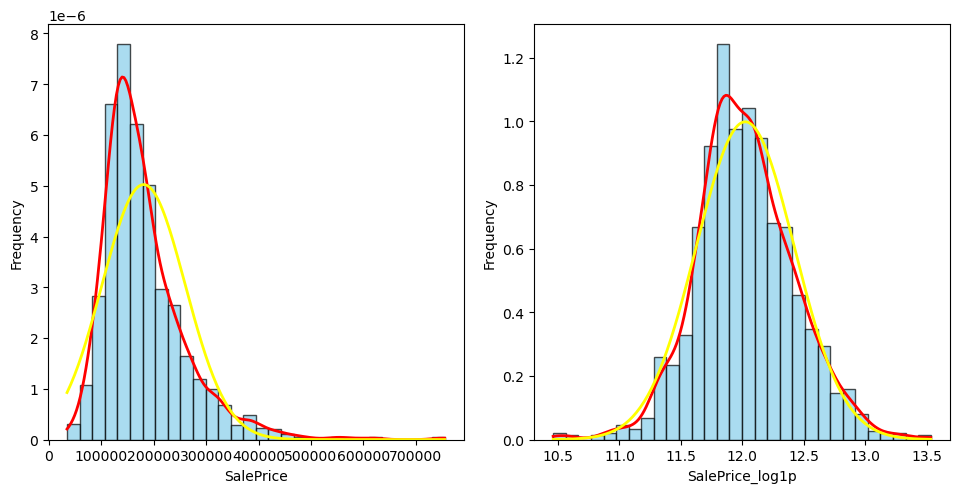

In [30]:
# Plotting distribution
df_data[LOGP_TARGET_COL] = np.log1p(df_data[TARGET_COL])
print(df_data[LOGP_TARGET_COL].describe())
show_distribution(df_data, [TARGET_COL, LOGP_TARGET_COL])
# Distribution is clearly right skewed
# When applying log1p transformation, the distribution becomes more normal
# log1p => Mean ~= Median


Row count 1


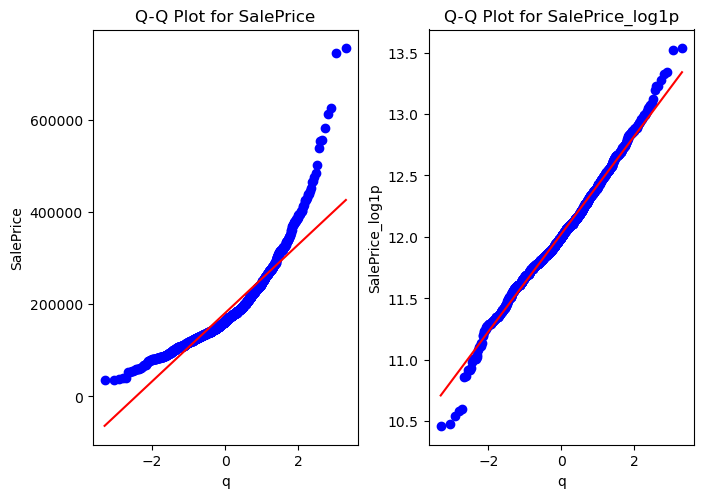

Row count 1


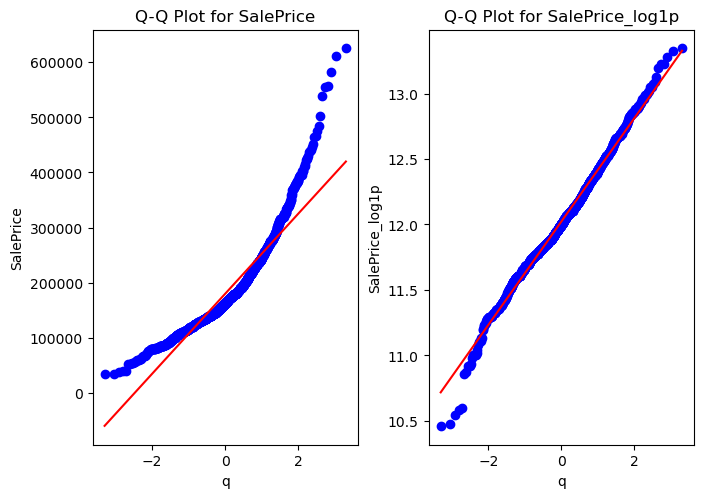

In [31]:
# Q-Q plot to check when the model will struggle
show_qq_plot(df_data, [TARGET_COL, LOGP_TARGET_COL])
# How about removing outliers
df_noout = df_data.copy()[~(df_data["GrLivArea"] > 4000)]

show_qq_plot(df_noout, [TARGET_COL, LOGP_TARGET_COL])
# Observations
# 1. Log1p has some outliers, but distribution is more normal

In [32]:
df_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Id               1460 non-null   int64  
 1   MSSubClass       1460 non-null   int64  
 2   MSZoning         1460 non-null   str    
 3   LotFrontage      1201 non-null   float64
 4   LotArea          1460 non-null   int64  
 5   Street           1460 non-null   str    
 6   Alley            91 non-null     str    
 7   LotShape         1460 non-null   str    
 8   LandContour      1460 non-null   str    
 9   Utilities        1460 non-null   str    
 10  LotConfig        1460 non-null   str    
 11  LandSlope        1460 non-null   str    
 12  Neighborhood     1460 non-null   str    
 13  Condition1       1460 non-null   str    
 14  Condition2       1460 non-null   str    
 15  BldgType         1460 non-null   str    
 16  HouseStyle       1460 non-null   str    
 17  OverallQual      1460 non

In [33]:
# Dropping Id column as it is not needed for training
df_data = df_data.drop(columns=["Id"], errors='ignore')


## Correlation with Target

In [34]:

# Checking positive and negative correlation. Graving more positive values because there are more positive correlations than negative ones.
print(TARGET_COL)
println()
df_corr = df_data.corr(numeric_only=True)[np.abs(df_data.corr(numeric_only=True)[TARGET_COL].values) > 0.5].sort_values(by=TARGET_COL, ascending=False)
print(df_corr[TARGET_COL])
printspace()
print(LOGP_TARGET_COL)
println()
df_corr_logp = df_data.corr(numeric_only=True)[np.abs(df_data.corr(numeric_only=True)[LOGP_TARGET_COL].values) > 0.5].sort_values(by=LOGP_TARGET_COL, ascending=False)
print(df_corr_logp[LOGP_TARGET_COL])
#print(df_corr.shape)

SalePrice
------------------------------
SalePrice          1.000000
SalePrice_log1p    0.948374
OverallQual        0.790982
GrLivArea          0.708624
GarageCars         0.640409
GarageArea         0.623431
TotalBsmtSF        0.613581
1stFlrSF           0.605852
FullBath           0.560664
TotRmsAbvGrd       0.533723
YearBuilt          0.522897
YearRemodAdd       0.507101
Name: SalePrice, dtype: float64
                              
SalePrice_log1p
------------------------------
SalePrice_log1p    1.000000
SalePrice          0.948374
OverallQual        0.817185
GrLivArea          0.700927
GarageCars         0.680625
GarageArea         0.650888
TotalBsmtSF        0.612134
1stFlrSF           0.596981
FullBath           0.594771
YearBuilt          0.586570
YearRemodAdd       0.565608
GarageYrBlt        0.541073
TotRmsAbvGrd       0.534422
Name: SalePrice_log1p, dtype: float64


In [35]:
df_corr_logp[df_corr_logp.index]

,SalePrice_log1p,SalePrice,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,FullBath,YearBuilt,YearRemodAdd,GarageYrBlt,TotRmsAbvGrd
SalePrice_log1p,1.000000,0.948374,0.817185,0.700927,0.680625,0.650888,0.612134,0.596981,0.594771,0.586570,0.565608,0.541073,0.534422
SalePrice,0.948374,1.000000,0.790982,0.708624,0.640409,0.623431,0.613581,0.605852,0.560664,0.522897,0.507101,0.486362,0.533723
OverallQual,0.817185,0.790982,1.000000,0.593007,0.600671,0.562022,0.537808,0.476224,0.550600,0.572323,0.550684,0.547766,0.427452
GrLivArea,0.700927,0.708624,0.593007,1.000000,0.467247,0.468997,0.454868,0.566024,0.630012,0.199010,0.287389,0.231197,0.825489
GarageCars,0.680625,0.640409,0.600671,0.467247,1.000000,0.882475,0.434585,0.439317,0.469672,0.537850,0.420622,0.588920,0.362289
GarageArea,0.650888,0.623431,0.562022,0.468997,0.882475,1.000000,0.486665,0.489782,0.405656,0.478954,0.371600,0.564567,0.337822
TotalBsmtSF,0.612134,0.613581,0.537808,0.454868,0.434585,0.486665,1.000000,0.819530,0.323722,0.391452,0.291066,0.322445,0.285573
1stFlrSF,0.596981,0.605852,0.476224,0.566024,0.439317,0.489782,0.819530,1.000000,0.380637,0.281986,0.240379,0.233449,0.409516
FullBath,0.594771,0.560664,0.550600,0.630012,0.469672,0.405656,0.323722,0.380637,1.000000,0.468271,0.439046,0.484557,0.554784
YearBuilt,0.586570,0.522897,0.572323,0.199010,0.537850,0.478954,0.391452,0.281986,0.468271,1.000000,0.592855,0.825667,0.095589


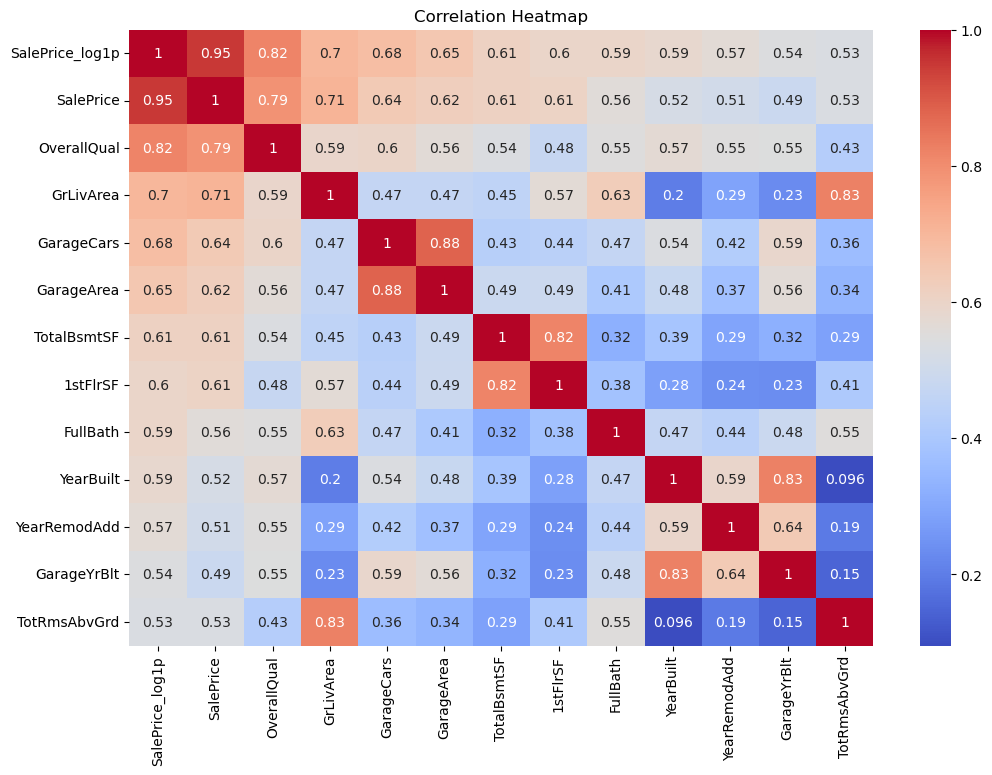

In [36]:
# Let's plot a heatmap to visualize the correlation
plt.figure(figsize=(12, 8))
sns.heatmap(df_corr_logp[df_corr_logp.index], annot=True, cmap="coolwarm") # Plot only columns having more correlation
plt.title("Correlation Heatmap")
plt.show()

# Observations
# OveralQual and GrLivArea are correlated with SalePrice, which makes a lot of sense. Let's play with them after.
# GarageCars and GarageArea are correlated, which maybe indicates that they are redundant?
# CarageCars and GarageArea are correlated with SalePrice too.
# YearBuilt can be used also to create features having more information, like HouseYearsOld
# GarageYrBlt can be also better as GarageYearsOld?
# GrLivArea is correlated with OveralQual, let's try some ratio there
# TotRmsAbvGrd and GrLivArea can be used to create a feature having more information, like RoomsPerArea or similar
# Let's think about YearBuilt and YearRemodAdd
# FullBath and TotRmsAbvGrd can be used to created some BathPerRoomRatio or similar. Also HalfBath can be considered
# TotalBsmtSF and 1stFlrSF corr is very high. Check that relationship.

In [37]:
# Checking Spearman correlation just in case we can find non linear relationships

print(LOGP_TARGET_COL, "Pearson")
println()
print(df_corr_logp[LOGP_TARGET_COL])
printspace()
print(LOGP_TARGET_COL, "Spearman")
println()
df_corr_logp_s = df_data.corr(method="spearman", numeric_only=True)[np.abs(df_data.corr(method="spearman", numeric_only=True)[LOGP_TARGET_COL].values) > 0.5].sort_values(by=LOGP_TARGET_COL, ascending=False)
print(df_corr_logp_s[LOGP_TARGET_COL])
corr_features_target = np.concat((
    df_corr_logp.index.values,
    df_corr_logp_s.index.values
))

corr_features_target = np.unique(corr_features_target)
printspace()
println()
print("Target Corr features:", corr_features_target)

# Observations
# More or less the same, but Fireplaces appeares in the list here. Maybe some signal there? Let's play with that field after

SalePrice_log1p Pearson
------------------------------
SalePrice_log1p    1.000000
SalePrice          0.948374
OverallQual        0.817185
GrLivArea          0.700927
GarageCars         0.680625
GarageArea         0.650888
TotalBsmtSF        0.612134
1stFlrSF           0.596981
FullBath           0.594771
YearBuilt          0.586570
YearRemodAdd       0.565608
GarageYrBlt        0.541073
TotRmsAbvGrd       0.534422
Name: SalePrice_log1p, dtype: float64
                              
SalePrice_log1p Spearman
------------------------------
SalePrice_log1p    1.000000
SalePrice          1.000000
OverallQual        0.809829
GrLivArea          0.731310
GarageCars         0.690711
YearBuilt          0.652682
GarageArea         0.649379
FullBath           0.635957
TotalBsmtSF        0.602725
GarageYrBlt        0.593788
1stFlrSF           0.575408
YearRemodAdd       0.571159
TotRmsAbvGrd       0.532586
Fireplaces         0.519247
Name: SalePrice_log1p, dtype: float64
                          

## Correlation zero feat / target

In [38]:
X = df_data.copy()
y = X.pop(LOGP_TARGET_COL)

zerocols = ["ScreenPorch", "MiscVal", "LowQualFinSF", "KitchenAbvGr", "3SsnPorch", "EnclosedPorch", "BsmtFinSF2", "BsmtFullBath", "BsmtHalfBath"]
Xz = X[list(set(zerocols))].join(y)
# ScreenPorch, MiscVal, LowQualFinSF, KitchenAbvGr, 3ssnPorch, LowQualFinSF, EnclosedPorch, BsmtFinSF2, BsmtFullBath and BsmtHalfBath are almost constant. Check removal 
Xz.describe()
#X.columns

col_z = [] 
Xz_corr = Xz.corr()
for c in Xz.columns:
  zcount = Xz[Xz[c] == 0].shape[0]
  col_z.append([zcount, zcount / Xz.shape[0] * 100, Xz_corr[c][LOGP_TARGET_COL]])

pd.DataFrame(col_z, index=Xz.columns.tolist(), columns=["count", "%", "corr"]).sort_values(by="count", ascending=False)

# ['3SsnPorch', 'LowQualFinSF', 'MiscVal', 'BsmtHalfBath', 'ScreenPorch',
#        'BsmtFinSF2', 'EnclosedPorch', 'BsmtFullBath', 'KitchenAbvGr',
#        'SalePrice_log1p'],
#

,count,%,corr
3SsnPorch,1436,98.356164,0.054900
LowQualFinSF,1434,98.219178,-0.037963
MiscVal,1408,96.438356,-0.020021
BsmtHalfBath,1378,94.383562,-0.005149
ScreenPorch,1344,92.054795,0.121208
BsmtFinSF2,1293,88.561644,0.004832
EnclosedPorch,1252,85.753425,-0.149050
BsmtFullBath,856,58.630137,0.236224
KitchenAbvGr,1,0.068493,-0.147548
SalePrice_log1p,0,0.000000,1.000000


## Correlation between features

In [39]:
method_feat = {}
corr_features = np.array([], dtype=str)
for method in ["pearson", "spearman"]:
    print(f"Correlation between features using *{method}* method")
    println(n=40)
    df_corr_f = df_data.drop(columns=[TARGET_COL, LOGP_TARGET_COL]).corr(method=method, numeric_only=True)
    df_corr_f = df_corr_f.where((df_corr_f.abs() > 0.6) & (df_corr_f != 1))
    df_corr_f_list = df_corr_f.stack().sort_values(ascending=False).reset_index().rename(columns={0: "Correlation", "level_0": "Feature1", "level_1": "Feature2"})
    # Remove rows duplicated correlations in inverse order
    df_corr_f_list = df_corr_f_list[df_corr_f_list.index % 2 == 1]
    corr_features = np.append(corr_features, pd.concat((df_corr_f_list["Feature1"], df_corr_f_list["Feature2"])).drop(columns="index").values)
    corr_features = np.unique(corr_features)
    feat = df_corr_f_list["Feature1"].str.cat(df_corr_f_list["Feature2"], sep="_")
    method_feat[method] = feat
    
    print("High correlation list")
    println(n=40)
    print(df_corr_f_list.reset_index().drop(columns=["index"]))
    printspace()
    # Using all to remove rows and columns having all NaN values and fill missing with 0 to display the heatmap
    df_corr_f = df_corr_f.dropna(how="all", axis=0).dropna(how="all", axis=1).fillna(0) 
# print("Pearson:", np.setdiff1d(method_feat["pearson"], method_feat["spearman"]))
# println()
# print("Spearman:", np.setdiff1d(method_feat["spearman"], method_feat["pearson"]))
printspace()
println()
print("Total features having high correlation:", len(corr_features))
print(corr_features)

# Observations
# Features here are more or less the same as in the correlation with the target
# CarageArea and GarageCars are very strongly correlated. Perhaps because the explain more or less the same. Let's try creating a ratio like SizeForEachCar or something
# Area and SF features are correlated between each other (TotalBsmtSF, 1stFlrSF, BsmtFinSF1, 2ndFlrSF, GrLivArea, GarageArea, LotArea). Some of them have corr with Target too.
# --> we can try to combine some or many of them to see what happens.
# Spearman shows some more features. Let's check if the is some monotonic relationship there.





Correlation between features using *pearson* method
----------------------------------------
High correlation list
----------------------------------------
          Feature1       Feature2  Correlation
0       GarageArea     GarageCars     0.882475
1      GarageYrBlt      YearBuilt     0.825667
2     TotRmsAbvGrd      GrLivArea     0.825489
3      TotalBsmtSF       1stFlrSF     0.819530
4        GrLivArea       2ndFlrSF     0.687501
5     TotRmsAbvGrd   BedroomAbvGr     0.676620
6       BsmtFinSF1   BsmtFullBath     0.649212
7      GarageYrBlt   YearRemodAdd     0.642277
8         FullBath      GrLivArea     0.630012
9         2ndFlrSF   TotRmsAbvGrd     0.616423
10        2ndFlrSF       HalfBath     0.609707
11      GarageCars    OverallQual     0.600671
12      MSSubClass    LotFrontage          NaN
13      MSSubClass    OverallQual          NaN
14      MSSubClass      YearBuilt          NaN
15      MSSubClass     MasVnrArea          NaN
16      MSSubClass     BsmtFinSF2          Na

## Data structure Analysis

In [40]:
feSF = ["TotalBsmtSF", "1stFlrSF", "2ndFlrSF", "GrLivArea", "GarageArea", LOGP_TARGET_COL]
# BuiltSF should be correlated to target
df_data["BuiltSF"] = df_data["1stFlrSF"] + df_data["2ndFlrSF"] + df_data["GarageArea"] + df_data["TotalBsmtSF"]
# Let's check if the built Area / SF ratio has some meaning
df_data["BuiltRatio"] = df_data["LotArea"] / df_data["BuiltSF"] 
df_data["NonBuiltSF"] = df_data["LotArea"] - df_data["BuiltSF"]
floorSF = ["BuiltRatio", "BuiltSF", LOGP_TARGET_COL]
#sns.pairplot(df_data[floorSF], hue=LOGP_TARGET_COL)
df_data[["BuiltSF", "BuiltRatio", LOGP_TARGET_COL]].corr(method="spearman")

# Does ratio has any non linear relationship?
print("MI BuiltRatio:", mutual_info_regression(df_data[["BuiltRatio"]], df_data[LOGP_TARGET_COL], discrete_features=False))

df_data[["NonBuiltSF", LOGP_TARGET_COL]].corr()

#sns.pairplot(df_data[["NonBuiltSF", LOGP_TARGET_COL]])

# Observations
# BuiltSF has high correlation with target (as expected)
# BuildRatio has none "Pearson" correlation and a very low "Spearman" correlation with target
# There is no clear linear / monotonic relationship with BuildRatio and BuildSF
# There is no relationship between BuiltRatio and the target
# There is no relationship between NonBuiltSF and the target

MI BuiltRatio: [0.10384121]


,NonBuiltSF,SalePrice_log1p
NonBuiltSF,1.000000,0.183958
SalePrice_log1p,0.183958,1.000000


## Corr target / Pairplots

['GrLivArea', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'FullBath', 'YearBuilt', 'LotArea', 'OverallQual', 'LotFrontage', 'GarageCars', 'Neighborhood', 'OverallCond']


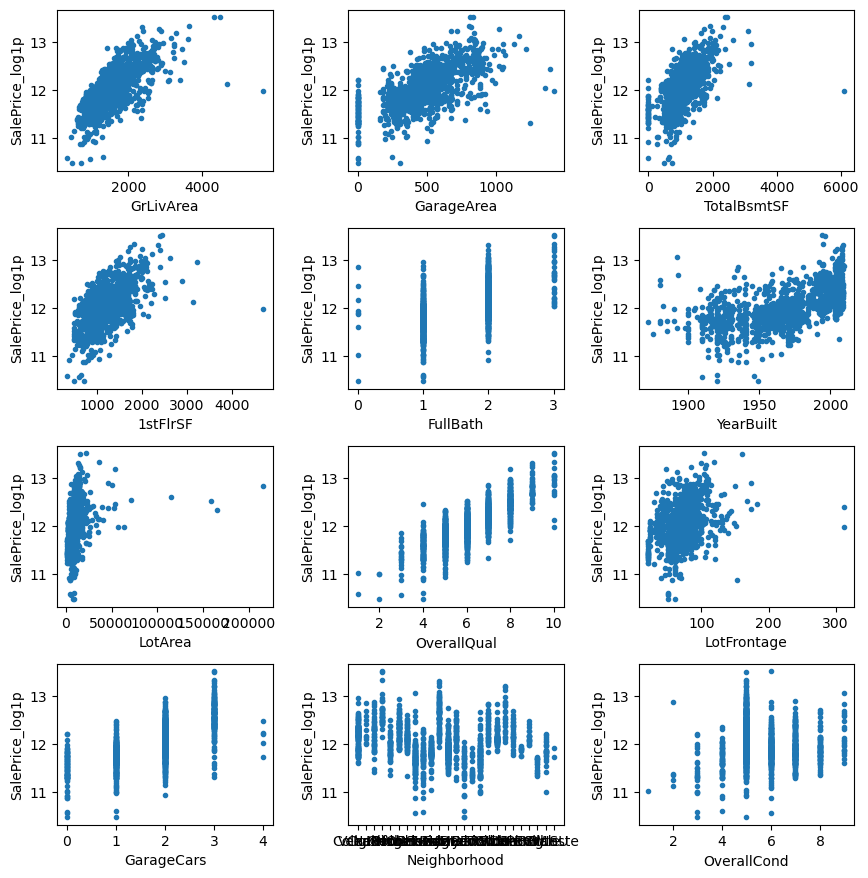

In [41]:
pp_feat = ["GrLivArea", "GarageArea", "TotalBsmtSF", "1stFlrSF", "FullBath", "YearBuilt", "LotArea",
              "OverallQual", "LotFrontage", "GarageCars", "Neighborhood", "OverallCond"]

print(pp_feat)
show_target_pairplot(df_data.copy(), pp_feat, LOGP_TARGET_COL)

# There are some outliers in 1stFlrSF, BuiltSF, GarageArea, GrLiveArea, TotalBsmtSF
# Fireplaces. 3 is not a common value. Test making it 2.
# What does fullbath == 0 means? Seems wrong value. Check.
# A lot of 0 in Fireplaces, FullBath, GarageArea, GarageCars, YearRemodAdd, TotalBsmtSF
# YearBuilt and YearRemodAdd are kind of noicy.
# MSSubClass seems to have some signal. Check ANoVA. There are some very low values (out of trend) for some categories.

In [42]:
# Checking neighborhood distribution
dfn = df_raw_data.copy()
dfn.groupby("Neighborhood")["SalePrice"].agg(["mean", "std", "count"]).sort_values(by="mean", ascending=False)


,mean,std,count
Neighborhood,,,
NoRidge,335295.317073,121412.658640,41
NridgHt,316270.623377,96392.544954,77
StoneBr,310499.000000,112969.676640,25
Timber,242247.447368,64845.651549,38
Veenker,238772.727273,72369.317959,11
Somerst,225379.837209,56177.555888,86
ClearCr,212565.428571,50231.538993,28
Crawfor,210624.725490,68866.395472,51
CollgCr,197965.773333,51403.666438,150


## Checking main features distribution

Corr lenght: 38
0 6


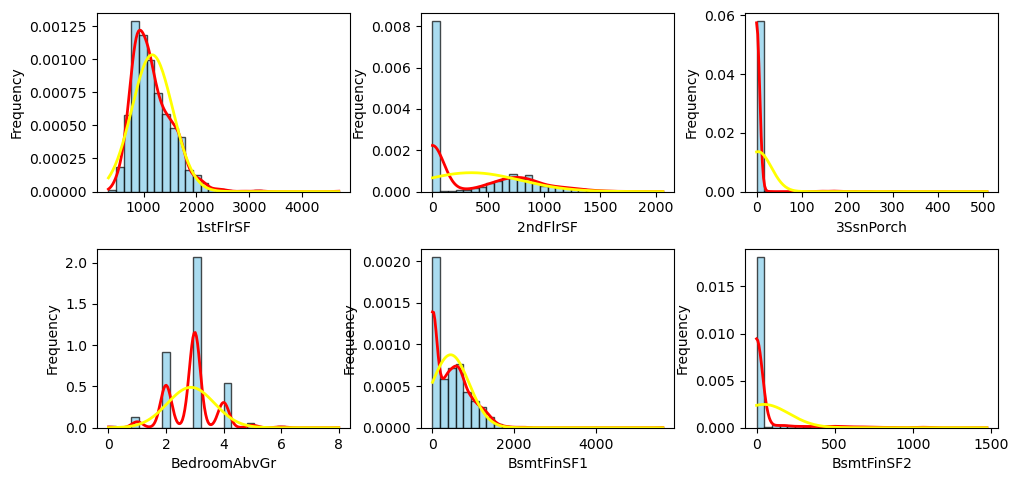

6 12


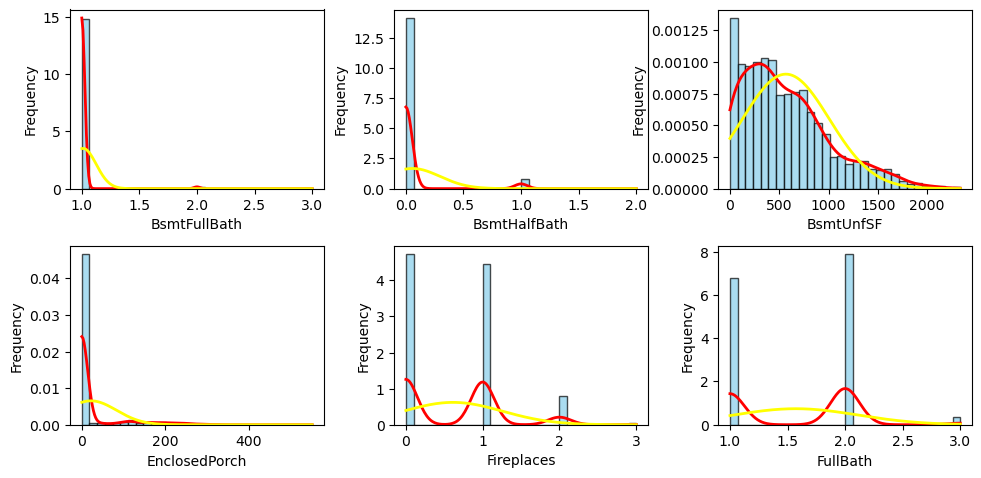

12 18


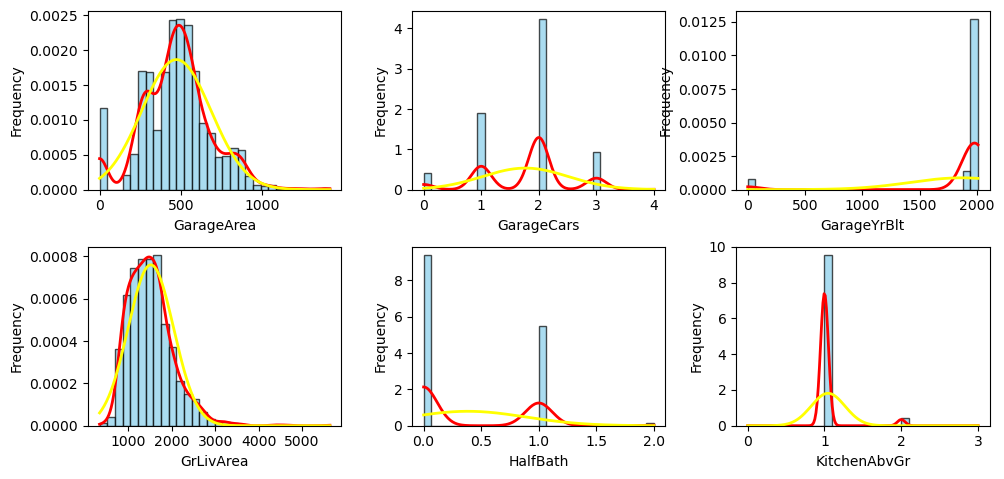

18 24


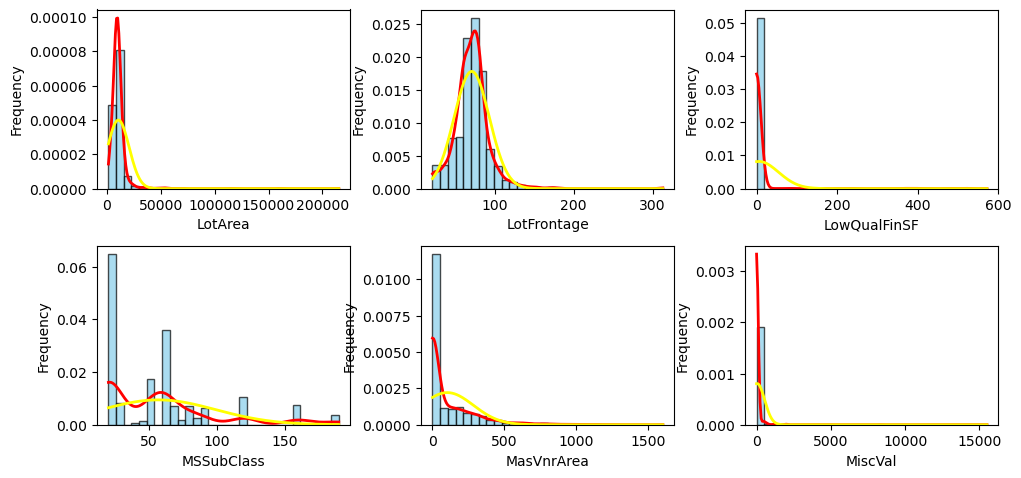

24 30


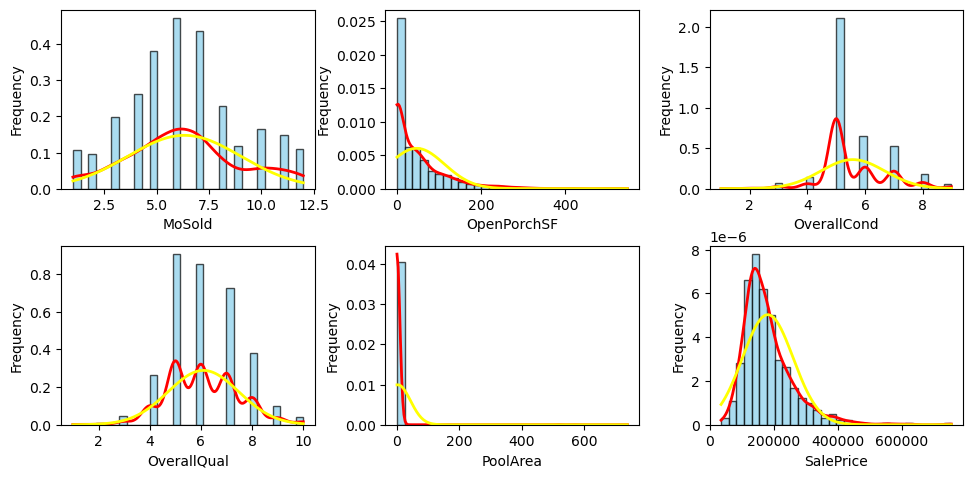

30 36


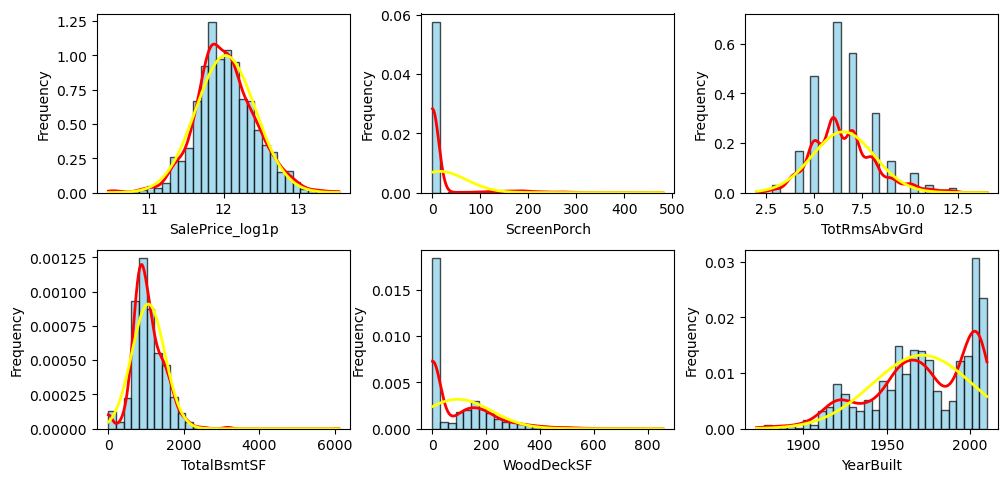

36 37


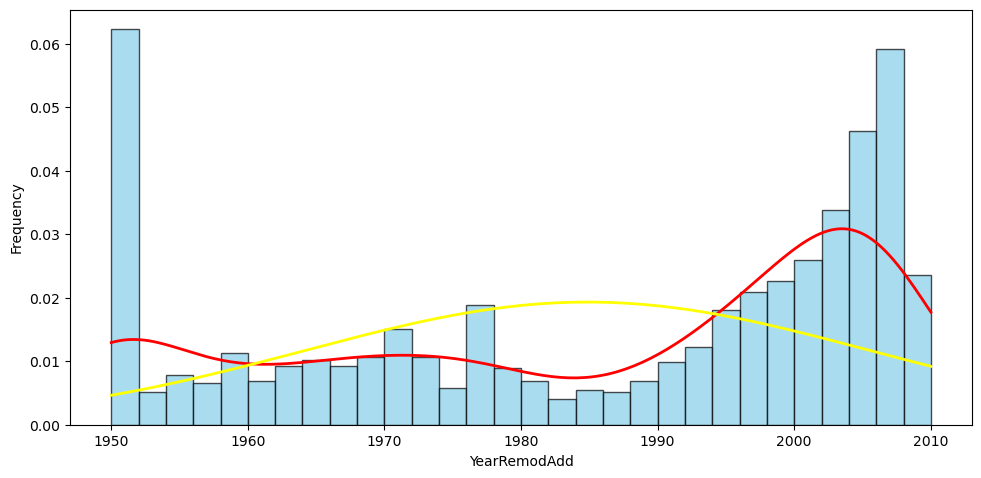

In [43]:
all_corr = np.unique(np.concatenate((corr_features_target, corr_features)))
corr_len = len(all_corr)
print("Corr lenght:", corr_len)

df = fix_nulls(df_data, df_data)
df = fix_invalid(df)

step = 6
s = 0 
e = step 
for i in range(s, corr_len, step):
    print(s, e)
    show_distribution(df, all_corr[s:e].tolist(), debug=False)
    s+=step
    e = min(s+step, corr_len - 1)

# Observations
# 1stFlrSF is heavy right skewed. Need to check outliers. Also it seems to have the same information than GrLivArea. Check removing or fixing the right skeew using log1p
# 2ndFlrSF is right skewed and it has a lot of 0. Suppose corresponds to houses not having 2nd floor. Maybe create a Has2ndFloor feature? Also check outliers.
# GarageCars and GarageArea should provide the similar information. Try removing or using some combination. There are also several values = 0. Complement with field HasGarage 1/0
# There are a few samples having 3 bathrooms. Check if the related price. Consider creating a Has3Baths feature, or clipping value to 2.
# HalfBath mostly 0-1. Consider HasHalfBath
# Check 0 values in BedroomAbvGr
# BsmtFinSF1 has a lot of 0. Add HasBsmt 1/0. 
# Compare garage built with house built year. Check if has any signal.
# FullBath, a very few values > 2. Check signal. Consider adding HasFullBath
# LotArea has 0 values? If yes, fix. Not possible data
# ScreenPorch, MiscVal, LowQualFinSF, KitchenAbvGr, 3ssnPorch, LowQualFinSF, EnclosedPorch, BsmtFinSF2, BsmtFullBath and BsmtHalfBath are almost constant. Check removal 
# LotArea, LotFrontage, OpenPorchSF, WoodDeckSF, TotalBsmtSF heavy right skewed. -> Log1p?
# PoolArea, OpenPorchSF, WoodDeckSF mostly 0. Add binary
# YearBuilt is left skewed... Transformation?
# What to do with YearRemodAdd?

### Transformation analysis

No Transf
                 GrLivArea   LotArea  1stFlrSF  PoolArea  LotFrontage  \
GrLivArea         1.000000  0.263116  0.566024  0.170205     0.385982   
LotArea           0.263116  1.000000  0.299475  0.077672     0.336997   
1stFlrSF          0.566024  0.299475  1.000000  0.131525     0.423764   
PoolArea          0.170205  0.077672  0.131525  1.000000     0.174520   
LotFrontage       0.385982  0.336997  0.423764  0.174520     1.000000   
OpenPorchSF       0.330224  0.084774  0.211671  0.060762     0.140304   
WoodDeckSF        0.247433  0.171698  0.235459  0.073378     0.093130   
TotalBsmtSF       0.454868  0.260833  0.819530  0.126053     0.370780   
SalePrice_log1p   0.700927  0.257320  0.596981  0.069798     0.352747   

                 OpenPorchSF  WoodDeckSF  TotalBsmtSF  SalePrice_log1p  
GrLivArea           0.330224    0.247433     0.454868         0.700927  
LotArea             0.084774    0.171698     0.260833         0.257320  
1stFlrSF            0.211671    0.235459

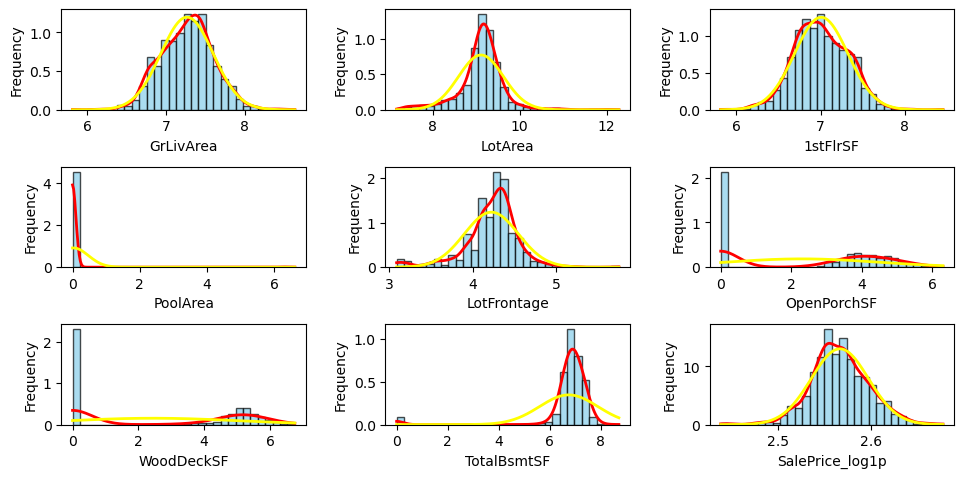

In [44]:
# From the previous graphics where GarageArea, GrLivArea, LotArea, LotFrontage and 1stFlrSF can be transformed. Let's check skew and see.
# Also check BsmtFinSF1 and BsmtUnfSF
# ScreenPorch, MiscVal, LowQualFinSF, KitchenAbvGr, 3ssnPorch, LowQualFinSF, EnclosedPorch, BsmtFinSF2, BsmtFullBath and BsmtHalfBath are almost constant. Check removal 
# LotArea, LotFrontage, OpenPorchSF, WoodDeckSF, TotalBsmtSF heavy right skewed. -> Log1p?
# PoolArea, OpenPorchSF, WoodDeckSF mostly 0. Add binary
# YearBuilt is left skewed... Transformation?
# What to do with YearRemodAdd?

df = fix_nulls(df_data, df_data)
df = df[df["GrLivArea"] < 4000]
sk_cols = ["GarageArea", "GrLivArea", "LotArea", "1stFlrSF", "YearBuilt", "PoolArea", "LotFrontage", "OpenPorchSF", "WoodDeckSF", "TotalBsmtSF"]
sk_cols = df[sk_cols].columns[df_data[sk_cols].skew().abs() > 0.75].tolist()
sk_cols.append(LOGP_TARGET_COL)

df_sk = df_data[sk_cols]
df_tsk = df_data[sk_cols].apply(lambda x: np.log1p(x))

print("No Transf")
print(df_sk.corr())
printspace()
print("Log1p")
println()
print(df_tsk.corr())

#show_distribution(df_data, all_corr[18:22].tolist())
show_distribution(df_tsk, sk_cols)

# Observations
# - GrLiveArea, LotArea, LotFrontage and 1stFlrSF distributions is much more normal after applying log1p
# - BsmtFinSF1 and BsmtUnfSF1 become left skewed. Let's try sqrt
# - Correlation is improved a little bit


### Categories

#### Functions

In [45]:
def analyze_cardinal_info(X, y, feat, has_count=False):
  df_proc = X.join(y)
  logpm = df_proc[LOGP_TARGET_COL].mean()
  res = {"val": [], "porc": [], "tg_mean": [], "std": [], "coef_var": [], "count": []}

  for val in  np.sort(df_proc[feat].unique()):
    df_val = df_proc[df_proc[feat] == val]
    porc =  df_val.shape[0] / df_proc.shape[0]
    tg_mean = df_val[LOGP_TARGET_COL].mean()
    std = df_val[LOGP_TARGET_COL].std()
    if has_count:
      count = df_val["count"].sum()
    else:
      count = df_val.shape[0]

    res["val"].append(val)
    res["porc"].append(porc)
    res["tg_mean"].append(tg_mean)
    res["std"].append(std)
    res["coef_var"].append(std / (tg_mean if tg_mean != 0 else 0) * 100) # Measures the variability of the target mean for each category. Higher values indicate more variability, which can be a sign of a less stable category.
    res["count"].append(count)

  return pd.DataFrame(res)

def print_cardinal_info(X, y, feat, has_count=False):
  df_res = analyze_cardinal_info(X, y, feat, has_count=has_count)
  print("Feature:", feat)
  total_count = 0
  println()
  for i, row in df_res.sort_values(by="tg_mean", ascending=False).iterrows():
    # copy values from row to variables
    val = row["val"]
    porc = row["porc"]
    tg_mean = row["tg_mean"]
    std = row["std"]
    co_var = row["coef_var"]
    count = int(row["count"])
    total_count+=count
    print(f"val: {val}", f"({pfmt(porc)}) - target mean: {nfmt(tg_mean)}", "std:", f"{nfmt(std)}", \
          "coef.var:", f"{nfmt(co_var)}", "count:", count)
  printspace()
  print("Value count:", df_res.shape[0])
  print("Total count:", total_count)


from scipy import stats

def mann_whitney_test(df, cat_col, target_col, cat_a, cat_b, alpha=0.05):
  a = df[df[cat_col] == cat_a][target_col]
  b = df[df[cat_col] == cat_b][target_col]

  # Are distributions statistically different?
  _, p_value = stats.mannwhitneyu(a, b, alternative='two-sided')

  println()
  print(f"  {cat_a} → n={len(a)}, mean={a.mean():.3f}, std={a.std():.3f}")
  print(f"  {cat_b} → n={len(b)}, mean={b.mean():.3f}, std={b.std():.3f}")
  print(f"  p-value: {p_value:.4f}")
  printspace()
  if p_value > alpha:
    sign = ">"
    msg = "Distributions NOT significantly different → Safe to merge"
  else:
    sign = "<"
    msg = "Distributions ARE different → Merging may lose signal"
  print(f"p-value ({p_value})", sign, f"alpha ({alpha})")
  print(msg)
  printspace()

  return p_value


#### Ordinal categories

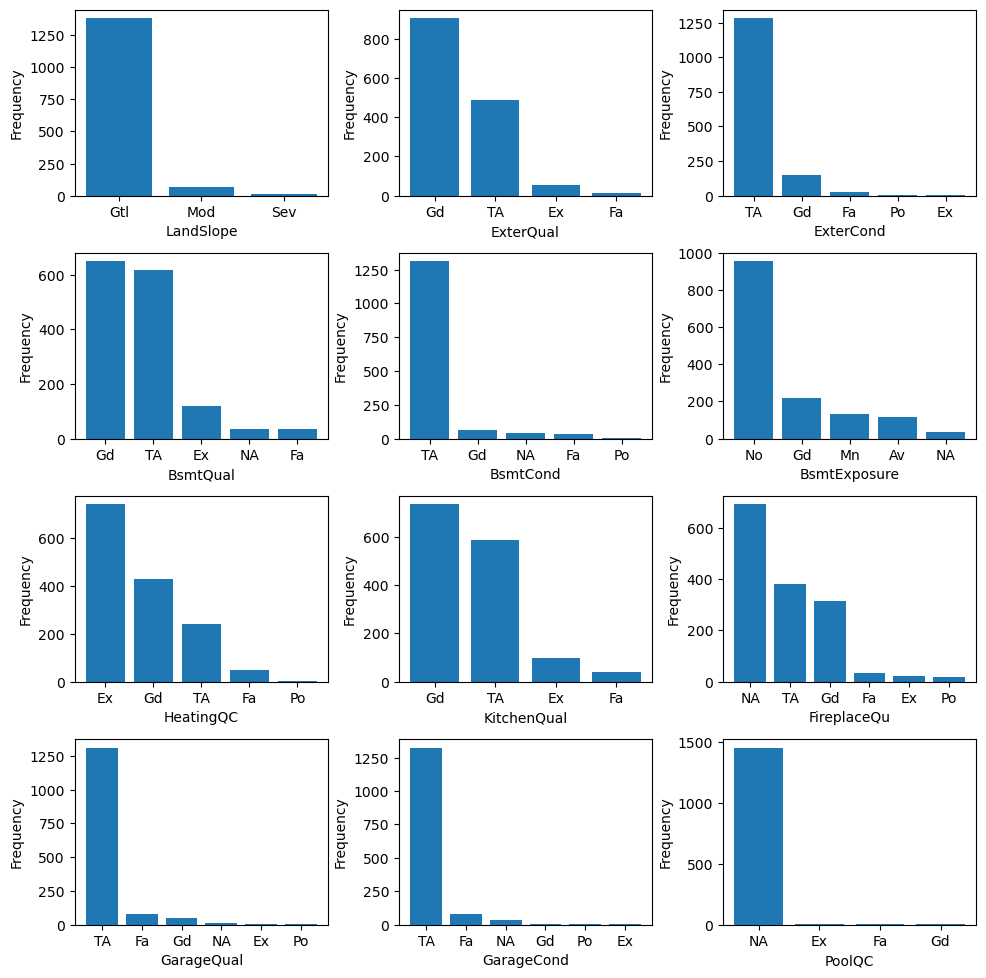

In [46]:
# Ordinal categories


#df_data[ORD_COLS].hist()
df = fix_nulls(df_data.copy(), df_data)
show_bar_plot(df, ORD_COLS, debug=False)


# Observations
# LandSlope has 1 very dominant category. Maybe transform to IsLandSlopeGtl? Check signal
# OverallQual has a few low values. Check group in 3
# OverallCond, 5 is dominant and lower that 5 weard. Maybe create Low/Medium/Hight? 1/5/10 or something to maintain meaningful difference?
# ExterQual, Gd and TA are dominant. Low/Medium/Large could be applied here.
# ExterCond, same as ExterQual
# BsmtQual, Maybe here the values make more sense even having 2 dominant categories. Also NA means no basement. Should add HasBsmt field?
# BsmtCond, TA is extremelly dominant. Maybe is IsBsmtQualCondTypica and HasBsmt field?
# BsmtExposure, No (No exposure) is dominant, and other values exists. Try HasBsmtExposure field.
# BsmtFinType1, There are two dominant categories, but all off them have values. Keep as it is?
# BsmtFinType2, Unf (Unfinished) is very dominant. Check creating HasBsmtFinType2
# HeatingQC, Fa and Po has very low values. Test creating "Other" value or making Fa and Po = TA
# KitchenQual, leave as it is
# FireplaceQu, NA is dominant. Maybe create HasFireplace field and High/Medium/Low categories
# GarageQual, TA is dominant and has very few values different than that. Check removing the feature
# GarageCond, same than GarageQual
# PoolQC, NA is the 99% of the rows. Remove it. Just in case, check if the other 1% behaves very diffently in relation with the target. Create HasPool feature




#### Improve cat dist

In [47]:

def improve_ord_cat_distribution(df, ignored_cols):
  df = df.copy()
  
  ignored_cols = set(ignored_cols)
  if "LandSlope" not in ignored_cols:
    # LandSlope
    # val: Sev (0.88%) - target mean: 12.1396 var: 0.2701 count: 10
    # val: Mod (4.58%) - target mean: 12.1276 var: 0.2202 count: 52
    # val: Gtl (94.54%) - target mean: 12.0206 var: 0.1359 count: 1073
    #df["LandSlope"] = df["LandSlope".replace("Sev", "Mod")]
    df["LandSlope"] = df["LandSlope"].map(lambda x: 0 if x == "Gtl" else 0)

  if "ExterQual" not in ignored_cols:
    # ExterQual
    # val: Ex (3.26%) - target mean: 12.7335 var: 0.0824 count: 37
    # val: Gd (33.74%) - target mean: 12.3022 var: 0.0722 count: 383
    # val: TA (62.11%) - target mean: 11.8512 var: 0.0748 count: 705
    # val: Fa (0.88%) - target mean: 11.2166 var: 0.1139 count: 10
    # New values 1, 2
    df["ExterQual"] = df["ExterQual"].replace("Ex", 2)
    df["ExterQual"] = df["ExterQual"].replace("Gd", 2)
    df["ExterQual"] = df["ExterQual"].replace("TA", 1)
    df["ExterQual"] = df["ExterQual"].replace("Fa", 1)
    df["ExterQual"] = df["ExterQual"].replace("Po", 1)
    df["ExterQual"] = df["ExterQual"].astype(int)

  if "ExterCond" not in ignored_cols:
    # ExterCond
    # val: Ex (0.26%) - target mean: 12.1197 var: 0.2694 count: 3
    # val: TA (87.49%) - target mean: 12.0439 var: 0.1349 count: 993
    # val: Gd (10.31%) - target mean: 11.9810 var: 0.1304 count: 117
    # val: Fa (1.85%) - target mean: 11.4859 var: 0.1621 count: 21
    # val: Po (0.09%) - target mean: 11.2451 var: nan count: 1
    # New Values 1, 2
    df["ExterCond"] = df["ExterCond"].replace("Ex", 2)
    df["ExterCond"] = df["ExterCond"].replace("Gd", 2)
    df["ExterCond"] = df["ExterCond"].replace("TA", 1)
    df["ExterCond"] = df["ExterCond"].replace("Fa", 1)
    df["ExterCond"] = df["ExterCond"].replace("Po", 1)
    df["ExterCond"] = df["ExterCond"].astype(int)

  if "BsmtQual" not in ignored_cols:
    # val: Ex (7.84%) - target mean: 12.6073 var: 0.0922 count: 89
    # val: Gd (43.35%) - target mean: 12.1779 var: 0.0749 count: 492
    # val: TA (43.88%) - target mean: 11.8264 var: 0.0735 count: 498
    # val: Fa (2.11%) - target mean: 11.6118 var: 0.1003 count: 24
    # val: NA (2.82%) - target mean: 11.5111 var: 0.0783 count: 32
    # New values 0, 1, 2, 3
    df["BsmtQual"] = df["BsmtQual"].replace("Ex", 3) # There are decent rows but a strong signal here
    df["BsmtQual"] = df["BsmtQual"].replace("Gd", 2)
    df["BsmtQual"] = df["BsmtQual"].replace("TA", 1)
    # Fa is closer to NA than TA. Also, Po should be the same if present
    df["BsmtQual"] = df["BsmtQual"].replace("Fa", 0)
    df["BsmtQual"] = df["BsmtQual"].replace("Po", 0)
    df["BsmtQual"] = df["BsmtQual"].replace("NA", 0)
    df["BsmtQual"] = df["BsmtQual"].astype(int)

  if "BsmtCond" not in ignored_cols:
    # This feature is very imbalanced, maybe remove it?
    # Also, NA > Po
    # val: Gd (4.14%) - target mean: 12.2180 var: 0.0960 count: 47
    # val: TA (90.13%) - target mean: 12.0463 var: 0.1308 count: 1023
    # val: Fa (2.73%) - target mean: 11.6790 var: 0.1116 count: 31
    # val: NA (2.82%) - target mean: 11.5111 var: 0.0783 count: 32
    # val: Po (0.18%) - target mean: 11.0656 var: 0.0044 count: 2
    df["BsmtCond"] = df["BsmtCond"].replace("Ex", 2)
    df["BsmtCond"] = df["BsmtCond"].replace("Gd", 2)
    df["BsmtCond"] = df["BsmtCond"].replace("TA", 1)
    df["BsmtCond"] = df["BsmtCond"].replace("Fa", 0)
    df["BsmtCond"] = df["BsmtCond"].replace("Po", 0)
    df["BsmtCond"] = df["BsmtCond"].replace("NA", 0)
    df["BsmtCond"] = df["BsmtCond"].astype(int)

  if "BsmtExposure" not in ignored_cols:
    # val: Gd (8.28%) - target mean: 12.3164 var: 0.1709 count: 94
    # val: Av (15.15%) - target mean: 12.1577 var: 0.1266 count: 172
    # val: Mn (8.02%) - target mean: 12.1052 var: 0.1431 count: 91
    # val: No (65.64%) - target mean: 11.9721 var: 0.1143 count: 745
    # val: NA (2.91%) - target mean: 11.5310 var: 0.0889 count: 33
    # There are a low % of NA, but the signal is strong
    df["BsmtExposure"] = df["BsmtExposure"].replace("Gd", "2")
    df["BsmtExposure"] = df["BsmtExposure"].replace("Av", "2")
    df["BsmtExposure"] = df["BsmtExposure"].replace("Mn", "2")
    df["BsmtExposure"] = df["BsmtExposure"].replace("No", "1")
    df["BsmtExposure"] = df["BsmtExposure"].replace("NA", "0")
    df["BsmtExposure"] = df["BsmtExposure"].astype(int)

  if "HeatingQC" not in ignored_cols:
    # Feature: HeatingQC
    # val: Ex (49.60%) - target mean: 12.2069 var: 0.1229 count: 563
    # val: Gd (17.71%) - target mean: 11.9075 var: 0.0902 count: 201
    # val: TA (28.99%) - target mean: 11.8348 var: 0.0835 count: 329
    # val: Fa (3.61%) - target mean: 11.6887 var: 0.1797 count: 41
    # val: Po (0.09%) - target mean: 11.3737 var: nan count: 1
    df["HeatingQC"] = df["HeatingQC"].replace("Ex", "3")
    df["HeatingQC"] = df["HeatingQC"].replace("Gd", "2")
    df["HeatingQC"] = df["HeatingQC"].replace("TA", "1")
    df["HeatingQC"] = df["HeatingQC"].replace("Fa", "1")
    df["HeatingQC"] = df["HeatingQC"].replace("Po", "1")
    df["HeatingQC"] = df["HeatingQC"].astype(int)

  if "KitchenQual" not in ignored_cols:
    # Feature: KitchenQual
    # val: Ex (5.90%) - target mean: 12.6333 var: 0.1025 count: 67
    # val: Gd (41.06%) - target mean: 12.2175 var: 0.0836 count: 466
    # val: TA (50.84%) - target mean: 11.8238 var: 0.0686 count: 577
    # val: Fa (2.20%) - target mean: 11.5227 var: 0.1331 count: 25
    # The Ex % is kind a small but there is signal there
    df["KitchenQual"] = df["KitchenQual"].replace("Ex", "3")
    df["KitchenQual"] = df["KitchenQual"].replace("Gd", "2")
    df["KitchenQual"] = df["KitchenQual"].replace("TA", "1")
    df["KitchenQual"] = df["KitchenQual"].replace("Fa", "1")
    df["KitchenQual"] = df["KitchenQual"].replace("Po", "1")
    df["KitchenQual"] = df["KitchenQual"].astype(int)

  if "FireplaceQu" not in ignored_cols:
    # Feature: FireplaceQu
    # val: Ex (1.50%) - target mean: 12.6155 var: 0.1079 count: 17
    # val: Gd (25.46%) - target mean: 12.2478 var: 0.1339 count: 289
    # val: TA (22.03%) - target mean: 12.1821 var: 0.0792 count: 250
    # val: Fa (2.29%) - target mean: 12.0033 var: 0.0426 count: 26
    # val: NA (47.67%) - target mean: 11.8258 var: 0.0909 count: 541
    # val: Po (1.06%) - target mean: 11.7234 var: 0.0789 count: 12
    df["FireplaceQu"] = df["FireplaceQu"].replace("Ex", "2")
    df["FireplaceQu"] = df["FireplaceQu"].replace("Gd", "2")
    df["FireplaceQu"] = df["FireplaceQu"].replace("TA", "1")
    df["FireplaceQu"] = df["FireplaceQu"].replace("Fa", "1")
    df["FireplaceQu"] = df["FireplaceQu"].replace("Po", "0")
    df["FireplaceQu"] = df["FireplaceQu"].replace("NA", "0")
    df["FireplaceQu"] = df["FireplaceQu"].astype(int)

  if "GarageQual" not in ignored_cols:
    # Feature: GarageQual
    # val: Ex (0.09%) - target mean: 13.0711 var: nan count: 1
    # val: Gd (0.88%) - target mean: 12.3923 var: 0.0629 count: 10
    # val: TA (89.87%) - target mean: 12.0667 var: 0.1234 count: 1020
    # val: Fa (3.61%) - target mean: 11.6947 var: 0.0801 count: 41
    # val: NA (5.29%) - target mean: 11.5206 var: 0.0920 count: 60
    # val: Po (0.26%) - target mean: 11.4725 var: 0.1279 count: 3
    # Ex Target is far from Gd. But is only 1 record. Maybe removing the record is best
    df["GarageQual"] = df["GarageQual"].replace("Ex", "2")
    df["GarageQual"] = df["GarageQual"].replace("Gd", "2")
    df["GarageQual"] = df["GarageQual"].replace("TA", "1")
    df["GarageQual"] = df["GarageQual"].replace("Fa", "0")
    df["GarageQual"] = df["GarageQual"].replace("Po", "0")
    df["GarageQual"] = df["GarageQual"].replace("NA", "0")
    df["GarageQual"] = df["GarageQual"].astype(int)

  if "GarageCond" not in ignored_cols:
    # Feature: GarageCond
    # val: TA (90.93%) - target mean: 12.0693 var: 0.1251 count: 1032
    # val: Gd (0.70%) - target mean: 12.0444 var: 0.1184 count: 8
    # val: Fa (2.56%) - target mean: 11.6475 var: 0.0614 count: 29
    # val: Po (0.53%) - target mean: 11.5470 var: 0.0599 count: 6
    # val: NA (5.29%) - target mean: 11.5206 var: 0.0920 count: 60
    # This is a very imbalance feature, but is a clear boundary in target values
    df["GarageCond"] = df["GarageCond"].replace("Ex", "1")
    df["GarageCond"] = df["GarageCond"].replace("Gd", "1")
    df["GarageCond"] = df["GarageCond"].replace("TA", "1")
    df["GarageCond"] = df["GarageCond"].replace("Fa", "0")
    df["GarageCond"] = df["GarageCond"].replace("Po", "0")
    df["GarageCond"] = df["GarageCond"].replace("NA", "0")
    df["GarageCond"] = df["GarageCond"].astype(int)

    # Feature: PoolQC
    # val: Gd (0.09%) - target mean: 12.5244 var: nan count: 1
    # val: Ex (0.09%) - target mean: 12.3673 var: nan count: 1
    # val: Fa (0.09%) - target mean: 12.1063 var: nan count: 1
    # val: NA (99.74%) - target mean: 12.0258 var: 0.1412 count: 1132
    # Constant column, to be removed

  return df


In [48]:
# X = X.join(Y)
# show_target_pairplot(X, ["BalOverallQual"], LOGP_TARGET_COL)
X = get_eda_data()
y = X.pop(LOGP_TARGET_COL)

X_newd = improve_ord_cat_distribution(X, ignored_cols=[])

for col in ORD_COLS:
  print("Old")
  print_cardinal_info(X, y, col)
  print("New")
  print_cardinal_info(X_newd, y, col)
  println("#")

Old
Feature: LandSlope
------------------------------
val: Sev (0.89%) - target mean: 12.1306 std: 0.4863 coef.var: 4.0089 count: 13
val: Mod (4.45%) - target mean: 12.0769 std: 0.4982 coef.var: 4.1252 count: 65
val: Gtl (94.66%) - target mean: 12.0206 std: 0.3934 coef.var: 3.2727 count: 1382
                              
Value count: 3
Total count: 1460
New
Feature: LandSlope
------------------------------
val: 0.0 (100.00%) - target mean: 12.0241 std: 0.3994 coef.var: 3.3221 count: 1460
                              
Value count: 1
Total count: 1460
##############################
Old
Feature: ExterQual
------------------------------
val: Ex (3.56%) - target mean: 12.7640 std: 0.3257 coef.var: 2.5517 count: 52
val: Gd (33.42%) - target mean: 12.3113 std: 0.2860 coef.var: 2.3229 count: 488
val: TA (62.05%) - target mean: 11.8380 std: 0.2937 coef.var: 2.4809 count: 906
val: Fa (0.96%) - target mean: 11.3046 std: 0.4064 coef.var: 3.5951 count: 14
                              
Value cou

#### Class Categories

In [49]:
def get_class_categories_feat(df):
    """
    Get class categories from the DataFrame.

    Args:
        df (pd.DataFrame): DataFrame containing the data.

    Returns:
        list: List of class categories.
    """
    num_feat = df.select_dtypes(include=[np.number]).columns
    class_cat = [x for x in df.columns if x not in num_feat and x not in ORD_COLS]
    return class_cat

def print_class_cat_summary(df):
  for col in class_cat:
    println()
    print(df[col].value_counts())
    printspace()

def analyze_cat_dist(df, print_output=True):
  one_row_val_cols = []
  ext_imb_cols = []
  hei_imb_cols = []
  bin_cols = []
  const_cols = []
  tot = df.shape[0]
  for col in class_cat:
    vc = df[col].value_counts()
    data = {
      "value": vc.index,
      "count": vc.values
    }
    df_vc = pd.DataFrame(data)
    PORC_COL = "porc"
    df_vc[PORC_COL] = df_vc["count"] * 100 / tot

    if df_vc[PORC_COL].max() > 99.0:
      const_cols.append(col)
    elif df_vc[PORC_COL].max() > 95.0:
      ext_imb_cols.append(col)
    elif df_vc[PORC_COL].max() > 70.0:
      hei_imb_cols.append(col)

    if vc.shape[0] < 3:
      bin_cols.append(col)

    if df_vc[df_vc["count"] == 1].shape[0] > 0:
      one_row_val_cols.append(col)

  if print_output:
    print("Extreamly imbalanced columns:")
    println()
    print(ext_imb_cols)
    printspace()
    print("Highly imbalanced columns:")
    println()
    print(hei_imb_cols)
    printspace()
    print("Binary columns:")
    println()
    print(bin_cols)
    printspace()
    print("Constant columns:")
    println()
    print(const_cols)
    printspace()
    print("Unique row columns:")
    println()
    print(one_row_val_cols)
  # Return categories to be analized deeply
  return one_row_val_cols, ext_imb_cols, hei_imb_cols, bin_cols, const_cols

#### Improve nominal cat distribution

In [50]:
def create_bins_by_target_and_count(
  df,
  cat_col,
  target_col = LOGP_TARGET_COL,
  min_count = 0,
  strategy = "delta", 
  min_delta = 0.0,
):
  """
    Bin categories by sorting on mean target value, then grouping by either:
      - COUNT  : accumulate until each bin has >= min_count rows.
      - DELTA  : start a new bin whenever the step in mean between adjacent
                 sorted categories exceeds min_delta.

    Parameters
    ----------
    df         : input DataFrame
    cat_col    : name of the categorical column
    target_col : name of the numeric target column
    min_count  : (COUNT strategy) minimum number of rows per bin
    strategy   : BinStrategy.COUNT or BinStrategy.DELTA
    min_delta  : (DELTA strategy) minimum mean-target gap to start a new bin

    Returns
    -------
    df   : original DataFrame with a new '{cat_col}_bin' column
    bins : list of lists – each inner list holds the category labels for one bin
    """

  # ── Step 1 : aggregate mean-target and row-count per category ─────────────
  agg = df.groupby(cat_col)[target_col].agg(['mean', 'count']).reset_index()
  agg = agg.sort_values('mean').reset_index(drop=True)

  # ── Step 2 : build bins according to the chosen strategy ──────────────────
  bins = []
  cats = []
  current_bin = 1
  current_count = 0
  bin_rows = []

  if strategy == "count":
    for _, row in agg.iterrows():
      bin_rows.append([current_bin, row[cat_col], row["count"], row["mean"]])
      if current_count >= min_count:
        current_bin+=1
        current_count = 0

  elif strategy == "delta":
    for i, row in agg.iterrows():
      bin_rows.append([current_bin, row[cat_col], row["count"], row["mean"]])
      # Compare with the *next* category's mean (look-ahead)
      if i + 1 < len(agg):
        next_mean = agg.loc[i + 1, 'mean']
        delta = next_mean - row['mean']
        if delta >= min_delta:
          current_bin+=1
  else:
    raise ValueError(f"Unknown strategy '{strategy}'. Use BinStrategy.COUNT or BinStrategy.DELTA.")

  return pd.DataFrame(bin_rows, columns=["bin", cat_col, "count", LOGP_TARGET_COL])

def update_feat_dist(X, df_bins, cat_col):
  X = X.copy()
  for _, bin_row in df_bins.iterrows():
    X[cat_col] = X[cat_col].replace(bin_row[cat_col], f"bin_{bin_row["bin"]}")
  return X



In [51]:
loc_nominal_cat_cols = ["Neighborhood", "MSZoning", "Functional", "Condition2", 'SaleCondition', 'Exterior1st', 'GarageType',
                          'MasVnrType', 'PavedDrive', 'LotConfig', 'Alley', 'LotShape', 'SaleType', "MiscFeature", "RoofMatl", 'Fence',
                          'Condition1', 'BldgType', 'GarageFinish', 'Foundation'] # Street, and Utilities removed (almost constant)

X = get_eda_data()
y = X.pop(LOGP_TARGET_COL)

#X_newd = improve_ord_cat_distribution(X, ignored_cols=[])


cat_col = "MSSubClass"
print_cardinal_info(X, y, cat_col)
df_bins = create_bins_by_target_and_count(X.join(y), cat_col, min_delta=0.080)
print(df_bins)
y_bins = df_bins.pop(LOGP_TARGET_COL)
print_cardinal_info(df_bins, y_bins, "bin", has_count=True)

print("New dist")
X_newd = update_feat_dist(X, df_bins, cat_col)
#print("X_NEW", X_newd["Neighborhood"])
print_cardinal_info(X_newd, y, cat_col)


#for col in loc_nominal_cat_cols:
  # print("Old")
  # print_cardinal_info(X, y, col)
  #print("New")
  #print_cardinal_info(X_newd, y, col)
  #println("#")




Feature: MSSubClass
------------------------------
val: 60.0 (20.48%) - target mean: 12.3400 std: 0.2936 coef.var: 2.3794 count: 299
val: 120.0 (5.96%) - target mean: 12.1716 std: 0.2752 coef.var: 2.2612 count: 87
val: 75.0 (1.10%) - target mean: 12.0648 std: 0.4477 coef.var: 3.7111 count: 16
val: 20.0 (36.71%) - target mean: 12.0528 std: 0.3839 coef.var: 3.1850 count: 536
val: 80.0 (3.97%) - target mean: 12.0218 std: 0.1942 coef.var: 1.6155 count: 58
val: 70.0 (4.11%) - target mean: 11.9641 std: 0.3603 coef.var: 3.0119 count: 60
val: 85.0 (1.37%) - target mean: 11.8959 std: 0.1262 coef.var: 1.0607 count: 20
val: 40.0 (0.27%) - target mean: 11.8704 std: 0.4868 coef.var: 4.1013 count: 4
val: 50.0 (9.86%) - target mean: 11.8145 std: 0.3322 coef.var: 2.8118 count: 144
val: 160.0 (4.32%) - target mean: 11.8072 std: 0.2621 coef.var: 2.2195 count: 63
val: 90.0 (3.56%) - target mean: 11.7809 std: 0.2091 coef.var: 1.7749 count: 52
val: 190.0 (2.05%) - target mean: 11.7349 std: 0.2849 coef.var:

In [52]:
 

def improve_nominal_cat_distribution(df, ignored_cols):
  df = df.copy()
  ignored_cols = set(ignored_cols)
  # nominal_cat_cols_used = ["Neighborhood", "MSZoning", "Functional", "Condition2", 'SaleCondition', 'Exterior1st', 'GarageType',
  #                          'MasVnrType', 'PavedDrive', 'LotConfig', 'Alley', 'LotShape', 'SaleType', "MiscFeature", "RoofMatl", 'Fence',
  #                          'Condition1', 'BldgType', 'GarageFinish', 'Foundation'] # Street, and Utilities removed (almost constant)
  ###########################################
  # Nominal categories
  ###########################################
  if "BsmtFinType1" not in ignored_cols:
    # val: GLQ (28.02%) - target mean: 12.2914 var: 0.1151 count: 318
    # val: Unf (30.13%) - target mean: 11.9732 var: 0.1408 count: 342
    # val: ALQ (15.68%) - target mean: 11.9601 var: 0.0764 count: 178
    # val: Rec (8.19%) - target mean: 11.8949 var: 0.0730 count: 93
    # val: LwQ (4.58%) - target mean: 11.8816 var: 0.0823 count: 52
    # val: BLQ (10.57%) - target mean: 11.8778 var: 0.0905 count: 120
    # val: NA (2.82%) - target mean: 11.5111 var: 0.0783 count: 32
    df["BsmtFinType1"] = df["BsmtFinType1".replace("NA", "0")]
    df["BsmtFinType1"] = df["BsmtFinType1"].astype(int)


  if "BsmtFinType2" not in ignored_cols:
    # Feature: BsmtFinType2
    # val: ALQ (1.23%) - target mean: 12.1088 var: 0.1042 count: 14
    # val: GLQ (0.97%) - target mean: 12.1022 var: 0.1166 count: 11
    # val: Unf (85.55%) - target mean: 12.0466 var: 0.1421 count: 971
    # val: LwQ (3.08%) - target mean: 11.9921 var: 0.0529 count: 35
    # val: Rec (3.96%) - target mean: 11.9767 var: 0.0977 count: 45
    # val: BLQ (2.29%) - target mean: 11.9506 var: 0.0616 count: 26
    # val: NA (2.91%) - target mean: 11.5428 var: 0.1090 count: 33
    print("Fix")

  if "Fence" not in ignored_cols:
    # Feature: Fence
    # val: GdPrv (4.41%) - target mean: 12.0615 var: 0.0764 count: 50
    # val: NA (80.97%) - target mean: 12.0589 var: 0.1500 count: 919
    # val: GdWo (3.52%) - target mean: 11.8403 var: 0.0892 count: 40
    # val: MnPrv (10.31%) - target mean: 11.8383 var: 0.0689 count: 117
    # val: MnWw (0.79%) - target mean: 11.8080 var: 0.0233 count: 9
    print("FIX")

In [53]:
# Low cols: ['MSZoning', 'Alley', 'Exterior2nd', 'MiscFeature']
# Categories for col MSZoning : ['A', 'C', 'FV', 'I', 'RH', 'RL', 'RP', 'RM']
# Categories for col Alley : ['Grvl', 'Pave', 'NA']
# Categories for col Exterior2nd : ['AsbShng', 'AsphShn', 'BrkComm', 'BrkFace', 'CBlock', 'CemntBd', 'HdBoard', 'ImStucc', 'MetalSd', 'Other', 'Plywood', 'PreCast', 'Stone', 'Stucco', 'VinylSd', 'Wd Sdng', 'WdShing']
# Categories for col MiscFeature : ['Elev', 'Gar2', 'Othr', 'Shed', 'TenC', 'NA']
# Low cols: ['MSZoning', 'Alley', 'Exterior2nd', 'MiscFeature']
# Categories for col MSZoning : ['A', 'C', 'FV', 'I', 'RH', 'RL', 'RP', 'RM']
# Categories for col Alley : ['Grvl', 'Pave', 'NA']
# Categories for col Exterior2nd : ['AsbShng', 'AsphShn', 'BrkComm', 'BrkFace', 'CBlock', 'CemntBd', 'HdBoard', 'ImStucc', 'MetalSd', 'Other', 'Plywood', 'PreCast', 'Stone', 'Stucco', 'VinylSd', 'Wd Sdng', 'WdShing']
# Categories for col MiscFeature : ['Elev', 'Gar2', 'Othr', 'Shed', 'TenC', 'NA']


In [54]:
class_cat = get_class_categories_feat(df_data) 
# print("Class categories")
# println()
# print(class_cat)

#print_class_cat_summary(df_data)

oner, extim, heim, bin, const = analyze_cat_dist(df_data)

Extreamly imbalanced columns:
------------------------------
['Condition2', 'RoofMatl', 'Heating', 'MiscFeature']
                              
Highly imbalanced columns:
------------------------------
['MSZoning', 'LandContour', 'LotConfig', 'Condition1', 'BldgType', 'RoofStyle', 'BsmtFinType2', 'CentralAir', 'Electrical', 'Functional', 'PavedDrive', 'SaleType', 'SaleCondition']
                              
Binary columns:
------------------------------
['Street', 'Alley', 'Utilities', 'CentralAir']
                              
Constant columns:
------------------------------
['Street', 'Utilities']
                              
Unique row columns:
------------------------------
['Utilities', 'Condition2', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'Heating', 'Electrical', 'Functional', 'MiscFeature']


In [55]:

onerow, extim, heim, binc, const = analyze_cat_dist(df_data, print_output=False)
X = df_data.copy().drop(columns=LOGP_TARGET_COL)
Y = df_data[LOGP_TARGET_COL].copy()

# Rest of the columns
lowim = [x for x in class_cat if x not in (oner + extim + heim + binc + const)]
print("Other columns", lowim)

# for col in heim:
#      print_cardinal_info(X, Y, col)

def compute_mi(X, Y, feats, label):
  enc = LabelEncoder()
  X_enc = X[feats].copy()
  for col in feats:
    X_enc[f"enc_{col}"] = enc.fit_transform(X_enc[col])
  X_enc = X_enc.drop(columns=feats)
  mi = list(zip(feats, np.round(mutual_info_regression(X_enc, Y), 4)))
  df_mi = pd.DataFrame(mi, columns=["feature", "mi"]).sort_values(by="mi", ascending=False)
  df_mi["type"] = label 
  return df_mi 

df_mi = compute_mi(X, Y, extim, "extreme")
df_mi = pd.concat([df_mi, compute_mi(X, Y, heim, "high")])
df_mi = pd.concat([df_mi, compute_mi(X, Y, lowim, "low")])

df_mi = df_mi.sort_values(by="mi", ascending=False)
df_mi
#df_mi["feature"].tolist()



#show_target_pairplot(df_data, onerow, LOGP_TARGET_COL)
 
# X = df_data.copy().drop(columns=LOGP_TARGET_COL)
# Y = df_data[LOGP_TARGET_COL].copy()
#print_cardinal_info(X, Y, "Utilities")

# Observations:
# - Almost constant: Street, Utilities
# - Extreamelly imbalanced: MSZoning, Alley, LandCountour, Condition2, RoofMatl, Heating, CentralAir, PavedDrive
# - Highly imbalanced:  Condition1, BldgType, RoofStyle, Electrical, Functional, Fence, MiscFeature, SaleType
# - Imbolanced: LotShape, LotConfig, Neigbourhood, HouseStyle, Exterior1st, Exterior2nd, GarageType, SaleCondition
# - CentralAir is a binary category (S/N)
# - PavedDrive can be converted as a binary
# - Neigbourhood, Condition1 have values with a very few rows.
# - Condition2, RoffMat1 have values with only one row and also is extremely imbalanced
# - PaveDrive is not binary, but it can be converted to binary. It can be HasPaveDrive (1/0) instead of three values. Analyze values P and N
# - Street column is almost constant. It has only one row == NoSeWa. Even when Sale Price is different is not usable



Other columns ['LotShape', 'Neighborhood', 'HouseStyle', 'MasVnrType', 'Foundation', 'BsmtFinType1', 'GarageType', 'GarageFinish', 'Fence']


,feature,mi,type
1,Neighborhood,0.5038,low
7,GarageFinish,0.2625,low
6,GarageType,0.2039,low
4,Foundation,0.1912,low
5,BsmtFinType1,0.1434,low
0,MSZoning,0.1256,high
3,MasVnrType,0.1015,low
2,HouseStyle,0.0903,low
0,LotShape,0.0867,low
12,SaleCondition,0.0749,high


## Outliers

### Analysis

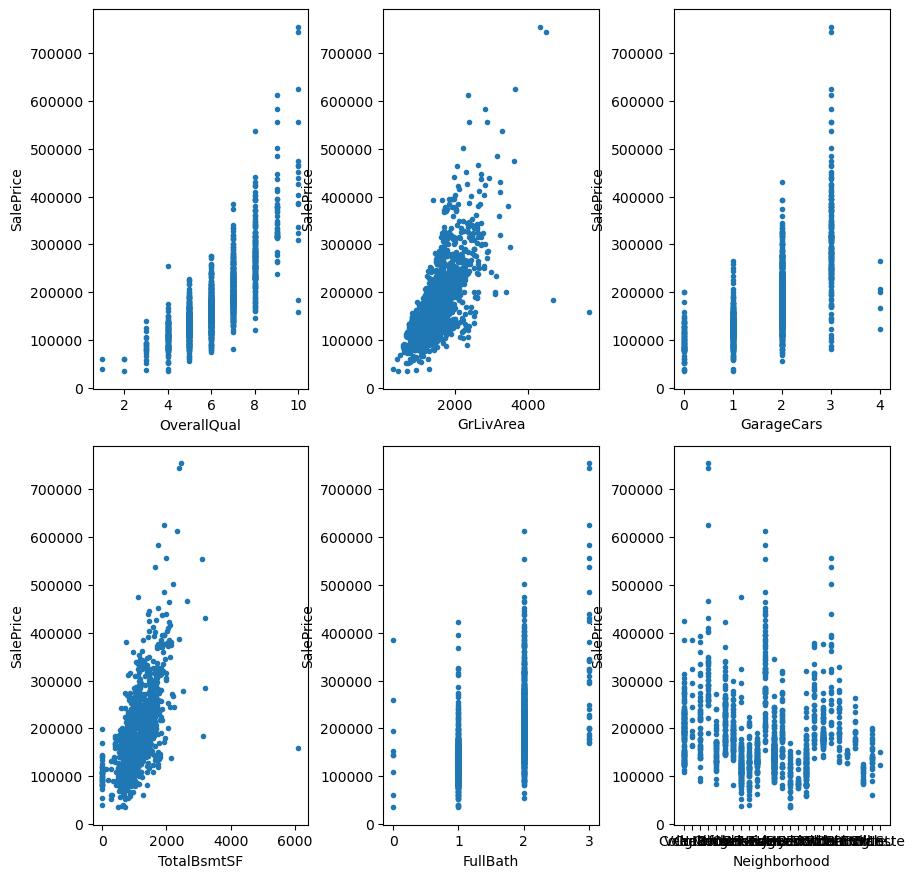

In [56]:
# From previous analysis
# Correlation ---------------
# OverallQual        0.790982
# GrLivArea          0.708624
# GarageCars         0.640409
# GarageArea         0.623431
# TotalBsmtSF        0.613581
# 1stFlrSF           0.605852
# FullBath           0.560664
# TotRmsAbvGrd       0.533723
# YearBuilt          0.522897
# YearRemodAdd       0.507101
# MI ------------------------
# neighbourhood      0.5059


plot_feat = ["OverallQual", "GrLivArea", "GarageCars", "TotalBsmtSF", "FullBath", "Neighborhood"]
show_target_pairplot(df_data, plot_feat, TARGET_COL)


# Observations
# There are some very low SalePrice for a few houses with OverallQual == 10. 
# There a couple of suspicius low price houses having a very big GrLivAre. Maybe is an old house, the OveralQual or they are  the same having a high OverallQual and is a data error?
# A few houses having 4 carage cars and the price is very low. These values are not following the general trend.
# TotalBsmtSF has a similar shape than GrLivArea, but has an outlier with a lot of SF and a very low price. 
# There are two prices higher thant 700.000, corresponding to high standard features. However, the sd still is very high, it might worth trying winsorization.
# YearBuilt and YearRemodAdd are kind of noisy. 

### Functions

In [57]:
def get_iqr(df, feature):
  q1, q3 = df[feature].quantile([0.25, 0.75])
  iqr = q3 - q1
  return q1, q3, iqr

def get_iqr_bounds(q1, q3, iqr, interval=1.5):
    lower = q1 - interval * iqr
    upper = q3 + interval * iqr
    return lower, upper


def remove_outliers(df_rem, features, interval=1.5):
    df = df_rem.copy()
    updated = False
    for col in features:
        skew = df[col].skew()
        #print(col, "Skew:", skew)
        if abs(skew) > 0.5:
            q1, q3, iqr = get_iqr(df, col)
            lower, upper = get_iqr_bounds(q1, q3, iqr, interval=interval)        
            #print(col, "q1", q1, "q3: ", q3)
            #print(col, "iqr", iqr, "lower: ", lower, "upper: ", upper)
            # print("Outliers up: ", df[df[col] > upper][col].count())
            # print("Outliers low: ", df[df[col] < lower][col].count())
    
            old_cnt = df.shape[0]
            df_rem = df[df[col] <= lower]
            df_rem = df[df[col] >= upper]
            df = df[df[col] > lower]
            df = df[df[col] < upper]
    
            #print(old_cnt - df.shape[0], "Outliners Rows removed for col", col)
        if not updated:
          # print("New shape", df.shape)
          # print(df_rem.shape[0]- df.shape[0], "Outliners Rows removed in total")
        #else:
          # print("No rows removed")
          df_rem = df_rem[~df_rem.index.isin(df.index)]
        return df, df_rem

### Tests

In [58]:
# Let try fixing the spoted values and plot again
df = df_data.copy()
df = df[~((df["GrLivArea"] > 4000) & (df["SalePrice"] < 200000))]
# Now the plots looks better
# GarageCars == 4 is not given usefull information, let's try to change it to 3 and see
df["GarageCars"] = df["GarageCars"].replace(4, 3)


# Let's try winorization with values over 99.5% quantile
if False:
  q = df["SalePrice"].quantile(0.99)
  print("Winsorization q:", q)
  df["SalePrice"] = df["SalePrice"].apply(lambda x: q if x > q else x)

# Capping by value
if True:
  df = df[df["SalePrice"] < 700000]
  
# NoRidge neighborhood outilers analysis
if False:
  # Neighborhood = NoRidge
  df[df["SalePrice"] > 700000]["Neighborhood"]
  print(df[df["Neighborhood"] == "NoRidge"]["SalePrice"].mean())
  print(df[df["Neighborhood"] == "NoRidge"]["SalePrice"].std())
  
  dfr = df[df["Neighborhood"] == "NoRidge"]
  dfr["zscore"] = dfr["SalePrice"].apply(lambda x: (x - dfr["SalePrice"].mean()) / dfr["SalePrice"].std())
  dfr[["SalePrice", "zscore"]].sort_values(by="SalePrice", ascending=False).head(10)

# Removing Outliers using IQR
if False:
  df, dfrem = remove_outliers(df, ["SalePrice"])

df.head()

#show_target_pairplot(df, plot_feat, TARGET_COL)
#show_target_pairplot(df, plot_feat, LOGP_TARGET_COL)
# Check new correlation
#df_corr_logp = df.corr(numeric_only=True)[np.abs(df.corr(numeric_only=True)[LOGP_TARGET_COL].values) > 0.5].sort_values(by=LOGP_TARGET_COL, ascending=False)
#print(df_corr_logp[LOGP_TARGET_COL])

# Observations
# Removing outliers based on GrLivArea also improves plots
# Clipping GaragetCars to 3 seems to make plots better
# Applying winsorization of 0.999 to SalePrice for very hight values makes the plots a little bit better. Same capping values > 700000
# Even using LOGP target, the high prices for NoRidge Neigborhood looks are souspicius
# Final shape applying IQR is good, but a lot of rows are removed
# Correlation has improved after this changes

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,SalePrice_log1p,BuiltSF,BuiltRatio,NonBuiltSF,LotFrontage_neig_mean
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NA,0,2,2008,WD,Normal,208500,12.247699,3114,2.713552,5336,71.682540
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NA,0,5,2007,WD,Normal,181500,12.109016,2984,3.217158,6616,59.714286
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NA,0,9,2008,WD,Normal,223500,12.317171,3314,3.394689,7936,71.682540
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NA,0,2,2006,WD,Abnorml,140000,11.849405,3115,3.065811,6435,71.804878
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NA,0,12,2008,WD,Normal,250000,12.429220,4179,3.412300,10081,91.878788


In [59]:

dfi = df_base_data.copy()
col = "BldgType"
dfi[~dfi[col].isin(CLASS_COLS_VALUES[col])][col]
dfi[dfi[col] == "Duplx"][col]
#df_base_data["Exterior2nd"].value_counts()
#df_base_data["BldgType"].isnull().sum()

# Low cols: ['BldgType', 'Exterior2nd']
# Categories for col BldgType : ['1Fam', '2FmCon', 'Duplx', 'TwnhsE', 'TwnhsI']
# Categories for col Exterior2nd : ['AsbShng', 'AsphShn', 'BrkComm', 'BrkFace', 'CBlock', 'CemntBd', 'HdBoard', 'ImStucc', 'MetalSd', 'Other', 'Plywood', 'PreCast', 'Stone', 'Stucco', 'VinylSd', 'Wd Sdng', 'WdShing']

Series([], Name: BldgType, dtype: str)

## Normalization

In [60]:

#log1p_cols = ["GarageArea", "GrLivArea", "LotArea", "LotFrontage", "1stFlrSF"]

df_norm = df_data.copy()

df_norm.drop([LOGP_TARGET_COL, TARGET_COL], axis=1, inplace=True)
norm_cols = [col for col in df_norm.columns[df_norm.dtypes != "str"] if col not in ["GarageArea", "GrLivArea", "LotArea", "LotFrontage", "1stFlrSF"]]


#df_norm.dtypes


## Residuals

### Functions

In [61]:
def study_residuals(X, y, pip, model, remove_idx=None, plot=True):
  if remove_idx is not None:
    X = X[~X.index.isin(remove_idx)]
    y = y[~X.index.isin(remove_idx)]

  Xt = pip.fit(X, y).transform(X)

  preds = model.fit(Xt, y).predict(Xt)
  residuals =  y - preds
  if plot:
    plt.scatter(preds, residuals, alpha=0.5)
    plt.axhline(0, color='red')
    plt.xlabel("Predicted")
    plt.ylabel("Resisuals")
    plt.show()

  df_res = pd.DataFrame({
    "y": y,
    "pred": preds,
    "residual": residuals
  }, index=X.index)

  df_res["abs_res"] = np.abs(df_res["residual"])
  df_res["bin"] = pd.qcut(df_res["pred"], 5)
  return df_res

def get_residuals_idx(X, y, pip, model, res_filter=None):
  df_res = study_residuals(X, y, pip, model=model, plot=False)
  if res_filter is not None:
    return df_res[df_res["residual"].abs() > res_filter].index
  return df_res.index

def remove_residuals(X, y, pip, model, res_filter=0.25):
  X = X.copy()
  y = y.copy()
  rem_res_idx = get_residuals_idx(X, y, pip, model, res_filter)
  X = X[~X.index.isin(rem_res_idx)]
  y = y[~y.index.isin(rem_res_idx)]
  return X, y


# Preprocessing

## Split Data

In [284]:
def get_base_data(df=None, debug=False):
  # Using original data to avoid leaking
  df_base_data = df_raw_data.copy()
  if df is not None:
    df_base_data = df.copy()
  # Transforming Target column
  df_base_data[LOGP_TARGET_COL] = np.log1p(df_base_data[TARGET_COL])

  # Removing GrLivArea outilers
  glArea = 4000
  lotFrontage = 200
  if debug:
    print(f"Removing GrLivArea > {glArea}")
    print(f"Removing LotFrontage > {lotFrontage}")
  df_base_data = df_base_data[df_base_data["GrLivArea"] < glArea]
  # mssubclass_rem_idx = df_base_data[(df_base_data["MSSubClass"] == 70) & (np.log1p(df_base_data["SalePrice"]) > 12.6).index
  # df_base_data = df_base_data[~df_base_data.index.isin(mssubclass_rem_idx)]
  df_base_data = fix_invalid(df_base_data)

  # Removing categories with one value. Check initial processing
  #singleton_rows_id = [666, 120, 271, 1275, 1298, 325, 250, 595, 1370, 1011, 1187, 1370, 1321, 1386, 583, 1003, 1230, 398, 944]
  #df_base_data = df_base_data[~df_base_data.index.isin([325, 250])]
  #df_base_data = df_base_data[~df_base_data.index.isin(singleton_rows_id)]
  return df_base_data

def train_data_for_submission():
  X = get_base_data(df_raw_data)
  y_orig = X.pop(TARGET_COL)
  y = X.pop(LOGP_TARGET_COL)
  return X, y, y_orig

def split_data(df, test_size=TEST_PORCENT, target_col=LOGP_TARGET_COL,
               original_target_col=TARGET_COL, random_state=RANDOM_STATE, group_field=None):
  if group_field is None or group_field == "":
    df_train, df_test = train_test_split(
        df,
        test_size=test_size,
        random_state=random_state,
        shuffle=True
    )
    y = df_train.pop(target_col)
    y_orig = df_train.pop(original_target_col)
    X = df_train
    y_test = df_test.pop(target_col)
    X_test = df_test.drop(columns=original_target_col)
    return X, y, y_orig, X_test, y_test

  # Using grouped split

  X = df.copy()
  y = X.pop(target_col)
  y_orig = X.pop(original_target_col)

  groups = X[group_field]
  gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
  train_idx, test_idx = next(gss.split(X, y, groups))

  X_train, X_test = X[X.index.isin(train_idx)], X[X.index.isin(test_idx)]
  y_train, y_train_orig, y_test = y[y.index.isin(train_idx)], y_orig[y_orig.index.isin(train_idx)], y[y.index.isin(test_idx)]
  
  return X_train, y_train, y_train_orig, X_test, y_test

def split_train_test_data(group_field=None):
  return split_data(get_base_data(), test_size=TEST_PORCENT, random_state=RANDOM_STATE, group_field=group_field)



## Nulls, Invalid and uncommon data transformation

In [63]:
class FixNullsTransformation(BaseEstimator, TransformerMixin):
  def __init__(self, debug=False):
    self.X_train = None
    self.debug = debug

  def fit(self, X, y=None):
    self.X_train = X
    self.fitted_ = True
    return self

  def transform(self, X, y=None):
    return fix_nulls(X, self.X_train, debug=self.debug)

class FixInvalidTransformation(BaseEstimator, TransformerMixin):
  def __init__(self, debug=False):
    self.X_train = None
    self.debug = debug

  def fit(self, X, y=None):
    self.X_train = X
    self.fitted_ = True
    return self

  def transform(self, X, y=None):
    return fix_invalid(X)

class ReplaceUncommonTransformation(BaseEstimator, TransformerMixin):
  def __init__(self, debug=False):
    self.X_train = None
    self.debug = debug

  def fit(self, X, y=None):
    self.X_train = X
    self.fitted_ = True
    return self

  def transform(self, X, y=None):
    return replace_uncommon(X)




## Drop and Binary Transformation

In [64]:
"""
 DropTransformation
"""
class DropTransformation(BaseEstimator, TransformerMixin):

  def __init__(self, columns):
    self.columns = columns

  def fit(self, X, y=None):
    self.fitted_ = True
    return self

  def transform(self, X, y=None):
    # Removing unused columns
    X = X.drop(labels=self.columns, axis=1, errors='ignore')
    return X

"""
Binary transformer
"""
class BinaryTransformation(BaseEstimator, TransformerMixin):
  def __init__(self, bin_cols, bin_spec):
    self.bin_cols = bin_cols
    self.bin_spec= bin_spec

  def fit(self, X, y=None):
    self.fitted_ = True
    return self

  def to_binary_(self, val, spec):
    if isinstance(val, str):
      return 1 if val == spec["true_val"] else 0
    elif isinstance(val, (int, float)):
      return 1 if val > 0 else 0

  def transform(self, X):
    X = X.copy()
    # Adding binary fields
    drop_cols = []
    for c in self.bin_cols:
      spec = self.bin_spec.get(c, {"drop": False, "true_val": 1})
      X[f"Has{c}"] = X[c].apply(lambda x: self.to_binary_(x, spec))
      if spec["drop"]:
        drop_cols.append(c)
    X = X.drop(columns=drop_cols, errors="raise")
    return X

"""
 Create groups using target encoder
"""
def get_groups(X, y, column):
  enc = ce.TargetEncoder(cols=[column], smoothing=10).fit(X[column], y)
  return enc.transform(X[[column]])

## Categories

### Enconding Functions

In [611]:

def get_ordinal_cat_value(x, col, ord_cat_maps):
  # my_map is un unhappy name. Fixing that
  return my_map(x, col, ord_cat_maps)

def my_map(x, col, ord_cat_maps):
    values = ord_cat_maps.get(col, {"empty_val": ""})
    # Default to x if not in the mapping. If its not the correct value it will raise an error
    val = values.get(x, x)
    if pd.isna(x):
        val = -1
    return val

def ordinal_encode(X, ord_cat_maps):
    """
    Ordinally encodes specified columns in a DataFrame using provided category-to-integer mappings.

    Args:
        df (pd.DataFrame): DataFrame containing columns to encode.
        ord_cat_maps (dict): Dictionary mapping column names to their category-to-integer mappings.

    Returns:
        pd.DataFrame: DataFrame with ordinally encoded columns.
    """
    X = X.copy()
    cols = X.columns.tolist()
    for col in cols:
        if col in ord_cat_maps:
            X[col] = X[col].apply(lambda x: get_ordinal_cat_value(x, col, ord_cat_maps))

    #print("ord cat map new:", X.head(1))
    return X



In [199]:

def classify_columns(df, k=MAX_OHE_CARDINALITY):
    """
    Extracts numeric and categorical columns from a DataFrame, and splits categorical columns into low and high cardinality based on a threshold k.

    Args:
        df (pd.DataFrame): Input dataframe.
        k (int): Threshold for maximum unique values to consider a column low cardinality.

    Returns:
        num_cols (Index): Numeric columns.
        low_cardi (Index): Categorical columns with fewer than k unique values.
        high_cardi (Index): Categorical columns with k or more unique values.
    """
    # Not including category type because the data is loaded from a csv and 
    # the columns are not set to category type by default.
    cat_cols = df.select_dtypes(include=["str"]).columns
    num_cols = df.select_dtypes(include=[np.number]).columns

    # low_cardi = [col for col in cat_cols if df[col].nunique() < k] 
    # high_cardi = [col for col in cat_cols if df[col].nunique() >= k]
    low_cardi = [col for col in cat_cols if col != "Neighborhood"]
    high_cardi = ["Neighborhood"]
    return num_cols, low_cardi, high_cardi


def get_cat_cols_df(df, ord_cols):
  df = df.copy().drop(columns=ord_cols, errors="ignore")
  return classify_columns(df, k=MAX_OHE_CARDINALITY)

def get_groups(X, y, column):
  enc = ce.TargetEncoder(cols=[column], smoothing=10).fit(X[column], y)
  return enc.transform(X[[column]]).values.flatten()


### Category Transformation

#### Generic

In [223]:
"""
GenericCategoryTransformation
"""
class GenericCategoryTransformation(BaseEstimator, TransformerMixin):

  def __init__(self, ord_cols=ORD_COLS, ord_cat_maps=ORD_COLS_VALUES, class_cat_maps=CLASS_COLS_VALUES):
    self.ord_cols = ord_cols
    self.ord_cat_maps = ord_cat_maps
    self.target_encoder = None
    self.one_hot_encoder = None
    self.low_nom_cols = None
    self.high_nom_cols = None
    self.num_cols = None
    self.class_cat_maps = class_cat_maps

  def ordinal_categories_(self, X):
    categories = []
    for c in X.columns.tolist():
      vals = self.ord_cat_maps.get(c, None)
      if vals is None:
        raise ValueError("There's no values for ordinal category", c)
      categories.append(list(vals.keys()))
    return categories

  def fit(self, X, y=None):
    #print("Linear cat transf fit")
    # Selecting Categorical columns from low cardinality categories
    df_data_no_ord = X.drop(labels=self.ord_cols, axis=1)
    # Extracting numeric and categorical columns with low and high cardinality
    num_cols, low_cols, hi_cols = classify_columns(df_data_no_ord, k=MAX_OHE_CARDINALITY)
    subClassCol = "MSSubClass"
    low_cols.append(subClassCol)
    # Removing subClassCol from num_cols because it is categorical
    num_cols = [x for x in num_cols if x != subClassCol]
    self.low_nom_cols = low_cols
    self.column_transformer = ColumnTransformer(
      transformers=[
        ('target', ce.TargetEncoder(cols=hi_cols, smoothing=10), hi_cols),
        ('ordinal', OrdinalEncoder(categories=self.ordinal_categories_(X[self.ord_cols]), dtype=np.int32), self.ord_cols),
        ('onehot', OneHotEncoder(categories=[self.class_cat_maps[col] for col in low_cols], sparse_output=False, \
                                         drop="first", handle_unknown="infrequent_if_exist", \
                                        max_categories=10, min_frequency=3), low_cols),
        ('passthrough', 'passthrough', num_cols)
      ], verbose_feature_names_out=False
    ).fit(X, y)
    self.fitted_ = True
    return self

  def transform(self, X):
    t_data = self.column_transformer.transform(X)
    out_features = self.column_transformer.get_feature_names_out()
    out_features = [c for c in out_features]
    dtf = pd.DataFrame(t_data, columns=out_features, index=X.index)
    return dtf

#### Linear models

In [650]:
"""
 LinearCategoryTransformation
"""
class LinearCategoryTransformation(BaseEstimator, TransformerMixin):

  def __init__(self, ignored_cols, ord_cols=ORD_COLS, ord_cat_maps=ORD_COLS_VALUES, class_cat_maps=CLASS_COLS_VALUES):
    self.ord_cols = ord_cols
    self.ord_cat_maps = ord_cat_maps
    self.ignored_cols = ignored_cols
    self.target_encoder = None
    self.one_hot_encoder = None
    self.low_nom_cols = None
    self.high_nom_cols = None
    self.num_cols = None
    self.class_cat_maps = class_cat_maps

  def fit(self, X, y=None):
    #print("Linear cat transf fit")
    # Selecting Categorical columns from low cardinality categories
    df_ord = X[self.ord_cols]
    df_data_no_ord = X.drop(labels=self.ord_cols, axis=1)

    # Extracting numeric and categorical columns with low and high cardinality
    num_cols, low_cols, hi_cols = classify_columns(df_data_no_ord, k=MAX_OHE_CARDINALITY)
    hi_cols = ["Neighborhood"]
    # MSZoning doesn't improve performance when TargetEncoded???
    low_cols = [col for col in low_cols \
                 if col not in hi_cols]
    subClassCol = "MSSubClass"
    low_cols.append(subClassCol)
    num_cols = [x for x in num_cols if x != subClassCol]

    self.target_encoder = ce.TargetEncoder(cols=hi_cols, smoothing=10).fit(X[hi_cols], y)

    class_categories = [self.class_cat_maps[col] for col in low_cols]
    self.one_hot_encoder = OneHotEncoder(categories=class_categories, sparse_output=False, \
                                         drop="first", handle_unknown="infrequent_if_exist", \
                                        max_categories=10, min_frequency=3)
    self.one_hot_encoder.fit(X[low_cols])
    self.num_cols = num_cols
    self.low_nom_cols = low_cols
    self.high_nom_cols = hi_cols
    self.fitted_ = True
    return self

  def transform(self, X):
    # Copying data to avoid modifying the original DataFrame by mistake
    X = X.copy()
    # One-hot encoding low cardinality categorical columns
    ohe_feature_names = self.one_hot_encoder.get_feature_names_out(self.low_nom_cols)
    df_low_nominal = pd.DataFrame(self.one_hot_encoder.transform(X[self.low_nom_cols]), columns=ohe_feature_names, index=X.index)
    df_ord = ordinal_encode(X[self.ord_cols], self.ignored_cols)
    df_target_encoded = self.target_encoder.transform(X[self.high_nom_cols])
    ohe_feature_names = self.one_hot_encoder.get_feature_names_out(self.low_nom_cols)

    X = pd.concat([X[self.num_cols], df_ord, df_low_nominal, df_target_encoded], axis=1)

    return X

#### Tree models

In [645]:
"""
 TreeCategoryTransformation
"""
class TreeCategoryTransformation(BaseEstimator, TransformerMixin):

  def __init__(self, ignored_cols, ordered_map, nominal_map):
    self.ignored_cols = ignored_cols
    self.ordered_map = ordered_map
    self.nominal_map = nominal_map

  def fit(self, X, y=None):
    self.fitted_ = True
    return self

  def transform(self, X):
    # Copying data to avoid modifying the original DataFrame by mistake
    X = X.copy()
    cat_cols = [x for x in X.columns if x not in X.select_dtypes(include=[np.number]).columns]
    cat_cols = [x for x in cat_cols if x not in self.ignored_cols]
    # Using target encoding for the cols below
    cat_cols = [x for x in cat_cols if x not in ["Neighborhood"]]
    for col in cat_cols:
      ordered = False
      values = self.nominal_map.get(col, None)
      if values == None:
        ordered = True
        values = self.ordered_map.get(col, None)

      if values == None:
        raise ValueError(f"Column '{col}' not found in either ordered_map or nominal_map.")
      if col != "GarageQual":
        X[col] = pd.Categorical(X[col], categories=values, ordered=ordered)
        X[col] = X[col].astype("category")
      else:
        X[col] = X[col].astype("category")

    return X


#### Tests

In [621]:



"""
 OrdCategoryDistTransformation
"""
class OrdCategoryDistTransformation(BaseEstimator, TransformerMixin):
  def __init__(self, ignored_cols):
    self.ignored_cols = ignored_cols

  def fit(self, X, y=None):
    self.fitted_ = True
    return self

  def transform(self, X):
    # Creating new neigborhood bins some signal was lost.
    # Using a more conservative aproach by joining only categories having a few values and similar mean value
    X = X.copy()
    X = improve_ord_cat_distribution(X, self.ignored_cols)
    return X

"""
 NomCategoryDistTransformation
"""
class NomCategoryDistTransformation(BaseEstimator, TransformerMixin):
  def __init__(self):
    pass

  def fit(self, X, y=None):
    #self.df_bins = create_bins_by_target_and_count(df, self.cat_col, min_delta=0.050)
    self.fitted_ = True
    return self

  def transform(self, X):
    # Creating new neigborhood bins some signal was lost.
    # Using a more conservative aproach by joining only categories having a few values and similar mean value
    X = X.copy()
    X["Neighborhood"] = X["Neighborhood"].replace({"Veenker": "Timber", "Blueste": "SWISU", "NPkVill": "NAmes"})
    X["MSSubClass"] = X["MSSubClass"].replace({75: 80, 40: 85, 180: 30})
    #X["MSZoning"] = X["MSZoning"].replace({"RH": "RM"}) # -> Does nothing
    #X["OverallCond"] = X["OverallCond"].replace({1: 3, 2: 3, 9: 5})# ==> Not working
    #X["OverallCond"] = X["OverallCond"].replace({1: 3, 2: 3})# ==> Not working
    #X_t = update_feat_dist(X, self.df_bins, self.cat_col)
    return X


"""
 NoTargetEncCategoryTransformation
"""
class NoTargetEncCategoryTransformation(BaseEstimator, TransformerMixin):

  def __init__(self, ignored_cols, ord_cols=ORD_COLS, ord_cat_maps=ORD_COLS_VALUES, class_cat_maps=CLASS_COLS_VALUES):
    self.ord_cols = ord_cols
    self.ord_cat_maps = ord_cat_maps
    self.ignored_cols = ignored_cols
    self.one_hot_encoder = None
    self.low_nom_cols = None
    self.high_nom_cols = None
    self.num_cols = None
    self.class_cat_maps = class_cat_maps

  def fit(self, X, y=None):
    # Removing ignored columns
    X = X.drop(columns=self.ignored_cols)
    # Selecting Categorical columns from low cardinality categories
    df_ord = X[self.ord_cols]
    df_data_no_ord = X.drop(labels=self.ord_cols, axis=1)

    # Extracting numeric and categorical columns with low and high cardinality
    num_cols, low_cols, hi_cols = classify_columns(df_data_no_ord, k=MAX_OHE_CARDINALITY)
    subClassCol = "MSSubClass"
    low_cols.append(subClassCol)
    num_cols = [x for x in num_cols if x != subClassCol]
    high_cols = ["Neighborhood"]

    class_categories = [self.class_cat_maps[col] for col in low_cols]


    self.one_hot_encoder = OneHotEncoder(categories=class_categories, sparse_output=False, drop="first", handle_unknown="infrequent_if_exist").fit(X[low_cols])

    self.num_cols = num_cols
    self.low_nom_cols = low_cols
    self.high_nom_cols = hi_cols
    self.fitted_ = True
    return self


  def transform(self, X):
    # Copying data to avoid modifying the original DataFrame by mistake
    X = X.copy()
    #print("low nom categories:", self.low_nom_cols)
    # One-hot encoding low cardinality categorical columns
    ohe_feature_names = self.one_hot_encoder.get_feature_names_out(self.low_nom_cols)
    df_low_nominal = pd.DataFrame(self.one_hot_encoder.transform(X[self.low_nom_cols]), columns=ohe_feature_names, index=X.index)
    df_ord = ordinal_encode(X[self.ord_cols], self.ord_cat_maps)
    df_nbh = pd.DataFrame(X["Neighborhood"].astype("category"), columns=["Neighborhood"])
    df_nbh["Neighborhood"] = df_nbh["Neighborhood"].cat.codes
    ohe_feature_names = self.one_hot_encoder.get_feature_names_out(self.low_nom_cols)

    X = pd.concat([X[self.num_cols], df_ord, df_low_nominal, df_nbh], axis=1)

    return X





"""
 ROCCategoryTransformation
"""
class ROCCategoryTransformation(BaseEstimator, TransformerMixin):

  def __init__(self, ignored_cols, ord_cols=ORD_COLS, ord_cat_maps=ORD_COLS_VALUES):#, class_cat_maps=CLASS_COLS_VALUES):
    self.ord_cols = ord_cols
    self.ord_cat_maps = ord_cat_maps
    self.ignored_cols = ignored_cols
    self.nom_cols = None
    self.num_cols = None
    #self.class_cat_maps = class_cat_maps

  def fit(self, X, y=None):
    # Removing ignored columns
    X = X.drop(columns=self.ignored_cols)
    #  Classifying columns in type
    df_ord = X[self.ord_cols]
    df_data_no_ord = X.drop(labels=self.ord_cols, axis=1)

    # Extracting numeric and categorical columns
    num_cols = df_data_no_ord.select_dtypes(include=[np.number]).columns.tolist()
    nom_cols = df_data_no_ord.drop(columns=num_cols).columns.tolist()
    subClassCol = "MSSubClass"
    nom_cols.append(subClassCol)
    num_cols = [x for x in num_cols if x != subClassCol]
    self.num_cols = num_cols
    self.nom_cols = nom_cols
    self.fitted_ = True
    return self


  def transform(self, X):
    # Copying data to avoid modifying the original DataFrame by mistake
    X = X.copy()
    df_nominal = X[self.nom_cols].astype("category")
    for c in df_nominal.columns.tolist():
      df_nominal[c] = df_nominal[c].cat.codes
    df_ord = ordinal_encode(X[self.ord_cols], self.ord_cat_maps)

    X = pd.concat([X[self.num_cols], df_ord, df_nominal], axis=1)
    return X



## Scalers and Distribution Transformation


In [71]:
"""
Log1P transformer
"""
class Log1PTransformation(BaseEstimator, TransformerMixin):
  """
  Applies log1p transformation to specified columns.
  """
  def __init__(self, columns):
    self.columns = columns

  def fit(self, X, y=None):
    self.fitted_ = True
    return self

  def transform(self, X, y=None):
    # Copying data to avoid modifying the original DataFrame by mistake
    X = X.copy()
    X[self.columns] = np.log1p(X[self.columns])
    return X

"""
Sqrt transformer
"""
class SqrtTransformation(BaseEstimator, TransformerMixin):
  """
  Applies sqrt transformation to specified columns.
  """
  def __init__(self, columns):
    self.columns = columns

  def fit(self, X, y=None):
    self.fitted_ = True
    return self

  def transform(self, X, y=None):
    # Copying data to avoid modifying the original DataFrame by mistake
    X = X.copy()
    X[self.columns] = np.sqrt(X[self.columns])
    return X



"""
Standard Scaler
"""
class StandardScalerTransformation(BaseEstimator, TransformerMixin):
  """
  Applies standard normalization to specified columns.
  """
  def __init__(self, columns):
    self.columns = columns
    self.scaler = StandardScaler()

  def fit(self, X, y=None):
    self.scaler.fit(X[self.columns])
    self.fitted_ = True
    return self

  def transform(self, X, y=None):
    # Copying data to avoid modifying the original DataFrame by mistake
    X = X.copy()
    x_index = X.index
    norm = self.scaler.transform(X[self.columns])
    df_norm = pd.DataFrame(norm, columns=self.columns, index=x_index)
    X[self.columns] = df_norm
    return X



In [72]:
# norm_cols = ['YearBuilt', 'YearRemodAdd','MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '2ndFlrSF', 'LowQualFinSF', 'WoodDeckSF', 'OpenPorchSF', 'PoolArea']
# tdf = df_base_data.copy()[norm_cols]
# tdf.head()
# sc = StandardScalerTransformation(norm_cols)
# sc.fit(tdf)
# tran = sc.transform(tdf)
# tran.head()

# Experiment

## Baseline

In [325]:
# For baseline, category columns will be enconded without any transformation or processing to get an initial idea of performance 

run_label = "baseline"
group_field = "MSZoning"
X, y, _, X_test, y_test = split_train_test_data(group_field)

pipeline =  Pipeline([
  ("init_drop", DropTransformation(columns=[LOGP_TARGET_COL, TARGET_COL, "Id"])),
  ("fix_nulls", FixNullsTransformation()),
  ("encode", GenericCategoryTransformation(ord_cols=ORD_COLS, ord_cat_maps=ORD_COLS_VALUES)),
])

print("Train dataset shape:", X.shape)
print("Test dataset shape:", X_test.shape)

desc = "Basic category enconding. No data transformation. No feature engineering\n"
groups=None
if group_field is not None and group_field != "":
  groups = X[group_field]
  desc+= f"Using groups by: {group_field}"

#Xt = pipeline.fit(X, y).transform(X)
#Xt[Xt.isnull()].shape
#Xt.isnull().sum()
# Xt["LandSlope"].value_counts()
eval_models(X, y, X_test, y_test, [pipeline, pipeline], label=run_label, \
              clear_scores=True, desc=desc, show_cv_error=True, pred_test=True, groups=groups)

#show_global_scores()
#plot_scores()
show_scores_stats(show_test=True)

Train dataset shape: (1436, 80)
Test dataset shape: (16, 80)
Saving score in memory result for model: Linear Regression
Saving score in memory result for model: Lasso
Saving score in memory result for model: ElasticNet
Saving score in memory result for model: Ridge
Saving score in memory result for model: XGBRegressor
{'name': 'Ridge', 'abrev': 'Rig', 'instance': Ridge(alpha=10.0)}
{'name': 'Ridge', 'abrev': 'Rig', 'instance': Ridge(alpha=10.0)}
Saving score in memory result for model: Stack1
{'name': 'Ridge', 'abrev': 'Rig', 'instance': Ridge(alpha=10.0)}
{'name': 'Ridge', 'abrev': 'Rig', 'instance': Ridge(alpha=10.0)}
Saving score in memory result for model: Stack2
------------------------------
Last Run: 1 - baseline
------------------------------
Model: LiRe CV_MEAN: 0.4878 (0.0434), TRN_RMSE: 0.0972 TST_RMSE: 0.1176
Model: Lasso CV_MEAN: 0.2498 (0.1478), TRN_RMSE: 0.1092 TST_RMSE: 0.0802
Model: ENet CV_MEAN: 0.2239 (0.1432), TRN_RMSE: 0.1134 TST_RMSE: 0.0787
Model: Rig CV_MEAN: 0.

## Engineering

### Functions

In [326]:
### Functions
class DescriptionBuilder:
  """
  A class to build a description string for the data processing steps.

  Attributes:
    desc (str): The description string.
  """

  def __init__(self):
    self.desc = ""

  def append(self, text):
    self.desc += text + "\n"
    return self

  def get(self):
    return self.desc

def drop_cols(X, X_test, cols):
  X = X.drop(labels=cols, axis=1, errors="raise")
  X_test = X_test.drop(labels=cols, axis=1, errors="raise")
  return X, X_test

def get_ord_cols(by="used", used=[], removed=[], ord_cols=ORD_COLS):
  return get_cols(by=by, used=used, removed=removed, all_cols=ord_cols)

def get_nom_cat_cols(by="used", used=[], removed=[], cat_cols=[]):
  return get_cols(by=by, used=used, removed=removed, all_cols=cat_cols)

def get_cols(by="used", used=[], removed=[], all_cols=[]):
  cols_to_remove = removed.copy()
  cols_to_use = used.copy()
  if by == "used":
    cols_to_remove = [x for x in all_cols if x not in used]
  elif by == "removed":
    cols_to_use = [x for x in all_cols if x not in removed]
  else:
    raise ValueError("by must be 'used' or 'removed'")

  return cols_to_use, cols_to_remove

### PROCESS DESCRIPTION _____________________ 


**1**
- Adding PoolQC the score goes up. => it's a noisy feature that has to be removed. Adding HasPool Feat doesn't change the score. Perhaps PoolArea is enough for pool information.
- Removing all ordinals cols and adding HasPool doesn't have impact in CV
- By removing all ordinal categories the score has reduced more than 0.01. Let's play with them to see if we can improve the score by adding one by one, with or without transformatios.

**2**
- Adding only LandSlope the score goes up to 0.1412
- After fixing some issue in **encode_categories** function, removing all ordinal columns is now a little bit worse than baseline (0.1408). Starting again analisis.
- Baseline is 0.1400

**3**
- For now will leave categories using HeatingQC, ExterQual and ExternCond and continue playing with other aspects 
- ExterCond is unbalanced. Created a 1/0 feature and doesn't improve performance. There was only one row having value="Po" and it was removed. Performance is a little worse than using the field as it is.
- ExterQual is unbalanced but it does not have a clear way to collapse categories that improves performance. Leaving as it is.
- For HeatingHQ, there is one only value ="Po". Also, there are no values in test set. The row was removed and the performance continuous equal.
- Adding HeatingHC, ExterQual, ExternCond without transformations to ordinal cols used and removing all others improved performnance.
- Running all ordinal categories without any transformation one at a time  results in only HeatingHC, ExterQual, ExternCond performing better than baseline.

**4**
- Removing all non ordinal categories results in a degradation in the score. So, there is some signal lost there.
- By running using one non ordinal category features at a time, and using the ones that degrade the performance less, the score improves. These features are not the same than the list created ordering by MI. 
- MSZoning has a lot of signal.
- Removing all extreme imbalanced categories degrades the score.

**5**
- Using IQR in log1p SalePrice doesn't remove rows. 
- Applying winsorization doesn't improve the score. (Tryied with 0.95 and 0.99 quantiles)
- Capping SalePrice > 700000 and 600000 makes the performance decrease
- Capping SalePrice > 500000 makes the performance slightly better. But it is still better using IQR (SalePrice).
- Removing rows by using IQR on SalePrice improved the score a bit. Maintaining for now, but a lot of rows are removed.
- Removing GarageCars == 4 and changing it to 3 improves the score a little bit, but removed anyway to fit the general trend.
- Removing GrLivArea > 4000 and SalePrice < 200000 improves the score.
- Outliers

**6**
- Creating binary fields for columns having a lot of zero values doesn't improve the performance.

**7**
- Creating new fields improve performance in TreeModels and mostly XBRegressor. Simple linear regression has also improved a bit.

**8**
- Dividing residuals in 5 quantiles we can confirm that:
    - (12.301, 12.746]    0.063642
    - (12.082, 12.301]    0.060717
    - (11.894, 12.082]    0.057325
    - (11.714, 11.894]    0.064025
    - (10.632, 11.714]    0.093581
- Plotting residuals for Ridge, it shows that resituals are bigger for low prices.

**9**
- Start modeling. Tunning ridge, learning rate depends on data processing. There is no much improvement, it seems that weights are stable.

**10**
- Creating pipeline to apply to CV to fix leakage. 
- While adding an interaction term between "Neighborhood" and other fields, a leakage was found. Fixing will make CV score increase.

**11**
- Spend some time fixing leakage when cv. Improved process by using transformers and pipeline components.

**12**
- Start modeling
- Applyied log1p trasformation to some skewed features. Performance was improved.

**13**
- Predicting on test set get very bad results.
- Getting the best result using ElasticNet.
- Used and tuned Elastic Net and XGBRegressor. XGBRegressor is still overfiting. Maybe because of small dataset

**14**
- There was an issue initially while removing outliers on the whole dataset. After that the test performance got better.
- Investigating about poor performance in Test set.

**15**
- After the submission, I will  continue doing some feature selection with Lasso, some coeficient analysis and a deeper XGBoost parameter tuning.
- Having a achieving a fair performance in CV and test set an initial submition will be done in order to know how well the model is performing compared with other scripts.

**16**
- First submission (sad 0.18882 - rank: 3593)

**17**
- Still pending using Lasso for feature selection, tune XGBost and Stacking
- Improved Log1p and sqrt over eng features.
- CV goes up locally because some some data fixed in training and test set. 
- Second submission (0.13227 - rank: 1671). Still sad.

**18**
- Second submission (0.13096 - rank: 1572). Realizing that previous submission were done using only X_train to train data. Fixing that by using the whole dataset. 
- Third submission (0.13068 - rank: 1547). Removing test rows with GrLivArea > 4000

**19**
- 4th submission( 0.12711 - rank: 1132). Stacking LinearRegression, ElasticNet, XGBRegressor and Ridge as final estimator. Using tuned parameter independently.
- 5th submission (0.12909). Uncommenting interquartile outliers removal improves cv but degrades performance in kaggle.
- 6th submission (0.12705 - rank: 1113). Replacing uncommon values in test set (added to pipeline). 

**20**
- 7th submission (0.12605 - rank: 1005). Analizing Ridget residuals and removed all > abs(0.4) from X set.
- 8th submission (0.12573 - rank: 962). Removing Ridget residuals >  abs(0.3) from X set

**21**
- 9th submission (0.12528 - rank: 906). Analizing Ridget residuals and removed all > abs(0.25) from X set.

**22**
- Fixed BsmtFullBath and BsmtHalfBath to 0 when TotalBsmtSF = 0. This doesn't change performance in CV but in Kaggle gets worse.
- Also trying removing the row having LotFrontage > 200 (313) but performance doesn't improve in CV and degrades in kaggle. This outlier was spotted using kolmogorov and Smirnoff test comparing train and test distribution.

**23**
- Using XGBClassifier to check differencies between train and kaggle test distribution. AUC is  ~0.54 => there's not big difference.
- Removed target encoding. CV doesn't change, kaggle performance is worse
- Removed one hot encoding. CV doesn't change, kaggle performance is worse
- Removed eng features. CV doesn't change, kaggle performance is worse

**24**
- After tuning the models several times and testing on Kaggle different options trying to figure out what is the gap between local test set and kaggle test set, I took a more conservative approach to avoid overfitting.
  - For ElasticNet, a fixed alpha was used while trying to force L2 regularization. Then, alpha was tuned until getting some cv / train / test balance.
  - For XGBRegressor, a smaller learning rate, more trees but shallow and a more random sampling. Then, regularization.
  - After that, submission 28th (0.1243 - Rank 912) Using Stk1 (Stack LiRe, Enet, XGBRegressor => Ridge). Score has improved a little bit but still is far from cv and test)


**25**
- Updating Ordinal categories distributions. Joing categories having few training samples with other having similar sale price values. This updated kaggle score to 0.12403

**26**
- Updating Neghborhood and MSSubClass categories distributions focusing in reduce the mean value predicted for test data and real y. Kaggle score improved to 0.12394 (Rank 814). Still not able to  finde the distribution difference to get cv close to kaggle score.

**27**
- Changing CV strategy to GroupKFold. Studied Neighborhood, MSSubClass, OverallCond, OverallQual and MSZoning. MSZoning is the more similar score to prod.
- Also improving parameter tunning by using GroupKFold by  MSZoning groups and adding a train / cv table to decide about Bias / Variance traded of to avoid overfitting.
- Using Mann - Whitney test to compare category distributions and evaluate merging.
- Using Target Enconding for MSZoning improves score. Got 0.12334 in Kaggle (Rank 705)

**28**
- Reviewing pipeline and noticed that constant cols where included. While doing some tests about this and normalization CV goes down but test and Kaggle score increased. Saddly I make a mistake and miss the track of some steps causing this. For now will try to improve the Bias / Variance trade off and also testing other models like HuberRegressor (good for outilers) and LGMBRegressor. Also, creating a new stack.
- Then try to use coeff_ and feature_importance__ to review feature selection and engineering.

**29**
- Split the pipeline in two, one for linear models and other for tree models to take advantage of model features.
- Adapted evaluation functions to use the corresponding pipeline for each model. Including stacked models.
- Started working on tune HuberRegression to overcame convergence warning with the idea to create a new stack.
- New stack: Weak estimators -> HuberRegressor, Ridge, XGBRegressor, LGBMRegressor. Final -> XGBRegressor (or similar)
- Testing parameters **max_categories** and **min_frequency** for OneHotEncoder 
- HuberRegressor: Not able to  get a good score. Score improved when epsilong goes up => L2 regularization is more important than L1.

**30**
- After rearranging the pipeline and fixing some issues, I new submission was done to compare the current CV using GroupKFold (MSZoning) with the kaggle score. Now, the scores are similar. Let's see if following improvements are reflected on Kaggle.

**31**
- Analizing residuals (Stack1) ussing OOF for category MSZoning. Category C has a big residual mean and variance.
- Will try to add a binary feature (C=1) and apply a bias fix.
- There are some fixes to apply in the submission pipeline, like using "early stopping" for XGBRegressor

**32**
- After Applying a Bias Fix for MSZoning category C  using smoothing = 5, 10, 15, 20, 15..., 40 the best score obtained was the same that without applying the fix.

**33**
- Best score so far: 0.12331.
  - Target Encoding for Neighborhood and MSZoning for Linear Models
  - Target Encoding for Neighborhood ONLY in tree models.
  - Applied Ordinal distribution fix function (OrdCategoryDistTransformation)
  - Applied Nominal distribution fix function (NomCategoryDistTransformation) for Neighborhood and MSClass
  - Using GroupKFold by MSZoning for CV.
  - Using different pipelines for tree and linear models.
  - Using native Categories for XGBRegressor
- **Important** To make sure that this is the best pipeline so far, I uploaded a version without target encoding for MSZoning. CV goes up locally and also Kaggle score.




### Feature engineering

In [594]:
"""
 Feature Engineering
"""
class EngTransformation(BaseEstimator, TransformerMixin):

  def fit(self, X, y):
    #print("Eng trans fit")
    self.fitted_ = True
    return self

  def transform(self, X):
    X = X.copy()
    X["eng_TotalSF"] = X["TotalBsmtSF"] + X["1stFlrSF"] + X["2ndFlrSF"] + X["GarageArea"] + X["PoolArea"]
    X["eng_TotalSFTimesOverallQual"] =  X["eng_TotalSF"] * X["OverallQual"]
    X["eng_TotalSFTimesOverallCond"] =  X["eng_TotalSF"] * X["OverallCond"]
    X["eng_GarageAreaTimesQual"] = X["GarageArea"] * X["GarageQual"]
    X["eng_HouseAge"] = this_year() - X["YearBuilt"]
    X["eng_BathGrLivArea"] = X["FullBath"] + X["HalfBath"]
    X["eng_BathBsmt"] = X["BsmtFullBath"] + X["BsmtHalfBath"]
    X["eng_Bath"] = X["FullBath"] + X["HalfBath"] +  X["BsmtFullBath"] + X["BsmtHalfBath"]
    X["eng_GrLivAreaOverRoom"] = X["GrLivArea"] / (X["TotRmsAbvGrd"] + 1)
    X["eng_GrLivAreaOverBedroom"] = X["GrLivArea"] / (X["BedroomAbvGr"] + 1)
    X["eng_GrLivAreaOverBath"] =  X["GrLivArea"] / (X["eng_BathGrLivArea"] + 1)
    X["eng_TotalBsmtSFOverBath"] =  X["TotalBsmtSF"] / (X["eng_BathBsmt"] + 1)
    X["eng_GarageAreaOverCar"] = X["GarageArea"] / (X["GarageCars"] + 1)
    X["eng_NeighborhoodOverLotArea"] = X["Neighborhood"] / (X["LotArea"] + 1)
    X["eng_NeighborhoodTimesLotArea"] = X["Neighborhood"] * X["LotArea"]

# ['MSZoning', 'Alley', 'LotShape', 'LotConfig', 'Neighborhood', 'Condition1', 'Condition2', 
#  'BldgType', 'RoofMatl', 'Exterior1st', 'MasVnrType', 'ExterQual', 'ExterCond',
#  'Foundation', 'HeatingQC', 'Functional', 'GarageType', 'GarageFinish', 'GarageQual', 'PavedDrive', 'Fence',
#  'MiscFeature', 'SaleType', 'SaleCondition']

    
    return X



### Initial Processing

In [559]:
def initial_processing(X):
  desc = DescriptionBuilder()

  # Getting feature classification
  num_cols, low_cardi, high_cardi = get_cat_cols_df(X, ORD_COLS)
  nominal_cat_cols = low_cardi + high_cardi

  # Best Score class categories
  nominal_cat_cols_used = ["Neighborhood", "MSZoning", "Functional", "Condition2", 'SaleCondition', 'Exterior1st', 'GarageType',
                           'MasVnrType', 'PavedDrive', 'LotConfig', 'Alley', 'LotShape', 'SaleType', "MiscFeature", "RoofMatl", 'Fence',
                           'Condition1', 'BldgType', 'GarageFinish', 'Foundation'] # Street, and Utilities removed (almost constant)
  ignored_cols = [c for c in nominal_cat_cols if c not in nominal_cat_cols_used]

  """
    Processing ordinal columns 
  """
  ord_cols_used = ["ExterQual", "HeatingQC", "ExterCond", "GarageQual"]
  ignored_cols += [c for c in ORD_COLS if c not in ord_cols_used]
  # Remove almost constant cols having low corr with target
  # 'BsmtHalfBath', 'BsmtFullBath' are candidates but they are used in eng columns for now
  #ignored_cols += ['3SsnPorch', 'LowQualFinSF', 'MiscVal', 'ScreenPorch', \
  #                 'BsmtFinSF2', 'EnclosedPorch']
  ignored_cols += ['3SsnPorch', 'LowQualFinSF', 'MiscVal'] # Only above 95% of same values and ver very low corr
  ignored_cols = list(set(ignored_cols))
  """
  run_label = "proc_outliers"
  """
  # Description of the current experiment
  desc.append("- Processing categories. Merging values and creating 1/0 features")
  desc.append(f"- Using Ordinal categories => {ord_cols_used}.")
  desc.append(f"- Using NO ordinal categories => {nominal_cat_cols_used}")
  desc.append("- Removed Street and Utilities features because they are almost constant")


  """
   Outliers description
  """
  desc.append("- Removed hight 'GrLivArea' and low SalePrice outilers. ")
  desc.append("- Replacing GarageCargs = 4 by 3")
  desc.append("- Replacing Fireplaces = 3 by 2")
  desc.append("- Fixing FullBath = 0. Replaced by 1")
  desc.append(f"- Ignored cols : {ignored_cols}")

  """
    Feature transformation 
  """
  # Applying Log1p transformation to most important and skewed features
  log1p_cols = ["GarageArea", "GrLivArea", "LotArea", "LotFrontage", "1stFlrSF", "PoolArea", "OpenPorchSF", "WoodDeckSF"]


  # Transformer is created on pipeline creationg
  desc.append(f"- Applying log1p transformation to: {log1p_cols}")

  """
    Log1p and sqrt transformation to some of the engineered features
  """
  #eng_log1p_cols = ["eng_HouseAge", "eng_NeighborhoodTimesLotArea", "eng_NeighborhoodOverLotArea"]
  eng_log1p_cols = ["eng_HouseAge"]
  log1p_cols+=eng_log1p_cols
  sqrt_cols = ["eng_TotalSF", "eng_TotalSFTimesOverallQual", "eng_TotalSFTimesOverallCond", "eng_GrLivAreaOverRoom", "eng_GrLivAreaOverBath"]
  desc.append(f"- Adding log1p transformation for eng cols: {eng_log1p_cols}")
  desc.append(f"- Adding Sqrt transformation  for eng cols: {sqrt_cols}")
  """
   Binary Transformation
  """
  bin_cols = ["GarageArea", "TotalBsmtSF", "2ndFlrSF", "PoolArea", "CentralAir", "MSZoning"]
  bin_cols_spec = {
    "CentralAir": {"drop": True, "true_val": "Y"},
    "MSZoning": {"drop": False, "true_val": "C"}, # C category has small amount of rows and a large variance.
  }

  desc.append(f"- Adding binaary fields: {bin_cols}")

  """
   Transformations description
  """
  desc.append("- Fixed Fireplaces and fullbath.")

  """
   Transformations Normalization
  """
  # Normalize some continue features to optimize training
  # norm_cols = ['YearBuilt', 'YearRemodAdd','MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', \
  #              'TotalBsmtSF', '2ndFlrSF', 'LowQualFinSF', 'WoodDeckSF', 'OpenPorchSF', 'PoolArea']
  num_cols = X.select_dtypes(include=[np.number]).columns
  norm_cols = [c for c in num_cols if c not in ord_cols_used]
  norm_cols = [c for c in num_cols if c not in ignored_cols]
  norm_cols = [c for c in norm_cols if c not in ["Id", "MSSubClass"]]
  # Adding engineered
  norm_cols+=["Neighborhood", "eng_TotalSF", "eng_TotalSFTimesOverallQual", "eng_TotalSFTimesOverallCond", \
  "eng_HouseAge", "eng_BathGrLivArea", "eng_BathBsmt", "eng_Bath", "eng_GrLivAreaOverRoom", "eng_GrLivAreaOverBedroom", \
  "eng_GrLivAreaOverBath", "eng_TotalBsmtSFOverBath", "eng_GarageAreaOverCar"]
  #"eng_NeighborhoodOverLotArea", "eng_NeighborhoodTimesLotArea"
  #, "eng_GarageAreaTimesQual", \

  # Transformer is created on pipeline creationg
  desc.append("- Getting ConvergenceWarnings during training and modeling. So applied standard normalization to optimize fitting process.")
  desc.append("Back to using neighborhood eng columns after applying native categories in XGBRegressor")
  pip_config =  {
    "ignored_cols": ignored_cols,
    "ord_cols_used": ord_cols_used,
    "norm_cols": norm_cols,
    "log1p_cols": log1p_cols,
    "sqrt_cols": sqrt_cols,
    "bin_cols": bin_cols,
    "bin_cols_spec": bin_cols_spec,
  }
  return X, pip_config, desc

### Pipeline

In [646]:
"""
 Pipeline creation
"""
#def create_pipeline(bin_cols, bin_cols_spec, ignored_cols, ord_cols_used, log1p_cols, norm_cols, eng_transf, model=None):
def create_pipeline(config, linear_model=None, tree_model=None, linear_verb=False, tree_verb=False):
  ignored_cols = config["ignored_cols"]
  ord_cols_used = config["ord_cols_used"]
  norm_cols = config["norm_cols"]
  log1p_cols = config["log1p_cols"]
  sqrt_cols = config["sqrt_cols"]
  bin_cols = config["bin_cols"]
  bin_cols_spec = config["bin_cols_spec"]
  steps = [
    ("init_drop", DropTransformation(columns=[LOGP_TARGET_COL, TARGET_COL, "Id"])),
    ("fix_nulls", FixNullsTransformation()),
    ("fix_invalid", FixInvalidTransformation()),
    ("replace_uncommon", ReplaceUncommonTransformation()),
    ("binary", BinaryTransformation(bin_cols, bin_cols_spec)),
    ("drop", DropTransformation(columns=ignored_cols)),
    ("simplify_nominal_categ", NomCategoryDistTransformation()),
    ("simplify_ordinal_categ", OrdCategoryDistTransformation(ignored_cols=ignored_cols)),

  ]
  tree_steps =  steps + [
    ("neigh_encode", ce.TargetEncoder(cols=["Neighborhood"], smoothing=10)),
    #("mszon_encode", ce.TargetEncoder(cols=["MSZoning"], smoothing=10)),
    ("cat_encode_tree", TreeCategoryTransformation(ignored_cols=ignored_cols, ordered_map=ORD_COLS_VALUES, nominal_map=CLASS_COLS_VALUES)),
    ("eng_features", EngTransformation()),
  ]

  linear_steps = steps + [
    ("cat_encode_lin", LinearCategoryTransformation(ignored_cols=ignored_cols, ord_cols=ord_cols_used, ord_cat_maps=ORD_COLS_VALUES)),
    ("eng_features", EngTransformation()),
    ("log1p", Log1PTransformation(columns=log1p_cols)),
    ("sqrt", SqrtTransformation(columns=sqrt_cols)),
    ("std_scaler", StandardScalerTransformation(norm_cols)),
    #("remove_no_imp", DropTransformation(columns=xgb_less_imp)),
  ]

  if linear_model is not None:
    linear_steps.append(("model", linear_model))

  if tree_model is not None:
    tree_steps.append(("model", tree_model))

  return (Pipeline(linear_steps, verbose=linear_verb), Pipeline(tree_steps, verbose=tree_verb))

### Run

In [651]:

"""
##############################################################################
 Experiment
##############################################################################
"""


## Splitting data
group_field="MSZoning"
X, y, y_orig, X_test, y_test = split_train_test_data(group_field)
X, pip_config, desc = initial_processing(X)
pipeline = create_pipeline(pip_config, linear_verb=False, tree_verb=False)

X, y = remove_residuals(X, y, pipeline[0], model=get_model("Rig"))

print("Train dataset shape:", X.shape)
print("Test dataset shape:", X_test.shape)

run_label="ohe_max_cat_min_freq"
groups=None
if group_field is not None and group_field != "":
  groups = X[group_field]
  desc.append(f"Using GroupKFold by: {group_field}")

desc.append("Removing weak ridge from stk2")

eval_models(X, y, X_test, y_test, pipeline, label=run_label, clear_scores=False, show_model_params=False, \
             desc=desc.get(), show_cv_error=True, show_coef=False, pred_test=True, groups=groups)#, models=["Stk1"])
show_scores_stats(show_test=True)


#pipeline.fit(X, y).transform(X).describe()



# ScreenPorch, MiscVal, LowQualFinSF, KitchenAbvGr, 3ssnPorch, LowQualFinSF, EnclosedPorch, BsmtFinSF2, BsmtFullBath and BsmtHalfBath are almost constant. Check removal 


{'name': 'Ridge', 'abrev': 'Rig', 'instance': Ridge(alpha=10.0)}
Train dataset shape: (1405, 80)
Test dataset shape: (16, 80)
Saving score in memory result for model: Linear Regression
Saving score in memory result for model: Lasso
Saving score in memory result for model: ElasticNet
Saving score in memory result for model: Ridge
Saving score in memory result for model: Ridge Final Stk1
Saving score in memory result for model: XGBRegressor
{'name': 'Ridge Final Stk1', 'abrev': 'RiFS1', 'instance': Ridge(alpha=0.8019597659954303)}
{'name': 'Ridge Final Stk1', 'abrev': 'RiFS1', 'instance': Ridge(alpha=0.8019597659954303)}
Saving score in memory result for model: Stack1
{'name': 'Ridge Final Stk1', 'abrev': 'RiFS1', 'instance': Ridge(alpha=0.8019597659954303)}
{'name': 'Ridge Final Stk1', 'abrev': 'RiFS1', 'instance': Ridge(alpha=0.8019597659954303)}
Saving score in memory result for model: Stack2
Saved scores to file: ./score_data/scores_260529.csv
------------------------------
Last Run:

In [2352]:
list_models()

LiRe: Linear Regression
Lasso: Lasso
ENet: ElasticNet
Rig: Ridge
XBReg: XGBRegressor
Stk1: Stack1
Stk2: Stack2


### Debug


In [244]:


#g_df_scores = g_df_scores[g_df_scores["CV_MEAN"] > 1000]

#show_scores_stats(show_test=True)
g_df_scores.head(3)
df_bias_var = g_df_scores[["run_id", "model", "run_label", "TRN_RMSE", "CV_MEAN", "CV_STD", "TST_RMSE"]] 
df_bias_var["VAR"] = df_bias_var["CV_MEAN"] - df_bias_var["TRN_RMSE"]
df_bias_var.sort_values(by="CV_MEAN").head(20).sort_values(by="VAR", ascending=True)



,run_id,model,run_label,TRN_RMSE,CV_MEAN,CV_STD,TST_RMSE,VAR
9,2,ENet,ohe_max_cat_min_freq,0.08934,0.12667,0.03470,0.10391,0.03733
16,3,ENet,ohe_max_cat_min_freq,0.08949,0.12706,0.03495,0.10389,0.03757
8,2,Lasso,ohe_max_cat_min_freq,0.08648,0.12562,0.03234,0.10272,0.03914
15,3,Lasso,ohe_max_cat_min_freq,0.08609,0.12639,0.03411,0.10224,0.04030
10,2,Rig,ohe_max_cat_min_freq,0.08210,0.12333,0.03575,0.10267,0.04123
17,3,Rig,ohe_max_cat_min_freq,0.08195,0.12365,0.03611,0.10235,0.04170
20,3,Stk2,ohe_max_cat_min_freq,0.07021,0.12498,0.04155,0.10098,0.05477
13,2,Stk2,ohe_max_cat_min_freq,0.06981,0.12522,0.04373,0.10084,0.05541
19,3,Stk1,ohe_max_cat_min_freq,0.06608,0.12877,0.04485,0.10074,0.06269
12,2,Stk1,ohe_max_cat_min_freq,0.06564,0.12985,0.04794,0.10039,0.06421


# Modeling

## Ridge

In [1030]:


#X, y, y_orig, X_test, y_test = split_train_test_data()
X, y, y_orig, _, _ = split_train_test_data()
X, y = remove_residuals(X, y, model=get_model("Rig"))
X, ignored_cols, ord_cols_used, desc = initial_processing(X)

cv = KFold(
      n_splits=5,
      shuffle=True,
      random_state=RANDOM_STATE
    )
alphas = np.logspace(1, 20, 100)
model = Ridge()

pipeline = create_pipeline(bin_cols, bin_cols_spec, ignored_cols, ord_cols_used, log1p_cols, norm_cols, create_eng_features, model=model)
grid = GridSearchCV(
  pipeline,
  {"model__alpha": alphas },
  cv=cv,
  scoring="neg_root_mean_squared_error",
  n_jobs=-1
)
grid.fit(X, y)

print("Best alpha:", grid.best_params_)
print("Best CV:", -grid.best_score_)

Best alpha: {'model__alpha': np.float64(10.0)}
Best CV: 0.09509677332712263


## XGBRegressor

In [1834]:
def xgb_cv(X, y, cv, model_params):

  scores = []
  best_iterations = []

  for train_idx, val_idx in cv.split(X, y):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=TEST_PORCENT, random_state=RANDOM_STATE)

    model = XGBRegressor(**model_params)
    preproc_pip = create_pipeline(bin_cols, bin_cols_spec, ignored_cols, ord_cols_used, log1p_cols, norm_cols, create_eng_features)
    X_train_trans = preproc_pip.fit_transform(X_train, y_train)
    X_val_trans = preproc_pip.transform(X_val)
    X_test_trans = preproc_pip.transform(X_test)
    model.fit(X_train_trans, y_train, eval_set=[(X_val_trans, y_val)], verbose=False)
    y_pred = model.predict(preproc_pip.transform(X_test))

    rmse = root_mean_squared_error(y_test, y_pred)
    scores.append(rmse)
    best_iterations.append(model.best_iteration)
    #print("booster", model.get_booster())
    feat_imp = pd.Series(model.get_booster().get_fscore()).sort_values(ascending=False)

  return {
    "mean_rmse": np.mean(scores),
    "std_rmse": np.std(scores),
    "mean_best_iter": int(np.mean(best_iterations)),
    "median_best_iter": np.median(best_iterations),
    "feat_imp": feat_imp,
  }

### 1st approach

In [ ]:
##################
# Initial
# Score: 1230
# Params
# model = XGBRegressor(
#   max_depth=3,
#   learning_rate=0.05,
#   n_estimators=4000,
#   min_child_weight=3,
#   gamma=0,
#   reg_lambda=20,
#   reg_alpha=0,
#   tree_method="hist",
#   random_state=RANDOM_STATE
# )

# Best scores obteined in Random Search
# Run 1: 0.12227014762004437

X, Y, Y_orig, X_test, Y_test = split_train_test_data()
X, Y, _, ignored_cols, ord_cols_used, desc = initial_processing(X, Y, Y_orig)

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

rng = np.random.default_rng(RANDOM_STATE)






def sample_params(rng):
  return {
    # "max_depth": int(rng.integers(3,5)),
    "max_depth": int(3),
    "learning_rate": float(rng.choice([0.05,0.06, 0.07])),
    "subsample": float(rng.uniform(0.60, 0.7)),
    "colsample_bytree": float(rng.uniform(0.8, 0.92)),
    "min_child_weight": float(rng.uniform(5, 7)),
    "gamma": float(rng.uniform(0,0.3)),
    "reg_lambda": float(rng.choice([18, 19, 20, 21])),
    "reg_alpha": float(rng.choice([0.09, 0.1, 0.12])),
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "n_estimators": 8000,
    "tree_method":"hist",
    "random_state": RANDOM_STATE,
    "n_jobs":-1, "early_stopping_rounds": 100
  }

    # Best: 0.11784502838639839
    # {'max_depth': 3, 'learning_rate': 0.06, 'subsample': 0.6485535138779588, 'colsample_bytree': 0.8507154075709737, 'min_child_weight': 6.755057811743592, 'gamma': 0.026044461664468242, 'reg_lambda': 21.0, 'reg_alpha': 0.12, 'objective': 'reg:squarederror'}
    #Best: 0.11822490510191938
    #Best params: {'max_depth': 4, 'learning_rate': 0.05, 'subsample': 0.6716750680563728, 'colsample_bytree': 0.8775254028279627, 'min_child_weight': 6.222677368550403, 'gamma': 0.022114929787361258, 'reg_lambda': 20.0, 'reg_alpha': 0.1, 'objective': 'reg:squarederror'}

    #Best: 0.11888564460916543
    #Best params: {'max_depth': 4, 'learning_rate': 0.05, 'subsample': 0.745803023415262, 'colsample_bytree': 0.985484785724912, 'min_child_weight': 7.903778569773939, 'gamma': 0.014706304965369288, 'reg_lambda': 19.0, 'reg_alpha': 0.07, 'objective': 'reg:squarederror'} 
    # Params Run 2
    # Best: 0.11880496222511969
    # Best params: {'max_depth': 4, 'learning_rate': 0.06, 'subsample': 0.672233910061568, 'colsample_bytree': 0.8954856732816766, 'min_child_weight': 6.14256040410197, 'gamma': 0.0192266479929305, 'reg_lambda': 20.0, 'reg_alpha': 0.1, 'objective': 'reg:squarederror'}
    # return {
    #     "max_depth": int(rng.integers(3,5)),
    #     "learning_rate": float(rng.choice([0.04,0.05,0.06, 0.07])),
    #     "subsample": float(rng.uniform(0.65,0.9)),
    #     "colsample_bytree": float(rng.uniform(0.65,0.9)),
    #     "min_child_weight": float(rng.uniform(1,10)),
    #     "gamma": float(rng.uniform(0,3)),
    #     "reg_lambda": float(rng.choice([15,17,20,22])),
    #     "reg_alpha": float(rng.choice([0, 0.05, 0.07, 0.1, 0.12])),
    #     "objective": "reg:squarederror"
    # }

    #######################

best_score = 999
best_params = None
for i in range(40):
    params = sample_params(rng)
    mean_rmse, std_rmse = xgb_cv(X, Y, cv, params)
    print(i, mean_rmse, std_rmse)
    if mean_rmse < best_score:
        best_score = mean_rmse
        best_params = params
print("Best:", best_score)
print("Best params:", best_params)

# Default params:
# {'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 
# 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 
# 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 
# 'interaction_constraints': None, 'learning_rate': None, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 
# 'max_delta_step': None, 'max_depth': None, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 
# 'multi_strategy': None, 'n_estimators': None, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': None, 'reg_alpha': None, 'reg_lambda': None, 
# 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': None



### 2nd Approach

In [1835]:

# Starting point for tuning params based on CV results and feature importance analysis. 
# Using learning_rate = 0.1 and tune tree specific params: max_ddepth, min_child_weight, gamm, subsample, colsample_bytree
# Also applying initial values to tune
# Getting best_iteration = 81, so using n_estimators = 82 to avoid overfitting


rng = np.random.default_rng(RANDOM_STATE)
SEED=27
params_step1 = {
  'learning_rate': 0.03,
  'max_depth': 2,
  'min_child_weight': 1,
  'gamma': 0,
  'subsample': 0.8, 'colsample_bytree': 0.8,
  "n_estimators": 10000,
  #"n_estimators": 330,
  "random_state": RANDOM_STATE,
  "tree_method":"hist",
  "seed":SEED,
  "n_jobs":-1,
  'objective': 'reg:squarederror',
  "early_stopping_rounds": 50,
}

def sample_params_v2(rng=None):
  if rng == None:
    return params_step1

  return {
    "learning_rate": 0.03,
    "n_estimators": 900,
    "max_depth": 2,
    "min_child_weight": 8, # trying to avoid overfitting 
    #"colsample_bytree": 0.15395734275277406, #rng.uniform(0.1, 0.3),
    "subsample": 0.5, # prevent overfitting
    #"gamma": rng.uniform(0.0, 0.5), #
    "gamma": 0, # Best value here
     # "reg_lambda": rng.uniform(1, 1.5),
     # "reg_alpha": rng.uniform(1.0, 2.0),
    "random_state": RANDOM_STATE,
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "tree_method":"hist",
    "n_jobs":-1, "early_stopping_rounds": 50,
    "seed": SEED,
  }


params = params_step1.copy()
#X, y, y_orig, X_test, y_test = split_train_test_data()
X, y, y_orig, _, _ = split_train_test_data()


X, y = remove_residuals(X, y, model=get_model("Rig"))

X, ignored_cols, ord_cols_used, desc = initial_processing(X)

Xt = create_pipeline(bin_cols, bin_cols_spec, ignored_cols, ord_cols_used, log1p_cols, norm_cols, create_eng_features).fit(X, y).transform(X)


#Choose all predictors except target & IDcols
predictors = [x for x in Xt.columns]

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

#print("Predictors:", predictors)

best_result = {"mean_rmse": 999 }
best_params = None

num_tests = 20
for i in range(num_tests):
    params = sample_params_v2(rng)
    #params = params_step1.copy()
    # pip = create_pipeline(bin_cols, bin_cols_spec, ignored_cols, ord_cols_used, \
    #                       log1p_cols, norm_cols, create_eng_features).fit(X, y).transform(X)

    result = xgb_cv(X, y, cv, params)
    if result["mean_rmse"] < best_result["mean_rmse"]:
      print("New Best:", result["mean_rmse"], "i=", i)
      best_result = result
      best_params = params


print("Best:", best_result["mean_rmse"], "std :", best_result["std_rmse"])
print("Best Iter:", best_result["median_best_iter"], "(", best_result["mean_best_iter"], ")")
print("Best Params:", best_params)


#####################
#####################
# Base: 0.09843643831935599 std : 0.004157701931523973
# Best Iter: 2646.0 ( 2655 )
# Best Params: {'learning_rate': 0.01, 'max_depth': 2, 'min_child_weight': 1, 'gamma': 0, 'subsample': 0.8, 'colsample_bytree': 0.8, 'n_estimators': 10000, 'random_state': 0, 'tree_method': 'hist', 'seed': 27, 'n_jobs': -1, 'objective': 'reg:squarederror', 'early_stopping_rounds': 50}
#####################
# Best: 0.09350807119820541 std : 0.0041921030502492865
# Best Iter: 2593.0 ( 2575 )
# Best Params: {'learning_rate': 0.01, 'n_estimators': 3000, 'max_depth': 2, 'min_child_weight': 0.8547846749285817, 'colsample_bytree': 0.15395734275277406, 'subsample': 0.5, 'gamma': 0, 'random_state': 0, 'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'tree_method': 'hist', 'n_jobs': -1, 'early_stopping_rounds': 50, 'seed': 27}
    

New Best: 0.10224288425882615 i= 0
Best: 0.10224288425882615 std : 0.00592022910356612
Best Iter: 665.0 ( 668 )
Best Params: {'learning_rate': 0.03, 'n_estimators': 900, 'max_depth': 2, 'min_child_weight': 8, 'subsample': 0.5, 'gamma': 0, 'random_state': 0, 'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'tree_method': 'hist', 'n_jobs': -1, 'early_stopping_rounds': 50, 'seed': 27}


### 3rd Approach

In [346]:
import xgboost as xgb
from sklearn.model_selection import GroupKFold, cross_val_score
import pandas as pd
import numpy as np

results = []
def sample_params_v3(rng):

 # gamas= [0, 0.1, 0.5, 1, 2, 5, 10]
  return {
    "enable_categorical": True,
    "learning_rate": 0.01,
    "n_estimators": 1000,
    "max_depth": 2,
    "min_child_weight": rng.choice([17, 18, 19]), # trying to avoid overfitting 
    #"colsample_bytree": 0.15395734275277406, #rng.uniform(0.1, 0.3),
    "subsample": 0.5, # prevent overfitting
    #"gamma": rng.choice([0.0, 0.02, 0.05]),
    "gamma": 0.02,
    #"gamma": 0, # Best value here
    "reg_lambda": rng.uniform(1, 1.5),
    "reg_alpha": rng.uniform(1.0, 2.0),
    "random_state": RANDOM_STATE,
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "tree_method":"hist",
    "n_jobs":-1,
  }

rng = np.random.default_rng(RANDOM_STATE)
n_tests = 20
gkf = GroupKFold(5, shuffle=True, random_state=RANDOM_STATE)
best_gap = 999

# Getting initial data splitted
X, y, y_orig, _, _ = split_train_test_data()

# Getting pipeline columns config and description
X, pip_cfg, desc = initial_processing(X)
# Creating the residual pipeline, this function returns a tuple
# 0: Pipeline for linear models, 1: Pipeline for tree models.
res_pip = create_pipeline(pip_cfg)[0]
#Removing residuals within certain range
X, y = remove_residuals(X, y, res_pip, model=get_model("Rig"))

f_importances = [] # Array to colect feature importances

# Result dictionary to colect results and then create a dataframe for analysis
results = {"id": [], "gamma": [], "min_cw": [], "train_rmse": [], "cv_rmse": [], "rmse_gap": [], "params": []}
for i in range(n_tests):
  group_feat = "MSZoning"
  params = sample_params_v3(rng)
  model_cv = xgb.XGBRegressor(**params)
  model_tr = xgb.XGBRegressor(**params)

  # CV
  # Getting the pipeline for tree models
  vpip = create_pipeline(pip_cfg, tree_model=model_cv)[1]
  cv_scores = cross_validate(vpip, X, y, cv=gkf, scoring=standard_neg_rmse_scorer, \
                             groups=X[group_feat], error_score="raise", return_estimator=True)
  cv_score = np.mean(cv_scores["test_score"])
  estimators = cv_scores["estimator"]
  for est in estimators:
    vals = [i]
    vals.extend(est.named_steps["model"].feature_importances_)
    f_importances.append(vals)

  # Train score
  # Getting the pipeline for tree models. Tuple index = 1
  tpip = create_pipeline(pip_cfg, tree_model=model_tr)[1]
  train_score = root_mean_squared_error(y, tpip.fit(X, y).predict(X)) * -1

  # Appending result to create the DataFrame for analysis
  results["id"].append(i)
  results["gamma"].append(params["gamma"])
  results["min_cw"].append(params["min_child_weight"])
  results["train_rmse"].append(np.abs(train_score))
  results["cv_rmse"].append(np.abs(cv_score))
  results["rmse_gap"].append(np.abs(cv_score - train_score))
  results["params"].append(params)

df_results = pd.DataFrame(results)

print("Process completed")

{'name': 'Ridge', 'abrev': 'Rig', 'instance': Ridge(alpha=10.0)}
Process completed


In [357]:
#df_imp_param = pd.DataFrame(results).sort_values(by="cv_rmse", ascending=False)
# Now we have preliminary parameters to analyze feature importance. 
# To decide removing some of them, we need first do the same for other weak models in the stack.
# Then, fine tune again and submit predictions
#df_imp_param[df_imp_param["id" == 2]]["params"]
#results.keys()

#print(df_best_results)
#df_best_results = df_results.copy()[df_results["id"] == 2]
#df_best_results = pd.concat([df_best_results, df_results[df_results["id"] == 6]], ignore_index=True)

#df_results.sort_values(by="rmse_gap", ascending=True)
df_best_results


,id,gamma,min_cw,train_rmse,cv_rmse,rmse_gap,params
0,2,0.00,18,0.083159,0.140664,0.057505,"{'enable_categorical': True, 'learning_rate': ..."
1,6,0.02,18,0.083169,0.140668,0.057499,"{'enable_categorical': True, 'learning_rate': ..."


<Axes: title={'center': 'Feature Importances'}, ylabel='Feature Importance Score'>

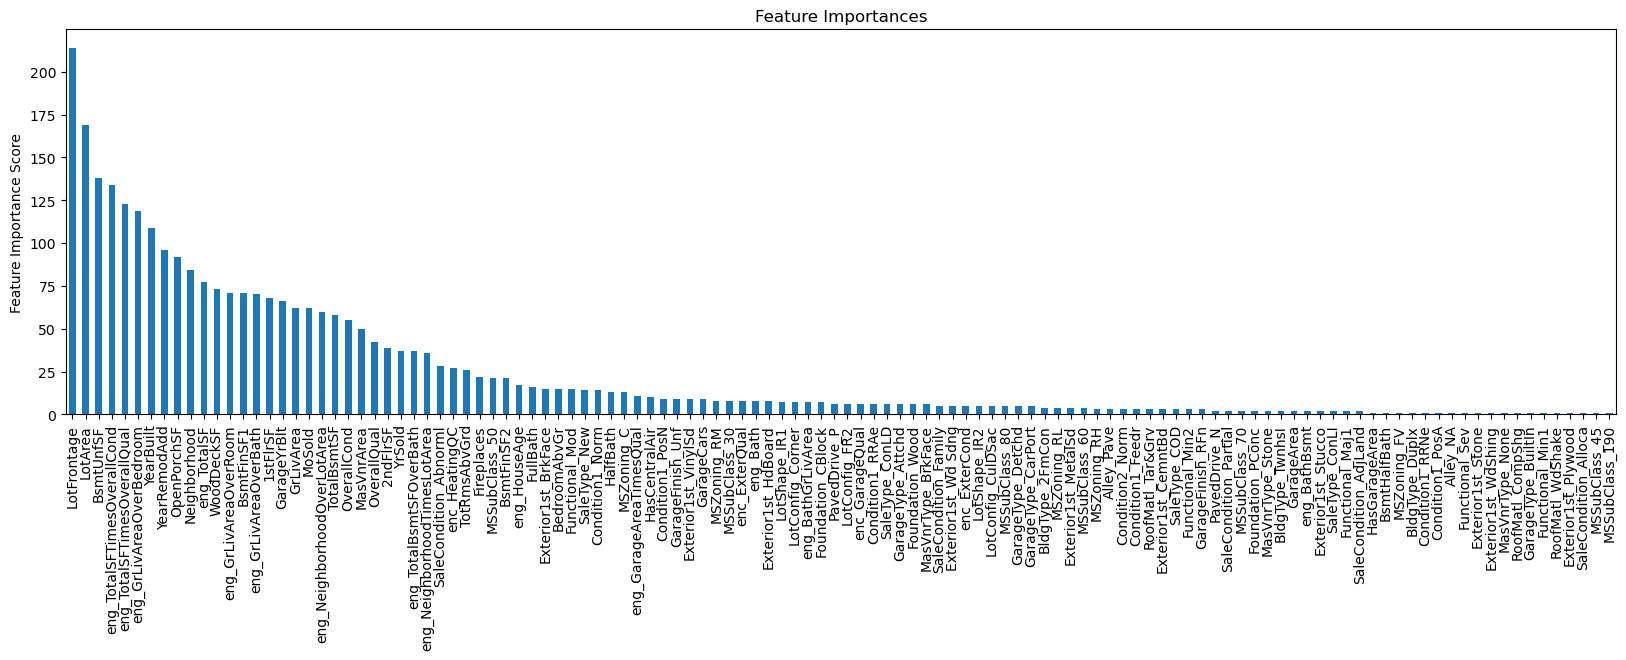

In [425]:
plt.figure(figsize=(20, 5))
plt.ylabel('Feature Importance Score')
best_result["feat_imp"].plot(kind='bar', title='Feature Importances')

## ElasticNet

In [1034]:
def sample_params(rng):
    return {
        #"alpha": 1, # Using full L1 and L2 reg. #rng.choice(np.logspace(-5, -2, 50)),
        "alpha": rng.choice(rng.uniform(0.01, 0.1, 40)),
        "l1_ratio": rng.choice(rng.uniform(0.1, 0.2, 20)),
        "fit_intercept": True,
        "precompute": False,
        "max_iter": 20000,
        "copy_X": True,
        "tol": rng.choice(rng.uniform(0.001, 0.01, 10)),
        "warm_start": False,
        "positive": False,
        "random_state": RANDOM_STATE,
        "selection": "cyclic"
    }
# Best CV: 0.09007543405882802
# Best Params: {'alpha': np.float64(0.0002559547922699536), 'l1_ratio': np.float64(0.9056193149388244), 'fit_intercept': True, 'precompute': False, 
# 'max_iter': 20000, 'copy_X': True, 'tol': np.float64(0.0038736684213411077), 'warm_start': False, 'positive': False, 'random_state': 0, 'selection': 'cyclic'}


def run_elnet(rng, show_iter=False):
    best_score = 1
    best_std = 1
    for i in range(50):
        params = sample_params(rng)

        #X, y, y_orig, X_test, y_test = split_train_test_data()
        X, y, y_orig, _, _ = split_train_test_data()
        X, y = remove_residuals(X, y, model=get_model("Rig"))
        X, ignored_cols, ord_cols_used, desc = initial_processing(X)

        cv = RepeatedKFold(
              n_splits=5,
              #shuffle=True,
              random_state=RANDOM_STATE
            )

        model = ElasticNet(**params)
        pipeline = create_pipeline(bin_cols, bin_cols_spec, ignored_cols, ord_cols_used, log1p_cols, norm_cols, create_eng_features, model=model)
        # Using cross_validate to get estimator data
        result = cross_validate(pipeline, X, y, cv=cv, scoring="neg_root_mean_squared_error", error_score="raise", return_estimator=True)


        scores = result["test_score"] * -1
        #print("scores:", scores)
        #println()
        estimators = result["estimator"]
        if scores.mean() < best_score:
            best_score = scores.mean()
            best_std = scores.std()
            best_params = params
            print("New Best", best_score, f"({best_std})", "\nParams:", best_params)

        if show_iter:
            iter = [it.named_steps["model"].n_iter_ for it in estimators if hasattr(it.named_steps["model"], "n_iter_")]
            print("Iterations:", iter)

    print("Best CV:", best_score, f"({best_std})")
    print("Best Params:", best_params)

run_elnet(np.random.default_rng(RANDOM_STATE))

New Best 0.12024158339118582 (0.006564758570730807) 
Params: {'alpha': np.float64(0.09974889422102899), 'l1_ratio': np.float64(0.18764842308107038), 'fit_intercept': True, 'precompute': False, 'max_iter': 20000, 'copy_X': True, 'tol': np.float64(0.004285991514203457), 'warm_start': False, 'positive': False, 'random_state': 0, 'selection': 'cyclic'}
New Best 0.10850596800749983 (0.005750948466171419) 
Params: {'alpha': np.float64(0.07588055760909047), 'l1_ratio': np.float64(0.12258694284173244), 'fit_intercept': True, 'precompute': False, 'max_iter': 20000, 'copy_X': True, 'tol': np.float64(0.006345317814518515), 'warm_start': False, 'positive': False, 'random_state': 0, 'selection': 'cyclic'}
New Best 0.10640148394090077 (0.005605463396489195) 
Params: {'alpha': np.float64(0.041549933023109935), 'l1_ratio': np.float64(0.19436777652291878), 'fit_intercept': True, 'precompute': False, 'max_iter': 20000, 'copy_X': True, 'tol': np.float64(0.0023680711227028334), 'warm_start': False, 'posit

## Lasso


In [158]:
def sample_params(rng):
    return {
        "alpha": 0.0007187203411199203,
        "fit_intercept": True,
        "precompute": False,
        "max_iter": 20000,
        "copy_X": True,
        "tol": 0.0038968245196834795,
        "warm_start": False,
        "positive": False,
        "random_state": RANDOM_STATE,
        "selection": "cyclic"
    }


def run_lasso(rng, show_iter=False):
    best_score = 1
    for i in range(30):
        params = sample_params(rng)

        X, Y, Y_orig, X_test, Y_test = split_train_test_data()
        X, Y, _, ignored_cols, ord_cols_used, desc = initial_processing(X, Y, Y_orig)

        cv = KFold(
              n_splits=5,
              shuffle=True,
              random_state=RANDOM_STATE
            )

        model = Lasso(**params)
        pipeline = create_pipeline(bin_cols, bin_cols_spec, ignored_cols, ord_cols_used, log1p_cols, norm_cols, create_eng_features, model=model)
        # Using cross_validate to get estimator data
        result = cross_validate(pipeline, X, Y, cv=cv, scoring="neg_root_mean_squared_error", error_score="raise", return_estimator=True)

        scores = result["test_score"] * -1
        print("scores:", scores)
        println()
        estimators = result["estimator"]
        if scores.mean() < best_score:
            best_score = scores.mean()
            best_params = params
            print("New Best", best_score, "Params:", best_params)

        if show_iter:
            iter = [it.named_steps["model"].n_iter_ for it in estimators if hasattr(it.named_steps["model"], "n_iter_")]
            print("Iterations:", iter)

    print("Best CV:", best_score)
    print("Best Params:", best_params)

run_lasso(np.random.default_rng(RANDOM_STATE))

#############
# Best CV: 0.11737016644823724
# Best Params: {'alpha': np.float64(0.0007187203411199203), 'fit_intercept': True, 'precompute': False, 'max_iter': 20000, 'copy_X': True, 'tol': 0.0038968245196834795, 'warm_start': False, 'positive': False, 'random_state': 0, 'selection': 'cyclic'}
# Best 1: CV: 0.11742784047698533
# Best Params: {'alpha': np.float64(0.0009293062039294187), 'fit_intercept': True, 'precompute': False, 'max_iter': 20000, 'copy_X': True, 'tol': 0.0038968245196834795, 'warm_start': False, 'positive': False, 'random_state': 0, 'selection': 'cyclic'}

scores: [0.12253467 0.11214768 0.11168382 0.12826662 0.11221804]
------------------------------
New Best 0.11737016644823724 Params: {'alpha': 0.0007187203411199203, 'fit_intercept': True, 'precompute': False, 'max_iter': 20000, 'copy_X': True, 'tol': 0.0038968245196834795, 'warm_start': False, 'positive': False, 'random_state': 0, 'selection': 'cyclic'}
scores: [0.12253467 0.11214768 0.11168382 0.12826662 0.11221804]
------------------------------
scores: [0.12253467 0.11214768 0.11168382 0.12826662 0.11221804]
------------------------------
scores: [0.12253467 0.11214768 0.11168382 0.12826662 0.11221804]
------------------------------
scores: [0.12253467 0.11214768 0.11168382 0.12826662 0.11221804]
------------------------------
scores: [0.12253467 0.11214768 0.11168382 0.12826662 0.11221804]
------------------------------
scores: [0.12253467 0.11214768 0.11168382 0.12826662 0.11221804]
------------------------------
scores: [0.12253467 0.11214768 0.11168382 0.12826662 0.11221804]
--

## HuberRegressor

In [2445]:
X, y, y_orig, _, _ = split_train_test_data()
X, pip_cfg, desc = initial_processing(X)
pip_tr = create_pipeline(pip_cfg)
X, y = remove_residuals(X, y, pip_tr[0], model=get_model("Rig"))
group_field = "MSZoning"

cv = GroupKFold(
      n_splits=5,
      shuffle=True,
      random_state=RANDOM_STATE
    )
alphas = [1e-4, 1e-3, 0.01, 0.1, 1.0]
alphas = [0.2]
epsilons = [1.1, 1.35, 1.5, 1.75, 2.0]
epsilons = [1.5, 2.0]

model = HuberRegressor()
# Creates pipelines for linear and tree regressors
pipeline = create_pipeline(pip_cfg, linear_model=model)
grid = GridSearchCV(
  pipeline[0],
  {"model__alpha": alphas, "model__epsilon": epsilons, "model__max_iter": [4000], "model__tol": [1e-4] },
  cv=cv,
  scoring="neg_root_mean_squared_error",
  n_jobs=-1
)
grid.fit(X, y, groups=X[group_field])

print("Best alpha:", grid.best_params_)
print("Best CV:", -grid.best_score_)

# 1465 (0.27, 2.5, 3000)
# 1464 (0.3, 2.5, 4000)
# 1443 (0.3, 5.0, 4000)

# Observations
# It seems that this model is not the best for this project. 
# The score improves when epsilon goes up, that means that the model doesn't have a lot of extream values
# degrading the performance of the model. So, when increasing epsilon the model is more similar to a Ridge regression
# which now has a much better performance.

Best alpha: {'model__alpha': 0.2, 'model__epsilon': 2.0, 'model__max_iter': 4000, 'model__tol': 0.0001}
Best CV: 0.14919749355783918


## Stacking

In [1060]:

X, y, y_orig = train_data_for_submission()
#X, Y, Y_orig, X_test, Y_test = split_train_test_data()
X, y = remove_residuals(X, y, model=get_model("Rig"))
X, ignored_cols, ord_cols_used, desc = initial_processing(X)

cv = KFold(
  n_splits=5,
  shuffle=True,
  random_state=RANDOM_STATE
)


rng = np.random.default_rng(RANDOM_STATE)

# LiRe: Linear Regression
# Lasso: Lasso
# ENet: ElasticNet
# Rig: Ridge
# XBReg: XGBRegressor
best_cv_mean = 999
best_std = 999
for i in range(20):
  final_model = Ridge(alpha=rng.choice(rng.uniform(0.8, 1.2, 20)))
  estimators = [
    #('Rig', get_model("Rig")),
    ('LiRe', get_model("LiRe")),
    ('ENet', get_model("ENet")),
    ('XGBReg', get_model("XBReg")),
  ]
  reg = StackingRegressor(
    estimators=estimators,
    #final_estimator=get_model("LiRe"),
    final_estimator=final_model,
  )
  pipeline = create_pipeline(bin_cols, bin_cols_spec, ignored_cols, ord_cols_used, log1p_cols, norm_cols, create_eng_features, model=reg)

  result = cross_val_score(pipeline, X, y, cv=cv, scoring="neg_root_mean_squared_error", error_score="raise")
  cv_mean = np.mean(result) * -1
  if cv_mean < best_cv_mean:
    best_cv_mean = cv_mean
    best_std = np.std(result)
 
    printspace()
    print("New best alpha:", best_cv_mean)
    printspace()
 
printspace()
println()
print("Best CV Mean:", best_cv_mean, f"({best_cv})")
print("Params:", final_model.get_params()) 


###########
# Best 1: CV Mean: 0.11575093095099724 (999)
# Params: {'alpha': np.float64(0.5420550348240253), 'copy_X': True, 'fit_intercept': True, 'max_iter': None, 'positive': False, 'random_state': None, 'solver': 'auto', 'tol': 0.0001}


                              
New best alpha: 0.08634775327270125
                              
                              
New best alpha: 0.08633640182179211
                              
                              
New best alpha: 0.08633487579932607
                              
                              
New best alpha: 0.08633425308961869
                              
                              
New best alpha: 0.08633344106966263
                              
                              
New best alpha: 0.08633325126836326
                              
                              
------------------------------
Best CV Mean: 0.08633325126836326 (999)
Params: {'alpha': np.float64(0.8019597659954303), 'copy_X': True, 'fit_intercept': True, 'max_iter': None, 'positive': False, 'random_state': None, 'solver': 'auto', 'tol': 0.0001}


# Analysis

### CV strategy

In [1842]:
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.base import clone

X, y, y_orig, X_test, y_test = split_train_test_data()
X, ignored_cols, ord_cols_used, desc = initial_processing(X)
X, y = remove_residuals(X, y, model=get_model("Rig"))

categorical_cols = ["Neighborhood", "MSSubClass", "MSZoning", "OverallQual", "OverallCond"]
categorical_cols = ["MSZoning"]

results = {}
for col in categorical_cols:
  groups = X[col]
  cv = GroupKFold(n_splits=5)
  pip = create_pipeline(bin_cols, bin_cols_spec, ignored_cols, ord_cols_used, \
                        log1p_cols, norm_cols, create_eng_features, get_model("Stk1"))
  score = cross_val_score(pip, X, y, cv=cv,
                          groups=groups,
                          scoring='neg_root_mean_squared_error')
  results[col] = (-score.mean(), score.std())

# The group whose CV score is CLOSEST to production RMSE
# is likely the real partition
# print("results:", results)
# print("results:", results.items())
prod_cv = 0.12403 # Kaggle
random_cv = 0.0988 # Aprox
ranked = sorted(results.items(), key=lambda x: abs(x[1][0] - prod_cv))
for k, r in ranked:
  print(k, "CV Mean:", nfmt(r[0]), "CV Std:", nfmt(r[1]), 
        "Prod RMSE diff:", nfmt(abs(r[0] - prod_cv)),
        "Random CV diff:",  nfmt(abs(r[0] - random_cv)))

# Observations
# MSZoning looks like a good candidate to group by. Let's check cardinal info below
# Also OverallCond has a high CV. Let's try that after

# Initial results without:
# MSZoning CV Mean: 0.1190 CV Std: 0.0316 Prod RMSE diff: 0.0051 Random CV diff: 0.0202
# OverallCond CV Mean: 0.1040 CV Std: 0.0214 Prod RMSE diff: 0.0200 Random CV diff: 0.0052
# Neighborhood CV Mean: 0.0989 CV Std: 0.0098 Prod RMSE diff: 0.0251 Random CV diff: 0.0001
# MSSubClass CV Mean: 0.0954 CV Std: 0.0138 Prod RMSE diff: 0.0286 Random CV diff: 0.0034
# OverallQual CV Mean: 0.0953 CV Std: 0.0156 Prod RMSE diff: 0.0287 Random CV diff: 0.0035

# Testing OverallCond replacing 1->3, 2->3 and 9->5 based in mann - whitney result =>  score goes up again
# Testing OverallCond replacing 1->3, 2->3 based in mann - whitney result =>  score doesn't improve 
# Testing OverallCond using target encoding makes performance worse

shape bef (1135, 80)
shape aft (1131, 80)


ValueError: Cannot have number of splits n_splits=5 greater than the number of groups: 4.

In [1702]:
print_cardinal_info(X, y, "MSZoning")

# Observations
# There are 8 possible values for this field: A, C, FV, I, RH, RL, RP, RM. 
# We only have 5 in training set, and one two of them have a few rows. Maybe we have something here.
# Let's compare with test distribution below

Feature: MSZoning
------------------------------
val: FV (4.41%) - target mean: 12.2587 std: 0.2358 count: 50
val: RL (78.77%) - target mean: 12.0829 std: 0.3588 count: 894
val: RM (15.51%) - target mean: 11.7089 std: 0.2953 count: 176
val: RH (0.88%) - target mean: 11.6174 std: 0.2709 count: 10
val: C (0.44%) - target mean: 11.4741 std: 0.2612 count: 5
                              
Value count: 5
Total count: 1135


In [4]:
list(ORD_COLS)

['LandSlope',
 'ExterQual',
 'ExterCond',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'HeatingQC',
 'KitchenQual',
 'FireplaceQu',
 'GarageQual',
 'GarageCond',
 'PoolQC',
 'Fence']

In [1685]:
list_models()

LiRe: Linear Regression
Lasso: Lasso
ENet: ElasticNet
Rig: Ridge
XBReg: XGBRegressor
Stk1: Stack1
Stk2: Stack2


## Normalization and LogP1

Filling LotFrontage nulls with mean by Neighborhood
Filling LotFrontage nulls with mean by Neighborhood


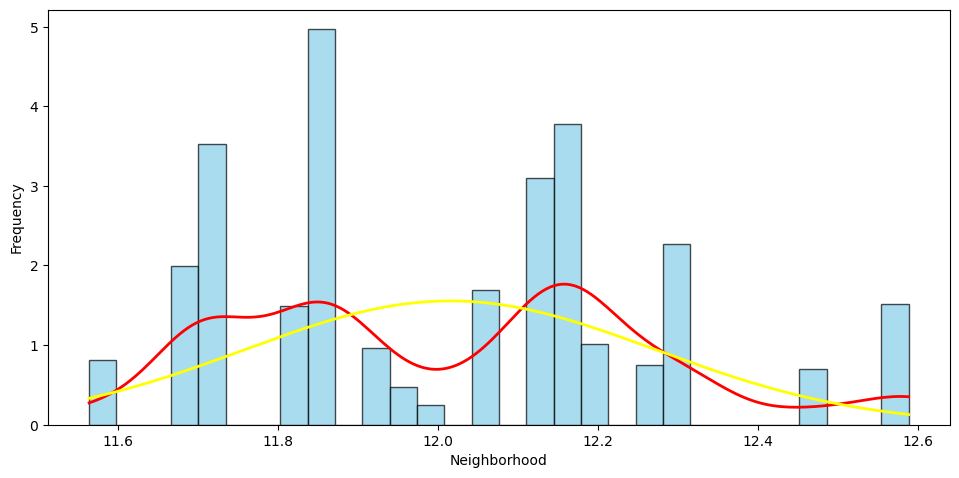

In [275]:
X, Y, Y_orig, X_test, Y_test = split_train_test_data()
X, Y, _, ignored_cols, ord_cols_used, desc = initial_processing(X, Y, Y_orig)

dcols = ["Neighborhood", "eng_TotalSF", "eng_TotalSFTimesOverallQual", "eng_TotalSFTimesOverallCond", "eng_GarageAreaTimesQual", "eng_HouseAge",
            "eng_BathGrLivArea", "eng_BathBsmt", "eng_Bath", "eng_GrLivAreaOverRoom", "eng_GrLivAreaOverBedroom",
            "eng_GrLivAreaOverBath", "eng_TotalBsmtSFOverBath", "eng_GarageAreaOverCar", "eng_NeighborhoodOverLotArea", "eng_NeighborhoodTimesLotArea"]

dlcols = ["sqrt_TotalSF", "sqrt_TotalSFXOverallQual", "sqrt_TotalSFXOverallCond", "log1p_HouseAge", "sqrt_GrLivAreaOverRoom", "sqrt_GrLivAreaOverBath", "log1p_NeighborhoodTimesLotArea", "log1p_NeighborhoodOverLotArea"]

Xt = create_pipeline(bin_cols, bin_cols_spec, ignored_cols, ord_cols_used, log1p_cols, norm_cols, create_eng_features).fit(X, Y).transform(X)
Xt["sqrt_TotalSF"] = np.sqrt(Xt["eng_TotalSF"])
Xt["sqrt_TotalSFXOverallQual"] = np.sqrt(Xt["eng_TotalSFTimesOverallQual"])
Xt["sqrt_TotalSFXOverallCond"] = np.sqrt(Xt["eng_TotalSFTimesOverallCond"])

Xt["log1p_HouseAge"] = np.log1p(Xt["eng_HouseAge"])
Xt["sqrt_GrLivAreaOverRoom"] = np.sqrt(Xt["eng_GrLivAreaOverRoom"])
Xt["sqrt_GrLivAreaOverBath"] = np.sqrt(Xt["eng_GrLivAreaOverBath"])

Xt["log1p_NeighborhoodTimesLotArea"] = np.log1p(Xt["eng_NeighborhoodTimesLotArea"])
Xt["log1p_NeighborhoodOverLotArea"] = np.log1p(Xt["eng_NeighborhoodOverLotArea"])

eng_log1p_cols = "log1p_HouseAge", "log1p_NeighborhoodTimesLotArea", "log1p_NeighborhoodOverLotArea"
eng_sqrt_cols = ["sqrt_TotalSF", "sqrt_TotalSFXOverallQual", "sqrt_TotalSFXOverallCond", "sqrt_GrLivAreaOverRoom", "sqrt_GrLivAreaOverBath"]

show_distribution(Xt, ["Neighborhood"])
# show_distribution(Xt, dcols)
#show_distribution(Xt, dlcols)

# Observations
# - Applying log1p to TotalSF, TotalSFTimesOverallQual, sqrt_TotalSFXOverallCond, sqrt_GrLivAreaOverRoom:
#   ===> makes the distribution left skewed. Don't do. => Sqrt instead, makes the distribution closer to normal
# - House Age is right skewed and multimodal. Log1p works fine, but maybe trying creating two or three cats: old, med, new
# - s


## Residuals (Stack1)

In [358]:
# X, y, y_orig = train_data_for_submission()

# X, pip_config, desc = initial_processing(X, y, y_orig)

# dfres = study_residuals(X, y, model=get_model("Rig"))


# print(dfres.groupby("bin")["abs_res"].mean())
# #print(df_res.groupby("bin")["abs_res"].mean())

# dfres.head()

In [521]:
def get_residuals_by_group(X, y, pip, group_col, random_state=RANDOM_STATE, n_splits=5):
  if  isinstance(random_state, int):
    random_state = [random_state]

    rng = np.random.default_rng(random_state)
    # Shuffle the data
    shuffled_indices = rng.permutation(X.index)
    X = X.loc[shuffled_indices].reset_index(drop=True)
    y = y.loc[shuffled_indices].reset_index(drop=True)

  dfs = []
  for seed in random_state:
    oof_preds = np.zeros(len(df))
    gkf = GroupKFold(n_splits=n_splits, random_state=seed, shuffle=True)

    for train_idx, val_idx in gkf.split(X, y, groups=df[group_col]):
      pip.fit(X.iloc[train_idx], y.iloc[train_idx])
      oof_preds[val_idx] = pip.predict(X.iloc[val_idx])

    dfs.append(
      pd.DataFrame({
        group_col: X[group_col],
        "y": y,
        "pred": oof_preds,
        "residual": y - oof_preds
      }, index=X.index)
    )
    print(f"Residuals for seed {seed} generated")
  return dfs

# Get all data to study residuals
X, y, y_orig = train_data_for_submission()

# Get the config tu create the pipeline
X, pip_config, desc = initial_processing(X)
# Create the transformation pipeline tuple. 0 for linear, 1 for tree models.
trans_pips = create_pipeline(pip_config)
# Create the full pipeline for stack model
#pip = build_full_pipeline(trans_pips, "Stk1")
pip = create_stack_1(trans_pips)

# Get residuals using out of folds
r_s = [x + RANDOM_STATE for x in [0, 10, 15, 42, 80]] # Checking with different random state to see if category "C" bias is stable
df_residual_summ = get_residuals_by_group(X, y, pip, group_col="MSZoning", random_state=r_s)

df_residual_summ[0].head(5)







Residuals for seed 0 generated
Residuals for seed 10 generated
Residuals for seed 15 generated
Residuals for seed 42 generated
Residuals for seed 80 generated


,MSZoning,y,pred,residual
0,RL,12.247699,12.180358,0.067341
1,RL,12.109016,11.967642,0.141375
2,RL,12.317171,12.299716,0.017455
3,RL,11.849405,11.900305,-0.050900
4,RL,12.429220,12.515700,-0.086480


In [506]:
for df_res in df_residual_summ:
  print(df_res.groupby("MSZoning")["residual"].mean())

#df_residual_summ.groupby("MSZoning")["residual"].mean()
# It seems that the bias for cat "C" is more or less stable. Let's try adding the binary col and applying a correction.

# Previous applying binary  STK1, var= -0.379443, -0.448501, -0.378335, -0.379443, -0.374842

MSZoning
C    -0.366419
FV    0.168331
RH    0.006076
RL    0.113237
RM    0.093759
Name: residual, dtype: float64
MSZoning
C    -0.432872
FV    0.111795
RH    0.184891
RL    0.103782
RM   -0.078234
Name: residual, dtype: float64
MSZoning
C    -0.366537
FV    0.170375
RH    0.184891
RL    0.103782
RM    0.105097
Name: residual, dtype: float64
MSZoning
C    -0.366419
FV    0.170375
RH    0.006076
RL    0.075338
RM    0.105097
Name: residual, dtype: float64
MSZoning
C    -0.365877
FV    0.010418
RH    0.184891
RL    0.103782
RM    0.093759
Name: residual, dtype: float64


#### Computing MSZoning Bias Fix (C)

In [541]:
def shrunk_bias(group_bias, group_size, global_bias, smoothing=10):
    """
    Pulls the group bias toward the global bias when sample size is small.

    smoothing: controls how much you trust the group vs global.
               Higher = more shrinkage toward global.
               At group_size << smoothing → result ≈ global_bias
               At group_size >> smoothing → result ≈ group_bias
    """
    weight = group_size / (group_size + smoothing)
    print("Shrunk weight:", weight)
    return weight * group_bias + (1 - weight) * global_bias

c_cat_rows = X[X["MSZoning"] == "C"].index
print("MSZoning 'C' rows:", c_cat_rows.shape[0])

smoothing = 40
by_seed_bias_mean = 0
by_seed_bias_mean_global = 0
for df_res in df_residual_summ:
  by_seed_bias_mean += df_res[df_res["MSZoning"] == "C"]["residual"].mean()
  by_seed_bias_mean_global += df_res["residual"].mean()

by_seed_bias_mean /= len(df_residual_summ)
by_seed_bias_mean_global /= len(df_residual_summ)
print("Smoothing factor:", smoothing)
print("By seed C residual mean:", by_seed_bias_mean)
print("By seed global residual mean:", by_seed_bias_mean_global)
msz_bias_fix = shrunk_bias(by_seed_bias_mean, c_cat_rows.shape[0], by_seed_bias_mean_global, smoothing=smoothing)
print("MSZoning (Category C) bias fix:", msz_bias_fix)


# Previous applying binary  STK1, var= -0.379443, -0.448501, -0.378335, -0.379443, -0.374842




MSZoning 'C' rows: 5
Smoothing factor: 40
By seed C residual mean: -0.3665367107665295
By seed global residual mean: 0.07701953737563588
Shrunk weight: 0.1111111111111111
MSZoning (Category C) bias fix: 0.027735509804284172


In [519]:
# Testing the Bias Fix
print("Testing bias fix:", msz_bias_fix)
msz_rmse = 0
msz_rmse_fixed = 0
f_dfs = []
for df_res in df_residual_summ:
  n = df_res.shape[0]
  msz_rmse = np.sqrt(np.mean(df_res["residual"] ** 2))
  df_fixed = df_res.copy()
  df_fixed["f_pred"] = df_fixed["pred"]
  df_fixed.loc[df_fixed["MSZoning"] == "C", "f_pred"] += msz_bias_fix
  df_fixed["f_residual"] = df_fixed["y"] - df_fixed["f_pred"]
  msz_rmse_fixed = np.sqrt(np.mean(df_fixed["f_residual"] ** 2))
  f_dfs.append(df_fixed)
  println()
  print("MSZ RMSE:", msz_rmse)
  print("MSZ FIXED RMSE:", msz_rmse_fixed)

df_fixed = f_dfs[0]
df_fixed[df_fixed["MSZoning"] == "C"]
  

Testing bias fix: -0.22221418555002978
------------------------------
MSZ RMSE: 0.17476417507621012
MSZ FIXED RMSE: 0.17252015683512942
------------------------------
MSZ RMSE: 0.18488857668692465
MSZ FIXED RMSE: 0.18221315514865508
------------------------------
MSZ RMSE: 0.18803894053725784
MSZ FIXED RMSE: 0.18595421927887043
------------------------------
MSZ RMSE: 0.1573930307032302
MSZ FIXED RMSE: 0.1548975588519632
------------------------------
MSZ RMSE: 0.18378956577324934
MSZ FIXED RMSE: 0.1816616260255306


,MSZoning,y,pred,residual,f_pred,f_residual
30,C,10.596660,11.515623,-0.918963,11.293409,-0.696749
88,C,11.350418,11.181550,0.168868,10.959336,0.391082
93,C,11.804856,12.111434,-0.306578,11.889220,-0.084364
495,C,10.460271,11.264559,-0.804289,11.042345,-0.582074
557,C,11.589896,11.692597,-0.102701,11.470383,0.119513
711,C,11.540317,11.526332,0.013984,11.304118,0.236199
812,C,10.933000,11.549719,-0.616719,11.327505,-0.394505
916,C,10.471978,11.041785,-0.569807,10.819571,-0.347593
1061,C,11.302217,11.559526,-0.257310,11.337312,-0.035095
1279,C,11.133143,11.403819,-0.270676,11.181605,-0.048462


In [374]:
print_cardinal_info(X, y, "MSZoning")

X[X["MSZoning"] == "C"].join(y)[["MSZoning", LOGP_TARGET_COL]].describe()

# Observations
# Category C is the problematic value. It has the mayor residual mean and a big std. Also, it has a few values in train set.
# We can try adding a binary feature for this category to increase signal and also apply a bias correction if the bias is stable.



Feature: MSZoning
------------------------------
val: FV (4.46%) - target mean: 12.2466 std: 0.2311 coef.var: 1.8872 count: 65
val: RL (78.78%) - target mean: 12.0834 std: 0.3728 coef.var: 3.0853 count: 1147
val: RH (1.10%) - target mean: 11.7498 std: 0.2892 coef.var: 2.4612 count: 16
val: RM (14.97%) - target mean: 11.6929 std: 0.3156 coef.var: 2.6991 count: 218
val: C (0.69%) - target mean: 11.1183 std: 0.4850 coef.var: 4.3621 count: 10
                              
Value count: 5
Total count: 1456


,SalePrice_log1p
count,10.000000
mean,11.118275
std,0.484993
min,10.460271
25%,10.680745
50%,11.217680
75%,11.492842
max,11.804856


In [320]:
bigres = df_res[df_res["residual"].abs() > 0.2].sort_values(by="residual", ascending=False)
bigres_idx = bigres.index

print("Mayor residuals shape:", bigres.shape)

df_base_data.iloc[bigres_idx].sort_values(by="YearBuilt", ascending=True)

# Observations
# All of this values corresponds to old houses.
# Let's remove this values and see what happen
# Train distribution for YearBuilt is similar than kaggle test data

Mayor residuals shape: (26, 5)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,SalePrice_log1p
716,717,70,RM,60.0,10800,Pave,Grvl,Reg,Bnk,AllPub,Inside,Gtl,OldTown,Norm,Norm,1Fam,2Story,7,8,1890,1998,Gable,CompShg,Wd Sdng,VinylSd,NaN,0.0,TA,Gd,BrkTil,TA,TA,No,Unf,0,Unf,0,718,718,GasA,Ex,Y,SBrkr,1576,978,0,2554,0,0,1,1,3,1,TA,8,Typ,0,NaN,Detchd,1996.0,Unf,2,704,TA,TA,P,0,48,143,0,0,0,NaN,NaN,NaN,0,7,2007,WD,Normal,159500,11.979805
88,89,50,C,105.0,8470,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,IDOTRR,Feedr,Feedr,1Fam,1.5Fin,3,2,1915,1982,Hip,CompShg,Plywood,Plywood,NaN,0.0,Fa,Fa,CBlock,TA,Fa,No,Unf,0,Unf,0,1013,1013,GasA,TA,N,SBrkr,1013,0,513,1526,0,0,1,0,2,1,Fa,6,Typ,0,NaN,NaN,NaN,NaN,0,0,NaN,NaN,N,0,0,156,0,0,0,NaN,MnPrv,NaN,0,10,2009,ConLD,Abnorml,85000,11.350418
495,496,30,C,60.0,7879,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,IDOTRR,Norm,Norm,1Fam,1Story,4,5,1920,1950,Gable,CompShg,Wd Sdng,Wd Sdng,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,495,Unf,0,225,720,GasA,TA,N,FuseA,720,0,0,720,0,0,1,0,2,1,TA,4,Typ,0,NaN,NaN,NaN,NaN,0,0,NaN,NaN,N,0,523,115,0,0,0,NaN,GdWo,NaN,0,11,2009,WD,Abnorml,34900,10.460271
30,31,70,C,50.0,8500,Pave,Pave,Reg,Lvl,AllPub,Inside,Gtl,IDOTRR,Feedr,Norm,1Fam,2Story,4,4,1920,1950,Gambrel,CompShg,BrkFace,BrkFace,NaN,0.0,TA,Fa,BrkTil,TA,TA,No,Unf,0,Unf,0,649,649,GasA,TA,N,SBrkr,649,668,0,1317,0,0,1,0,3,1,TA,6,Typ,0,NaN,Detchd,1920.0,Unf,1,250,TA,Fa,N,0,54,172,0,0,0,NaN,MnPrv,NaN,0,7,2008,WD,Normal,40000,10.596660
1328,1329,50,RM,60.0,10440,Pave,Grvl,Reg,Lvl,AllPub,Corner,Gtl,OldTown,Norm,Norm,1Fam,1.5Fin,6,7,1920,1950,Gable,CompShg,BrkFace,Wd Sdng,NaN,0.0,Gd,Gd,BrkTil,Gd,TA,No,LwQ,493,Unf,0,1017,1510,GasW,Ex,Y,SBrkr,1584,1208,0,2792,0,0,2,0,5,1,TA,8,Mod,2,TA,Detchd,1920.0,Unf,2,520,Fa,TA,Y,0,547,0,0,480,0,NaN,MnPrv,Shed,1150,6,2008,WD,Normal,256000,12.452937
217,218,70,RM,57.0,9906,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,OldTown,Norm,Norm,1Fam,2Story,4,4,1925,1950,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Unf,0,Unf,0,686,686,GasA,Fa,N,SBrkr,810,518,0,1328,0,0,1,0,3,1,TA,8,Typ,0,NaN,Detchd,1940.0,Unf,1,210,TA,TA,Y,0,172,60,0,0,0,NaN,NaN,NaN,0,9,2006,WD,Family,107000,11.580593
608,609,70,RL,78.0,12168,Pave,NaN,Reg,HLS,AllPub,Inside,Mod,Crawfor,Norm,Norm,1Fam,2Story,8,6,1934,1998,Gable,CompShg,BrkFace,Wd Sdng,NaN,0.0,TA,TA,PConc,Gd,TA,Mn,BLQ,428,Unf,0,537,965,GasA,TA,Y,SBrkr,1940,1254,0,3194,0,0,2,1,4,1,TA,10,Typ,2,Gd,Basment,1934.0,Unf,2,380,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,9,2007,WD,Alloca,359100,12.791359
1147,1148,70,RL,75.0,12000,Pave,NaN,Reg,Bnk,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,7,1941,1950,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,275,Unf,0,429,704,GasA,Ex,Y,SBrkr,860,704,0,1564,0,0,1,1,3,1,Fa,7,Typ,1,Gd,Attchd,1941.0,Unf,1,234,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,7,2009,WD,Normal,174500,12.069686
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,9,1941,2006,Gable,CompShg,CemntBd,CemntBd,NaN,0.0,Ex,Gd,Stone,TA,Gd,No,GLQ,275,Unf,0,877,1152,GasA,Ex,Y,SBrkr,1188,1152,0,2340,0,0,2,0,4,1,Gd,9,Typ,2,Gd,Attchd,1941.0,RFn,1,252,TA,TA,Y,0,60,0,0,0,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500,12.493133
1427,1428,50,RL,60.0,10930,Pave,Grvl,Reg,Bnk,AllPub,Inside,Gtl,NAmes,Artery,No

Removed rows: 26 ( 2.2375 %)


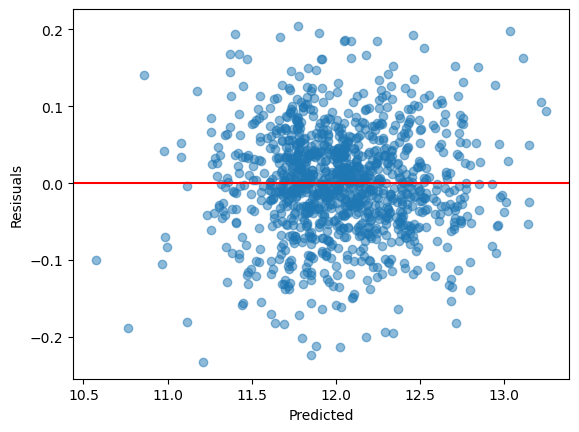

bin
(10.571, 11.738]    0.061198
(11.738, 11.905]    0.050018
(11.905, 12.092]    0.046844
(12.092, 12.333]    0.050022
(12.333, 13.252]    0.055764
Name: abs_res, dtype: float64
bin
(10.48, 11.73]      0.073239
(11.73, 11.896]     0.054386
(11.896, 12.09]     0.052457
(12.09, 12.335]     0.052323
(12.335, 13.238]    0.058619
Name: abs_res, dtype: float64


In [326]:
X, y, y_orig, X_test, y_test = split_train_test_data()
X, y, _, ignored_cols, ord_cols_used, desc = initial_processing(X, y, y_orig)

# Removing residuals > 0.2 an see what happen.
nrows_b = X.shape[0]
X = X[~X.index.isin(bigres_idx)]
y = y[~y.index.isin(bigres_idx)]

print("Removed rows:", nrows_b - X.shape[0], "(", nfmt((nrows_b - X.shape[0]) / nrows_b * 100), "%)")

dfres_rem = study_residuals(X, y)


print(dfres_rem.groupby("bin")["abs_res"].mean())
print(df_res.groupby("bin")["abs_res"].mean())


In [323]:
#df_submit = pd.read_csv("./data/test.csv")

print(df_submit.shape)
df_submit[df_submit["YearBuilt"] < 2007].sort_values(by="YearBuilt", ascending=True).shape
df_submit["YearBuilt"].describe()

(1459, 80)


count    1459.000000
mean     1971.357779
std        30.390071
min      1879.000000
25%      1953.000000
50%      1973.000000
75%      2001.000000
max      2010.000000
Name: YearBuilt, dtype: float64

In [51]:
# ['1stFlrSF', 'Fireplaces', 'FullBath', 'GarageArea', 'GarageCars', 'GarageYrBlt', 'GrLivArea', 'OverallQual', 
# 'TotRmsAbvGrd', 'TotalBsmtSF', 'YearBuilt', 'YearRemodAdd', 'MSSubClass']

# Notes from EDA
# There are some outliers in 1stFlrSF, BuiltSF, GarageArea, GrLiveArea, TotalBsmtSF
# Fireplaces. 3 is not a common value. Test making it 2.
# What does fullbath == 0 means? Seems wrong value. Check.
# A lot of 0 in Fireplaces, FullBath, GarageArea, GarageCars, YearRemodAdd, TotalBsmtSF
# YearBuilt and YearRemodAdd are kind of noicy. 
# MSSubClass seems to have some signal. Check ANoVA. There are some very low values (out of trend) for some categories.
# Observations
# 1stFlrSF is heavy right skewed. Need to check outliers. Also it seems to have the same information than GrLivArea. Check removing or fixing the right skeew using log1p
# 2ndFlrSF is right skewed and it has a lot of 0. Suppose corresponds to houses not having 2nd floor. Maybe create a Has2ndFloor feature? Also check outliers.
# 3ssnPorch seems to be a constant  col. Check removal. If not, Has3SsnPorch?
# Same for EnclosedPorch
# GarageCars and GarageArea should provide the similar information. Try removing or using some combination. There are also several values = 0. Complement with field HasGarage 1/0
# There are a few samples having 3 bathrooms. Check if the related price. Consider creating a Has3Baths feature, or clipping value to 2.
# HalfBath mostly 0-1. Consider HasHalfBath
# Check 0 values in BedroomAbvGr
# BsmtFinSF1 has a lot of 0. Add HasBsmt 1/0. 
# BsmtFinSF2 Almost constant. Check
# BsmtHalfBath almost constant.
# Compare garage built with house built year. Check if has any signal.
# FullBath, a very few values > 2. Check signal. Consider adding HasFullBath
# KitchenAbvGr, a few values above 1. Almost constant, check signal.
# LotArea has 0 values? If yes, fix. Not possible data
# LowQualFinSF is almost constant. Check removal

def plot_grouped_mean(col):
  X, Y, Y_orig,  X_test, Y_test = split_train_test_data()
  df_eng =  X.copy().join(Y_orig)
  df_eng = df_eng.groupby(col).agg({
      #TARGET_COL: "mean",
      TARGET_COL: "count",
      #TARGET_COL: "mean",
  }).sort_values(by=TARGET_COL, ascending=False)
  #df_eng.plot(kind="bar")
  print(df_eng)

#plot_grouped_mean("Fireplaces")
#f_regression(X[["MSSubClass"]], Y, center=True)
#print_cardinal_info(X, Y, "3SsnPorch")


X, Y, Y_orig,  X_test, Y_test = split_train_test_data()
zero_cols = ["Fireplaces", "GarageArea", "GarageCars", "YearRemodAdd", "TotalBsmtSF", "2ndFlrSF", "EnclosedPorch", "BsmtFinSF2"]

cons_cols = ["3SsnPorch", "2ndFlrSF", "EnclosedPorch", "BsmtFinSF2"]
#for c in (zero_cols + cons_cols):
for c in ["HalfBath"]:
  #print_cardinal_info(X, Y, c)
  row_count = X.shape[0]
  unique_count = X[c].unique().shape[0]
  zero_count = X[X[c] == 0][c].shape[0]
  print(c, unique_count, "diff values")
  print(c, zero_count, "rows with 0 (", nfmt(zero_count / row_count * 100), "%)")
  new_col = f"Has{c}"
  X[new_col] = X[c].apply(lambda x: 0 if x == 0 else 1)
  print_cardinal_info(X, Y, new_col)
  printspace()

# Convert the fields in the column below in a list
# Fireplaces, FullBath, GarageArea, GarageCars, YearRemodAdd, TotalBsmtSF


X["HalfBath"].value_counts()

X.columns


NameError: name 'g_X' is not defined

## Features importance 

Let's analyze feature importance for all the weak models and remove not important features for them. Also, analyze if OHE encoding is right for some features, Because in previous analysis only one category value (its column) has a importance != 0 in XGBRegressor.

In [2013]:
def feat_importance_in_stack(estimators, feature_names):
  f_importances = []
  for fold_id, pip in enumerate(estimators):
    stack = pip.named_steps["model"]
    for est_id, inner_est in enumerate(stack.estimators_):
      model = inner_est
      est_name = type(model).__name__
      if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
      elif hasattr(model, "coef_"):
        coef = model.coef_
        importances = np.abs(coef).mean(axis=0) if coef.ndim > 1 else np.abs(coef)
      else:
        raise ValueError(f"Model '{est_name}' has neither 'feature_importances_' nor 'coef_'.")

      row = {"fold_id": fold_id, "estimator_name": est_name}
      row.update(dict(zip(feature_names, importances)))
      f_importances.append(row)

  df_importances = pd.DataFrame(f_importances)

  # ── Build wide summary: one (imp, std, cv) triplet per model ──────────
  df_summary = pd.DataFrame({"feature": feature_names})

  for est_name, group in df_importances.groupby("estimator_name"):
    feat_vals = group[feature_names]
    mean_imp = feat_vals.mean()
    std_imp  = feat_vals.std(ddof=1).fillna(0)
    cv       = np.where(mean_imp == 0, 0, std_imp / mean_imp.abs() * 100)

    df_block = pd.DataFrame({
      f"imp_{est_name}":     mean_imp.values,
      f"std_{est_name}":     std_imp.values,
      f"coef_var_{est_name}": cv,
    })
    df_summary = pd.concat([df_summary, df_block], axis=1)

  #summary = summary.set_index("feature")

  return df_importances, df_summary


In [2015]:
X, y, y_orig, X_test, y_test = split_train_test_data()
X, ignored_cols, ord_cols_used, desc = initial_processing(X)
X, y = remove_residuals(X, y, model=get_model("Rig"))

col = "MSZoning"

results = {}
groups = X[col]
cv = GroupKFold(n_splits=5)
pip = create_pipeline(bin_cols, bin_cols_spec, ignored_cols, ord_cols_used, \
                      log1p_cols, norm_cols, create_eng_features, get_model("Stk1"))
Xt = pip[:-2].fit(X, y).transform(X)
scores = cross_validate(pip, X, y, cv=cv, groups=groups, scoring='neg_root_mean_squared_error', return_estimator=True)
df_imp, df_summ = feat_importance_in_stack(scores.copy()["estimator"], Xt.columns.tolist())

df_summ


,feature,imp_ElasticNet,std_ElasticNet,coef_var_ElasticNet,imp_LinearRegression,std_LinearRegression,coef_var_LinearRegression,imp_XGBRegressor,std_XGBRegressor,coef_var_XGBRegressor
0,LotFrontage,0.001138,0.001558,136.938418,2.032303e-02,1.879414e-02,92.477059,0.002997,0.001524,50.855673
1,LotArea,0.034710,0.008552,24.638753,1.002253e+01,1.119898e+00,11.173810,0.004635,0.000744,16.050330
2,OverallQual,0.000000,0.000000,0.000000,3.922105e-02,4.943301e-03,12.603693,0.061102,0.018840,30.833676
3,OverallCond,0.000000,0.000000,0.000000,5.481176e-02,1.389890e-02,25.357508,0.007018,0.000554,7.887713
4,YearBuilt,0.054529,0.019907,36.508298,5.793963e-02,8.881964e-02,153.296867,0.018306,0.003588,19.598344
5,YearRemodAdd,0.009307,0.003625,38.945818,6.139034e-03,7.733508e-03,125.972712,0.005552,0.001578,28.419762
6,MasVnrArea,0.005449,0.003143,57.674030,1.093139e-02,2.554984e-03,23.372907,0.003453,0.002759,79.896072
7,BsmtFinSF1,0.009005,0.003632,40.333556,1.423512e-02,1.959339e-02,137.641154,0.005369,0.000958,17.850433
8,BsmtFinSF2,0.002837,0.001731,61.010819,1.473895e-03,4.598090e-04,31.196870,0.001019,0.000189,18.506375
9,BsmtUnfSF,0.030345,0.016447,54.201395,3.847384e-02,8.709230e-03,22.636761,0.002152,0.000089,4.115588


In [2020]:
df_sum1 = df_summ.copy()
#df_sum1 = df_sum1[df_sum1["imp_XGBRegressor"] == 0]
df_sum1 = df_sum1[df_sum1["imp_LinearRegression"] == 0]
#df_sum1 = df_sum1[df_sum1["imp_ElasticNet"] == 0]
df_sum1

,feature,imp_ElasticNet,std_ElasticNet,coef_var_ElasticNet,imp_LinearRegression,std_LinearRegression,coef_var_LinearRegression,imp_XGBRegressor,std_XGBRegressor,coef_var_XGBRegressor
203,MSSubClass_40,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
208,MSSubClass_75,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
213,MSSubClass_150,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
215,MSSubClass_180,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Stats

In [ ]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

g_df_scores.loc[g_df_scores["failed"].isnull()] 
#show_global_scores()
#plot_scores()
#show_scores_stats()
#g_df_scores[g_df_scores["model"] == "XBReg"]
g_df_scores[["run_id", "model", "run_label", "CV_MEAN", "DESC"]].sort_values(by="CV_MEAN", ascending=True)
#g_df_scores[["run_id", "failed", "model", "run_label", "CV_MEAN", "DESC"]].sort_values(by="run_id", ascending=False)

# g_df_scores[g_df_scores["failed"] == False].groupby("run_id").agg({
#     "CV_MEAN": "mean",
#     "TRN_RMSE": "mean",
# }).sort_values(by="CV_MEAN", ascending=True)


# myscore = g_df_scores[g_df_scores["failed"] == False][["run_id", "model", "run_label", "CV_MEAN", "DESC", "date", "failed"]].sort_values(by="CV_MEAN", ascending=True)
# myscore[(myscore["run_id"] < 33) & (myscore["run_id"] > 9) & (myscore["model"] == "Rig")].head(30)
# pattern = r"col\s+'([^']+)'"

# Extracting column names from the DESC field ordered by score asc
# matches = myscore["DESC"].str.extractall(pattern)[0].unique().tolist()
# print(matches)
#show(g_df_scores)
#g_df_scores.
# c = ["Neighborhood", "MSZoning", "Functional", "CentralAir", "SaleCondition"]
# c1 = ["Condition2", "Street", "Exterior1st", "GarageType"]

#"BsmtFinSF2", "

#g_df_scores[g_df_scores["run_id"] > 135][["run_id", "model", "CV_MEAN", "validation_tag"]].sort_values(by="run_id", ascending=False)
g_df_scores.loc[g_df_scores["run_id"] == 139, "validation_tag"] = "cross_val_score"
# g_df_scores["validation_tag"]

# Removing Stats

In [861]:
g_df_scores[g_df_scores["run_id"] > 96].sort_values(by="run_id", ascending=False)

# for i in range(98, 105):
#   mark_failed_score(i)
#mark_failed_score(74)

,run_id,date,model,run_label,TRN_RMSE,TRN_NRMSE,TRN_PERC_NRMSE,TST_RMSE,TST_NRMSE,TST_PERC_NRMSE,CV_MEAN,CV_STD,CV_01,CV_02,CV_03,CV_04,CV_05,DESC,EVAL_TIME_SEC,failed,validation_tag,CV_06,CV_07,CV_08,CV_09,CV_10,CV_11,CV_12,CV_13,CV_14,CV_15


# Checks

In [ ]:
import re

def extract_bin_info_from_results(df):
  # Assuming your DataFrame is named df
  # Filter rows containing the target phrase
  df = df[df["failed"] == False]
  mask = df['DESC'].str.contains('Checking binary one by one', regex=False)
  filtered = df[mask]

  print("Found:", len(filtered))
  features = []
  mean_values = []
  models = []
  
  reg = re.compile("Checking binary one by one. Added (\\w+)")
  for row in filtered.iterrows():
    field_name = ""
    field_name = ""
    cv_mean = 0
    row = row[1]
    model = row['model']
    desc_text = row['DESC']
    # Extract field_name using regex
    #match = re.search(r'Added Has(\w+) from (\w+)', desc_text)
    #print(desc_text)
    matches = list(reg.finditer(desc_text))
    #print("m:", matches)
    #println()
    if len(matches) > 0:
      field_name = matches[-1].group(0).split()[-1]
      cv_mean = row['CV_MEAN']

    if field_name != "":
      #r = {"feature": field_name, "CV_MEAN": cv_mean}
      features.append(field_name)
      mean_values.append(cv_mean)
      models.append(model)
    #print("Field name:", field_name, "CV_MEAN", cv_mean)
  df_res = pd.DataFrame({
      "model": models,
      "feature": features,
      "CV_MEAN": mean_values
  })
  print(df_res.sort_values(by="CV_MEAN")["feature"]) 

extract_bin_info_from_results(g_df_scores)


In [ ]:
X, Y, Y_orig,  X_test, Y_test = split_train_test_data()

# show_distribution(pd.DataFrame(Y_test, columns=[LOGP_TARGET_COL]), features=[LOGP_TARGET_COL])
# show_distribution(pd.DataFrame(Y, columns=[LOGP_TARGET_COL]), features=[LOGP_TARGET_COL])
# df = pd.DataFrame({
#     "Y_test": Y_test,
#     "Y": Y
# })
# df.describe()

df = X_test.join(Y_test)

show_target_pairplot(df, ["GrLivArea", "GarageArea", "TotalBsmtSF", "1stFlrSF", "FullBath"], LOGP_TARGET_COL)


## Category values

In [1240]:
def find_missing_values(df_a, df_b, columns):

    missing = {}

    for col in columns:
        values_in_a = set(df_a[col].dropna())
        values_in_b = set(df_b[col].dropna())
        missing_vals = list(values_in_b - values_in_a)
        if len(missing_vals) > 0:
          missing[col] = missing_vals

    return missing

X, y, _ = train_data_for_submission()
X = fix_invalid(X)
X, _ = remove_residuals(X, y, model=get_model("Rig"))
#X, ignored_cols, ord_cols_used, desc = initial_processing(X)
df_submit = pd.read_csv("./data/test.csv")
df_submit = fix_invalid(df_submit)
df_submit = replace_uncommon(df_submit)

ord_cols = ORD_COLS
nominal_cols = list(CLASS_COLS_VALUES.keys())

result_nom = find_missing_values(X, df_submit, nominal_cols)
result_ord = find_missing_values(X, df_submit, ord_cols)
result_nei = find_missing_values(X, df_submit, ["Neighborhood"])
print(result_nom)
print(result_ord)
print(result_nei)

print("MSSubClass:", df_submit[df_submit["MSSubClass"] == 150].shape[0])
print("Functional:", df_submit[df_submit["Functional"] == "Sev"].shape[0])
print("ExterCond:", df_submit[df_submit["ExterCond"] == "Po"].shape[0])
print("HeatingQC:", df_submit[df_submit["HeatingQC"] == "Po"].shape[0])


{'MSSubClass': [150], 'Functional': ['Sev']}
{'ExterCond': ['Po'], 'HeatingQC': ['Po']}
{}
MSSubClass: 1
Functional: 1
ExterCond: 2
HeatingQC: 2


{'RoofMatl': ['Metal', 'Membran', 'Roll'],
 'Exterior2nd': ['Other', 'CBlock'],
 'Exterior1st': ['BrkComm', 'AsphShn', 'ImStucc', 'CBlock'],
 'Heating': ['Floor'],
 'MiscFeature': ['TenC'],
 'Condition2': ['PosA', 'PosN', 'RRAn', 'RRAe'],
 'PoolQC': ['Ex'],
 'Electrical': ['Mix'],
 'Utilities': ['NoSeWa']}

In [1250]:
single_cols = res.keys()
print(single_cols)

X_eval.isnull().sum()[single_cols]



dict_keys(['RoofMatl', 'Exterior2nd', 'Exterior1st', 'Heating', 'MiscFeature', 'Condition2', 'PoolQC', 'Electrical', 'Utilities'])


RoofMatl          0
Exterior2nd       0
Exterior1st       0
Heating           0
MiscFeature    1365
Condition2        0
PoolQC         1412
Electrical        1
Utilities         0
dtype: int64

# Compare residuals by models

Comparing residuals by model to evaluate the performance of each model in different segments of the data. The idea is to get patterns in data that can be used to predict using different models on kaggle set depending on performance here.

In [1072]:
get_model_abrevs()

['LiRe', 'Lasso', 'ENet', 'Rig', 'XBReg', 'Stk1', 'Stk2']

### Predictions by model

In [1095]:
from sklearn.base import clone

# oof: Out of folds
def get_oof_model_pred(model, X, y, transf_pipeline, debug_pipe=False):

  cv = RepeatedKFold(
      n_splits=5,
      n_repeats= 3,
      random_state=RANDOM_STATE
  )

  X = X.copy().reset_index(drop=True)
  y = y.copy().reset_index(drop=True)
  preds = np.zeros(len(X), dtype=float)
  counts = 0
  model_inst = model["instance"]

  # Using OOF to avoid very optimistic results
  for train_idx, val_idx in cv.split(X, y):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train = y.iloc[train_idx]
    pip = create_pipeline(bin_cols, bin_cols_spec, ignored_cols, ord_cols_used, log1p_cols, norm_cols, create_eng_features, model=model_inst)
    pip.fit(X_train, y_train)
    preds[val_idx] += pip.predict(X_val)

  return preds

def get_oof_models_pred(X, y, transf_pipeline, models=None, debug_pipe=False):
  ev_models = models
  if ev_models is None:
    ev_models = get_models()

  all_preds = {}
  for model in ev_models:
    preds = get_oof_model_pred(model, X, y, transf_pipeline, debug_pipe=debug_pipe)
    model_abrev = model["abrev"]
    all_preds["y_true"] = y
    all_preds[f"preds_{model_abrev}"] = preds
    all_preds[f"res_{model_abrev}"] =  preds - y
    all_preds[f"abs_res_{model_abrev}"] =  np.abs(preds - y)

  return pd.DataFrame(all_preds)

X, y, _ = train_data_for_submission()
X, y = remove_residuals(X, y, model=get_model("Rig"))
X, ignored_cols, ord_cols_used, desc = initial_processing(X)

df_oof_res = get_oof_models_pred(X, y, pip)
df_oof_res.head(5)




,y_true,preds_LiRe,res_LiRe,abs_res_LiRe,preds_Lasso,res_Lasso,abs_res_Lasso,preds_ENet,res_ENet,abs_res_ENet,preds_Rig,res_Rig,abs_res_Rig,preds_XBReg,res_XBReg,abs_res_XBReg,preds_Stk1,res_Stk1,abs_res_Stk1,preds_Stk2,res_Stk2,abs_res_Stk2
0,12.247699,36.680964,24.433265,24.433265,36.731170,24.483470,24.483470,36.731107,24.483408,24.483408,36.704137,24.456437,24.456437,36.651812,24.404112,24.404112,36.686777,24.439077,24.439077,36.705970,24.458271,24.458271
1,12.109016,36.292562,24.183546,24.183546,36.416491,24.307475,24.307475,36.469046,24.360030,24.360030,36.363690,24.254674,24.254674,36.223608,24.114592,24.114592,36.305976,24.196959,24.196959,36.372252,24.263236,24.263236
2,12.317171,36.828666,24.511495,24.511495,36.884669,24.567498,24.567498,36.890600,24.573429,24.573429,36.858000,24.540829,24.540829,36.876634,24.559462,24.559462,36.871446,24.554275,24.554275,36.858493,24.541321,24.541321
3,11.849405,36.050968,24.201564,24.201564,36.058017,24.208612,24.208612,36.011820,24.162415,24.162415,36.048272,24.198867,24.198867,36.055150,24.205745,24.205745,36.044160,24.194755,24.194755,36.038696,24.189291,24.189291
4,12.429220,37.727662,25.298442,25.298442,37.785449,25.356229,25.356229,37.781945,25.352725,25.352725,37.719282,25.290061,25.290061,37.771578,25.342358,25.342358,37.770704,25.341484,25.341484,37.738219,25.308999,25.308999


###  Compare By Range (bins)

In [1097]:
def compare_models_by_range(
    oof_df,
    X,
    feature,
    model_names,
    bins=10,
    strategy="quantile"
):
    """
    Compare model residuals across ranges of one feature.

    Parameters
    ----------
    oof_df : pandas.DataFrame
        Output from build_oof_predictions()
    X : pandas.DataFrame
    feature : str
        Feature to segment by
    model_names : list[str]
        Example: ["ridge", "enet", "xgb"]
    bins : int or list
        Number of bins or explicit bin edges
    strategy : str
        "quantile" or "uniform"

    Returns
    -------
    pandas.DataFrame
        Per-bin comparison with MAE / RMSE / winner
    """
    df = X[[feature]].copy().reset_index(drop=True)
    df = pd.concat([df, oof_df.reset_index(drop=True)], axis=1)

    if strategy == "quantile":
        df["bin"] = pd.qcut(df[feature], q=bins, duplicates="drop")
    elif strategy == "uniform":
        df["bin"] = pd.cut(df[feature], bins=bins)
    else:
        raise ValueError("strategy must be 'quantile' or 'uniform'")

    rows = []

    for bin_value, group in df.groupby("bin", observed=False):
        row = {
            "bin": str(bin_value),
            "count": len(group),
            f"{feature}_min": group[feature].min(),
            f"{feature}_max": group[feature].max(),
            f"{feature}_mean": group[feature].mean(),
        }

        best_model = None
        best_mae = np.inf

        for model_name in model_names:
            abs_res_col = f"abs_res_{model_name}"
            res_col = f"res_{model_name}"

            mae = group[abs_res_col].mean()
            rmse = np.sqrt(np.mean(group[res_col] ** 2))
            bias = group[res_col].mean()

            row[f"{model_name}_mae"] = mae
            row[f"{model_name}_rmse"] = rmse
            row[f"{model_name}_bias"] = bias

            if mae < best_mae:
                best_mae = mae
                best_model = model_name

        row["best_model_by_mae"] = best_model
        rows.append(row)

    return pd.DataFrame(rows)



In [1159]:
def summ_cmp_mod(oof_res, X, feature, bins=10):
  return compare_models_by_range(oof_res, X, bins=10, feature=feature, model_names=get_model_abrevs())[["bin", "count", feature+"_min", feature+"_max", feature+"_mean", "best_model_by_mae"]]

def by_model_summ(df):
  return df.copy().groupby("best_model_by_mae")["count"].sum()

# Checking features most correlated with target (and target)

df_best_res_TotalBsmtSF = summ_cmp_mod(df_oof_res, X, "TotalBsmtSF")
df_best_res_SalePrice =   summ_cmp_mod(df_oof_res, X.join(y_orig), TARGET_COL)
df_best_res_GrLivArea =   summ_cmp_mod(df_oof_res, X, "GrLivArea") 
df_best_res_YearBuilt =   summ_cmp_mod(df_oof_res, X, "YearBuilt") 
df_best_res_LotArea =     summ_cmp_mod(df_oof_res, X, "LotArea") 
df_best_res_OverallQual = summ_cmp_mod(df_oof_res, X, "OverallQual")
df_best_res_LotFrontage = summ_cmp_mod(df_oof_res, X, "LotFrontage")
df_best_res_GarageCars =  summ_cmp_mod(df_oof_res, X, "GarageCars") 

print(by_model_summ(df_best_res_TotalBsmtSF))
print(by_model_summ(df_best_res_GrLivArea))
df_best_res_SalePrice.join(df_best_res_GarageCars, lsuffix="_sp", rsuffix="_gr")

best_model_by_mae
ENet     436
Lasso    284
LiRe     273
XBReg    424
Name: count, dtype: int64
best_model_by_mae
ENet     277
Lasso    148
LiRe     564
XBReg    428
Name: count, dtype: int64


,bin_sp,count_sp,SalePrice_min,SalePrice_max,SalePrice_mean,best_model_by_mae_sp,bin_gr,count_gr,GarageCars_min,GarageCars_max,GarageCars_mean,best_model_by_mae_gr
0,"(39299.999, 108000.0]",144,39300,108000,90865.256944,LiRe,"(-0.001, 1.0]",432.0,0.0,1.0,0.831019,ENet
1,"(108000.0, 125000.0]",146,108480,125000,117207.006849,LiRe,"(1.0, 2.0]",808.0,2.0,2.0,2.000000,XBReg
2,"(125000.0, 136820.0]",135,125500,136500,131172.718519,ENet,"(2.0, 3.0]",172.0,3.0,3.0,3.000000,ENet
3,"(136820.0, 148000.0]",146,136900,148000,142159.397260,Rig,"(3.0, 4.0]",5.0,4.0,4.0,4.000000,LiRe
4,"(148000.0, 164000.0]",138,148500,164000,155953.362319,XBReg,NaN,NaN,NaN,NaN,NaN,NaN
5,"(164000.0, 179806.0]",141,164500,179665,172400.000000,XBReg,NaN,NaN,NaN,NaN,NaN,NaN
6,"(179806.0, 199900.0]",143,179900,199900,188265.412587,XBReg,NaN,NaN,NaN,NaN,NaN,NaN
7,"(199900.0, 230000.0]",144,200000,230000,214707.486111,XBReg,NaN,NaN,NaN,NaN,NaN,NaN
8,"(230000.0, 276400.0]",138,230500,276000,251699.268116,XBReg,NaN,NaN,NaN,NaN,NaN,NaN
9,"(276400.0, 625000.0]",142,277000,625000,345791.295775,ENet,NaN,NaN,NaN,NaN,NaN,NaN


### Compare By row

In [1085]:
get_model_abrevs()

['LiRe', 'Lasso', 'ENet', 'Rig', 'XBReg', 'Stk1', 'Stk2']

In [1166]:
def compare_two_models_rowwise(df_oof, model_a, model_b):
    """
    Compare two models row by row using absolute residuals.

    Returns a DataFrame with:
    - y_true
    - abs residuals
    - winner per row
    - margin of victory
    """
    df = pd.DataFrame({
        "y_true": df_oof["y_true"],
        f"{model_a}_abs_res": df_oof[f"abs_res_{model_a}"],
        f"{model_b}_abs_res": df_oof[f"abs_res_{model_b}"],
    })

    df["winner"] = np.where(
        df[f"{model_a}_abs_res"] < df[f"{model_b}_abs_res"],
        model_a,
        model_b
    )

    df["margin"] = (
        df[f"{model_b}_abs_res"] - df[f"{model_a}_abs_res"]
    )
    # positive margin means model_a is better
    # negative margin means model_b is better

    return df

def best_model_rowwise(df_oof, y, models):

  data = {"y_true": df_oof["y_true"]}
  for model in models:
    data[f"{model}_abs_res"] = df_oof[f"abs_res_{model}"]

  df = pd.DataFrame(data)
  print(df.columns)
  df["winner"] = df[[f"{model}_abs_res" for model in models]].idxmin(axis=1).str.replace("_abs_res", "")

  return df

#df_rowwise = compare_two_models_rowwise(df_oof_res, "Stk1", "XBReg")
df_rowwise = best_model_rowwise(df_oof_res, y, get_model_abrevs())

print(df_rowwise["winner"].value_counts())

#df_rowwise.join(X).join(y_orig).groupby("Neighborhood")["winner"].value_counts()


Index(['y_true', 'LiRe_abs_res', 'Lasso_abs_res', 'ENet_abs_res',
       'Rig_abs_res', 'XBReg_abs_res', 'Stk1_abs_res', 'Stk2_abs_res'],
      dtype='str')
winner
XBReg    486
LiRe     360
ENet     333
Rig      119
Lasso    114
Stk1       5
Name: count, dtype: int64


### Model for row model Classifier

Let's try to create a classifier to predict which model will perform better depending on the features of the data. This can be useful to predict in which rows the model is performing better and then try to apply different models in kaggle test set depending on the features of each row.



In [1183]:
def fix_nulls_for_class(df, df_train, debug=False):
    if debug:
      print("Total null columns Before:", len(df.columns[df.isnull().sum() > 0]))

    # Let's set to the mean to lotFrontage. Always using train data to "learn" values
    dfneig = df_train.groupby("Neighborhood")["LotFrontage"].mean()
    df["LotFrontage_neig_mean"] = df["Neighborhood"].map(dfneig)
    df["LotFrontage"] = df["LotFrontage"].fillna(df["LotFrontage_neig_mean"])
    df = df.drop(columns="LotFrontage_neig_mean", errors="raise")
    df["LotFrontage"] = df["LotFrontage"].fillna(df_train["LotFrontage"].mean()) # Just in case some neighborhood missing
    df["TotalBsmtSF"] = df["TotalBsmtSF"].fillna(0)
    df["GarageCars"] = df["GarageCars"].fillna(0)

    if debug:
      print("Total null columns After:", len(df.columns[df.isnull().sum() > 0]))

    return df

class FixNullsForClassTransformation(BaseEstimator, TransformerMixin):
  def __init__(self, debug=False):
    self.X_train = None
    self.debug = debug

  def fit(self, X, y=None):
    self.X_train = X
    self.fitted_ = True
    return self

  def transform(self, X, y=None):
    return fix_nulls_for_class(X, self.X_train, debug=self.debug)


In [1217]:

class NeighTransformation(BaseEstimator, TransformerMixin):
  def __init__(self, debug=False):
    self.feat_names = ["Neighborhood"]
    self.debug = debug
    self.encoder = OneHotEncoder(sparse_output=False, drop="first", handle_unknown="infrequent_if_exist")

  def fit(self, X, y=None):
    #self.encoder = OneHotEncoder(categories=class_categories, sparse_output=False, drop="first", handle_unknown="infrequent_if_exist").fit(X[low_cols])
    self.encoder.fit(X[self.feat_names])
    self.fitted_ = True
    return self

  def transform(self, X, y=None):
    out_features = self.encoder.get_feature_names_out(self.feat_names)
    df_neig = pd.DataFrame(self.encoder.transform(X[self.feat_names]), columns=out_features, index=X.index)
    X = X.drop(columns=self.feat_names).join(df_neig)
    return X



In [1225]:
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

def create_class_pipeline(norm_cols, model=None):
  steps = [
    ("init_drop", DropTransformation(columns=[LOGP_TARGET_COL, TARGET_COL, "Id"])),
    ("fix_nulls", FixNullsForClassTransformation()),
    ("neigh", NeighTransformation()),
    #("fix_invalid", FixInvalidTransformation()),
    #("replace_uncommon", ReplaceUncommonTransformation()),
    #("drop", DropTransformation(columns=ignored_cols)),
    #("encode", CategoryTransformation(ignored_cols=[], ord_cols=ord_cols_used, ord_cat_maps=ORD_COLS_VALUES)),
    #("log1p", Log1PTransformation(columns=log1p_cols)),
    #("sqrt", SqrtTransformation(columns=sqrt_cols)),
    ("std_scaler", StandardScalerTransformation(norm_cols)),
  ]
  if model is not None:
    steps.append(("model", model))
  return Pipeline(steps)

# X: your feature matrix (numpy array or pandas DataFrame)
# y: your target vector (model type for each row, as integers 0 to n-1)


# Columns used to predict model
class_cols = ["GrLivArea", "GarageArea", "TotalBsmtSF", "1stFlrSF", "FullBath", "YearBuilt", "LotArea",
              "OverallQual", "LotFrontage", "GarageCars", "Neighborhood"]
norm_cols = set(class_cols)
norm_cols.remove("Neighborhood")
norm_cols = list(norm_cols)
print("norm cols", norm_cols)
#log1p_cols = ["GarageArea", "GrLivArea", "LotArea", "LotFrontage", "1stFlrSF", "PoolArea", "OpenPorchSF", "WoodDeckSF"] # From exp run
#log1p_cols = "GrLivArea", "GarageArea", "TotalBsmtSF", "1stFlrSF", "LotArea", "LotFrontage"]

X, y, _ = train_data_for_submission()
X = fix_invalid(X)
X, y = remove_residuals(X, y, model=get_model("Rig"))
X = X[class_cols]
#X, ignored_cols, ord_cols_used, desc = initial_processing(X)

# Get best model prediction for each row
#df_oof_res = get_oof_models_pred(X, y, pip)
df_rowwise = best_model_rowwise(df_oof_res, y, get_model_abrevs())

# Train the classifier
y_model = df_rowwise["winner"]
X_train, X_test, y_model_train, y_model_test = train_test_split(X, y_model, test_size=0.2, random_state=RANDOM_STATE)

cv = RepeatedKFold(
        n_splits=5,
        n_repeats= 3,
        random_state=RANDOM_STATE
    )




# 2. Create classifier
lbl_enc = LabelEncoder().fit(y_model_train)
y_model_train = lbl_enc.transform(y_model_train)
y_model_test = lbl_enc.transform(y_model_test)

n_classes = len(set(y_model_train))
clf = xgb.XGBClassifier(objective='multi:softmax', num_class=n_classes, eval_metric='mlogloss')
pip_class = create_class_pipeline(norm_cols, model=clf)
scores = cross_val_score(pip_class, X_train, y_model_train, cv=cv)

print(scores)

# 3. Train
pip_class.fit(X_train, y_model_train)

# 4. Predict
y_pred = pip_class.predict(X_test)

# 5. Evaluate
acc = accuracy_score(y_model_test, y_pred)
print(f"Test accuracy: {acc:.4f}")

norm cols ['GrLivArea', '1stFlrSF', 'GarageArea', 'YearBuilt', 'LotArea', 'GarageCars', 'LotFrontage', 'FullBath', 'OverallQual', 'TotalBsmtSF']
Index(['y_true', 'LiRe_abs_res', 'Lasso_abs_res', 'ENet_abs_res',
       'Rig_abs_res', 'XBReg_abs_res', 'Stk1_abs_res', 'Stk2_abs_res'],
      dtype='str')


/Users/avrud/miniconda3/envs/rl-gym/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)


[0.39207048 0.44493392 0.37444934 0.49115044 0.34513274 0.42731278
 0.44493392 0.4845815  0.42477876 0.4159292  0.43171806 0.47136564
 0.43171806 0.45132743 0.4159292 ]
Test accuracy: 0.4507


### Results:
1. Prepared data like price regression:<BR>
**Scores**<BR>
[0.52422907 0.53303965 0.46696035 0.57079646 0.52212389 0.49779736
 0.57268722 0.55066079 0.52212389 0.48672566 0.49339207 0.53744493
 0.53303965 0.53097345 0.54424779]
Test accuracy: 0.5669

In [1173]:
print(set(y_model_train))
print(set(y_model))
get_model_abrevs()


{np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(6)}
{'Rig', 'XBReg', 'Stk1', 'ENet', 'LiRe', 'Lasso'}


['LiRe', 'Lasso', 'ENet', 'Rig', 'XBReg', 'Stk1', 'Stk2']

# Submission

## Functions

In [321]:
def load_submission_data():
  return pd.read_csv("./data/test.csv")

def save_submission(pd, folder="submissions", file_prefix="submission"):
    date_str = datetime.now().strftime("%y%m%d_%H%M")
    filename = f"./{folder}/{file_prefix}_{date_str}.csv"
    pred.to_csv(filename, index=False)

def pip_steps_until(step_name="all", only_pip=True, return_names=False):
  pip = create_pipeline(bin_cols, bin_cols_spec, ignored_cols, ord_cols_used, log1p_cols, norm_cols, create_eng_features)
  if step == "all":
    return pip
  #pip.fit(X,y).transform(X)

  step_idx = [i for i, step in enumerate(pip.steps) if step[0] == step_name][0] + 1
  if only_pip:
    return pip[:step_idx]

  steps = pip.steps[:step_idx]
  if not return_names:
    return steps
  return [step[0] for step in steps]

## EDA

### Train / Submission distribution

There is a big difference between CV and Kaggle score. One of the reasons can be that the distribution of the train and test data is different. Let's check that by using Kolmogorov-Smirnov test to compare the distributions of the train and test data for each feature.



#### Functions

In [491]:
# print(dfa_train)
def join_distributions(dfa_train, dfa_test, join_col):
  if dfa_train.index.name != join_col and dfa_test.index.name != join_col: 
    dfa_train = dfa_train.sort_values(by="val").set_index("val")
    dfa_test = dfa_test.sort_values(by="val").set_index("val")
  dfa = dfa_train.join(dfa_test, lsuffix="_train", rsuffix="_test", how="outer")
  dfa = dfa[["porc_train", "porc_test", "tg_mean_train", "tg_mean_test", "std_train", "std_test"]]
  dfa["residual"] = dfa["tg_mean_test"] - dfa["tg_mean_train"]
  return dfa

In [486]:
def get_subm_predictions(X, y, X_test=None):

  X, pip_cfg, desc = initial_processing(X)
  pip = create_pipeline(pip_cfg)
  X, y = remove_residuals(X, y, pip[0], model=get_model("Rig"))

  df_submit = X_test
  if df_submit is None:
    df_submit = pd.read_csv("./data/test.csv")

  # Removing this rows improves score a little bit (as in CV)
  df_submit.loc[df_submit["GrLivArea"] > 4000, ["GrLivArea"]] = 3999

  model = create_stack_1(pip)

  submit_id = df_submit.pop("Id")
  pred = pd.Series(model.fit(X, y).predict(df_submit))

  df_res = df_submit.copy()
  df_res["Id"] = submit_id
  df_res[LOGP_TARGET_COL] = pred
  return df_res

In [496]:
def compare_target_and_pred(X_train, y_train, col, X_test=None, fix_bias_functions=[]):
  cat_col = col

  X_test = get_subm_predictions(X_train, y_train, X_test)
  X_test_fixed = None
  if fix_bias_functions is not None and len(fix_bias_functions) > 0:
    for func in fix_bias_functions:
      X_test_fixed = func(X_test.copy())
  X_test_pred = X_test.copy()
  y_test = X_test.pop(LOGP_TARGET_COL)

  print("Train")
  dfa_train = analyze_cardinal_info(X_train, y_train, cat_col)
  print_cardinal_info(X_train, y_train, cat_col)
  println()

  print("Subm")
  dfa_test = analyze_cardinal_info(X_test, y_test, cat_col)
  print_cardinal_info(X_test, y_test, cat_col)

  if X_test_fixed is not None:
    print("Fidex Subm")
    y_test_fixed = X_test_fixed.pop(LOGP_TARGET_COL)
    #dfa_test_fixed = analyze_cardinal_info(X_test_fixed, y_test_fixed, cat_col)
    print_cardinal_info(X_test_fixed, y_test_fixed, cat_col)

  return dfa_train, dfa_test

['C', 'RH']


,porc_train,porc_test,tg_mean_train,tg_mean_test,std_train,std_test,residual
val,,,,,,,
C,0.006868,0.010281,11.118275,11.264894,0.484993,0.248720,0.146618
FV,0.044643,0.050720,12.246621,12.273440,0.231114,0.212171,0.026819
RH,0.010989,0.006854,11.749848,11.870072,0.289182,0.242002,0.120225
RL,0.787775,0.766278,12.083431,12.078390,0.372812,0.369246,-0.005041
RM,0.149725,0.165867,11.692901,11.690265,0.315603,0.287186,-0.002636


#### Kolmogorov and Smirnov test on tran an test distribution

In [640]:
from scipy.stats import ks_2samp

X_train, _, _ = train_data_for_submission()
X_test = load_submission_data()
X_train.drop(columns=["Id"], inplace=True, errors="ignore")
X_test.drop(columns=["Id"], inplace=True, errors="ignore")

X_train = fix_nulls(X_train, X_train)
X_train = fix_invalid(X_train)


#X_train["LotFrontage"] = np.clip(X_train["LotFrontage"], 0, 200)

X_test = fix_nulls(X_test, X_train)
X_test = fix_invalid(X_test)

diff_cols = []

for col in X_train.columns:
    stat, p = ks_2samp(X_train[col], X_test[col])
    if p < 0.05:
        diff_cols.append(col)


print(diff_cols)

# By using this method, only BsmtFullBath seems to have different behavior. 

['LotFrontage']


#### MSSubClass distribution

In [1636]:

X_train, y_train, _ = train_data_for_submission()
cat_col = "MSSubClass"
dfa_train, dfa_test = compare_target_and_pred(X_train, y_train, cat_col)

# Observations
# Predictions are similar by Neighborhood
# MSSubClass
# -> 75 residual > 0.1. There a few values in train and there is a big std.
# Fix: 80 has a very similar mean and more record. Join 75 and 80?
# -> 40 residual > 0.1. Also having a few values in train. Std very high
# Fix: 85 has similar mean and also have a few values. Join 40 and 85?
# --> 70 residual > abs(0.1). It has a fair number of rows but a big std. It can have a big outlier.


Train
Feature: MSSubClass
------------------------------
val: 60.0 (20.26%) - target mean: 12.3339 std: 0.2778 count: 295
val: 120.0 (5.98%) - target mean: 12.1716 std: 0.2752 count: 87
val: 75.0 (1.10%) - target mean: 12.0648 std: 0.4477 count: 16
val: 20.0 (36.81%) - target mean: 12.0528 std: 0.3839 count: 536
val: 80.0 (3.98%) - target mean: 12.0218 std: 0.1942 count: 58
val: 70.0 (4.12%) - target mean: 11.9641 std: 0.3603 count: 60
val: 85.0 (1.37%) - target mean: 11.8959 std: 0.1262 count: 20
val: 40.0 (0.27%) - target mean: 11.8704 std: 0.4868 count: 4
val: 50.0 (9.89%) - target mean: 11.8145 std: 0.3322 count: 144
val: 160.0 (4.33%) - target mean: 11.8072 std: 0.2621 count: 63
val: 90.0 (3.57%) - target mean: 11.7809 std: 0.2091 count: 52
val: 190.0 (2.06%) - target mean: 11.7349 std: 0.2849 count: 30
val: 45.0 (0.82%) - target mean: 11.5790 std: 0.1901 count: 12
val: 180.0 (0.69%) - target mean: 11.5018 std: 0.2675 count: 10
val: 30.0 (4.74%) - target mean: 11.4338 std: 0.2820 

In [492]:
dfa = join_distributions(dfa_train, dfa_test, "MSSubClass")
bad_pred = dfa[dfa["residual"].abs() >= 0.1].index.tolist()
print(bad_pred)
#dfa.info()
dfa

['C', 'RH']


,porc_train,porc_test,tg_mean_train,tg_mean_test,std_train,std_test,residual
val,,,,,,,
C,0.006868,0.010281,11.118275,11.264894,0.484993,0.248720,0.146618
FV,0.044643,0.050720,12.246621,12.273440,0.231114,0.212171,0.026819
RH,0.010989,0.006854,11.749848,11.870072,0.289182,0.242002,0.120225
RL,0.787775,0.766278,12.083431,12.078390,0.372812,0.369246,-0.005041
RM,0.149725,0.165867,11.692901,11.690265,0.315603,0.287186,-0.002636


In [1768]:
X_mssubclass = X_train.join(y_train)
pms1 = mann_whitney_test(X_mssubclass, "MSSubClass", LOGP_TARGET_COL, 75, 80) # -> Closer in mean
pms2 = mann_whitney_test(X_mssubclass, "MSSubClass", LOGP_TARGET_COL, 40, 85) # -> Closer in mean
pms3 = mann_whitney_test(X_mssubclass, "MSSubClass", LOGP_TARGET_COL, 180, 30) # -> Closer in mean

------------------------------
  75 → n=16, mean=12.065, std=0.448
  80 → n=58, mean=12.022, std=0.194
  p-value: 0.8081
                              
p-value (0.8080544429889587) > alpha (0.05)
Distributions NOT significantly different → Safe to merge
                              
------------------------------
  40 → n=4, mean=11.870, std=0.487
  85 → n=20, mean=11.896, std=0.126
  p-value: 0.8768
                              
p-value (0.8768051819101172) > alpha (0.05)
Distributions NOT significantly different → Safe to merge
                              
------------------------------
  180 → n=10, mean=11.502, std=0.267
  30 → n=69, mean=11.434, std=0.282
  p-value: 0.8653
                              
p-value (0.8653356412951027) > alpha (0.05)
Distributions NOT significantly different → Safe to merge
                              


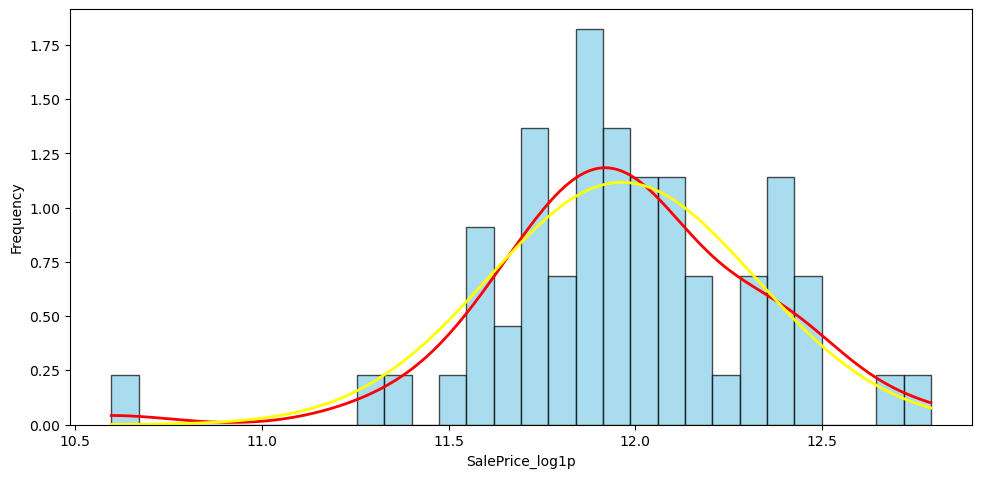

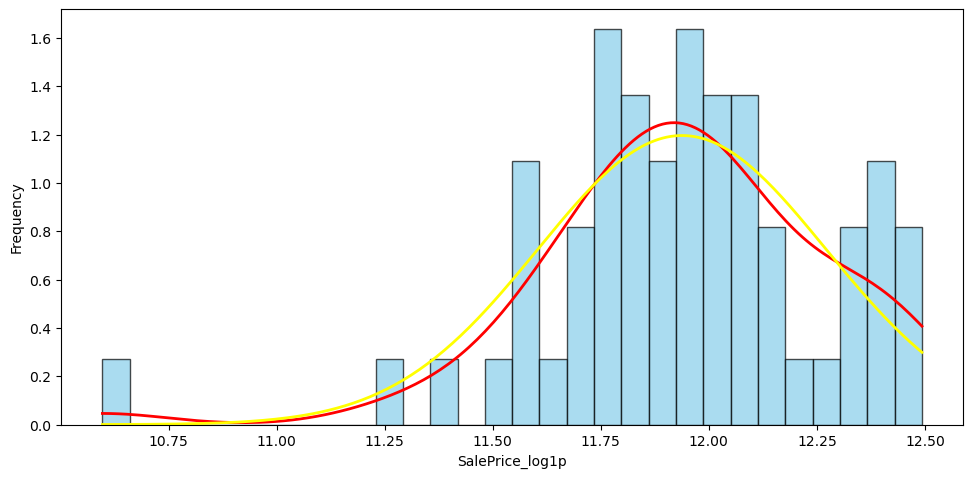

In [1621]:
# For MSSubClass = 70, there's probably an outliear causing the big residual. Let's check
X_msub, y_sub, _ = train_data_for_submission()
X_msub = X_msub.join(y_sub)
X_msub = X_msub[X_msub["MSSubClass"] == 70]
X_msub = fix_nulls(X_msub, X_msub)
X_msub = fix_invalid(X_msub)
show_distribution(X_msub, [LOGP_TARGET_COL])
# Observation
# MSSubClass == 70 has a big residual (mean values) and the distribution has a small value far from the media.
# Let's check removing it  and see what happen

X_msub = X_msub[X_msub[LOGP_TARGET_COL] < 12.6]

show_distribution(X_msub, [LOGP_TARGET_COL])


In [1620]:
X_train, y_train, _ = train_data_for_submission()
X_train = X_train.join(y_train)
X_train["MSSubClass"] = X_train["MSSubClass"].replace({75: 80, 40: 85, 180: 30})

# mssubclass_rem_idx = X_train[(X_train[LOGP_TARGET_COL] < 11.0) & (X_train["MSSubClass"] == 70)].index
# X_train = X_train.iloc[~X_train.index.isin(mssubclass_rem_idx)]
mssubclass_rem_idx = X_train[(X_train[LOGP_TARGET_COL] > 12.6) & (X_train["MSSubClass"] == 70)].index
X_train = X_train.iloc[~X_train.index.isin(mssubclass_rem_idx)]
y_train = X_train.pop(LOGP_TARGET_COL)

X_test = load_submission_data()
X_test["MSSubClass"] = X_test["MSSubClass"].replace({75: 80, 40: 85, 180: 30})

dfa_train, dfa_test = compare_target_and_pred(X_train, y_train, "MSSubClass", X_test)
dfa = join_distributions(dfa_train, dfa_test, "MSSubClass")
bad_pred = dfa[dfa["residual"].abs() >= 0.1].index.tolist()
print(bad_pred)
#dfa.info()
dfa

Train
Feature: MSSubClass
------------------------------
val: 60.0 (20.39%) - target mean: 12.3355 std: 0.2767 count: 293
val: 120.0 (6.05%) - target mean: 12.1716 std: 0.2752 count: 87
val: 20.0 (36.95%) - target mean: 12.0522 std: 0.3821 count: 531
val: 80.0 (5.01%) - target mean: 12.0210 std: 0.2582 count: 72
val: 70.0 (4.04%) - target mean: 11.9378 std: 0.3364 count: 58
val: 85.0 (1.67%) - target mean: 11.8916 std: 0.2101 count: 24
val: 50.0 (9.95%) - target mean: 11.8163 std: 0.3327 count: 143
val: 160.0 (4.38%) - target mean: 11.8072 std: 0.2621 count: 63
val: 90.0 (3.34%) - target mean: 11.7768 std: 0.2070 count: 48
val: 190.0 (2.09%) - target mean: 11.7349 std: 0.2849 count: 30
val: 45.0 (0.77%) - target mean: 11.5977 std: 0.1875 count: 11
val: 30.0 (5.36%) - target mean: 11.4493 std: 0.2795 count: 77
                              
Value count: 12
Total count: 1437
------------------------------
Subm
Feature: MSSubClass
------------------------------
val: 60.0 (18.92%) - target

,porc_train,porc_test,tg_mean_train,tg_mean_test,std_train,std_test,residual
val,,,,,,,
20,0.369520,0.372173,12.052224,12.067348,0.382067,0.382806,0.015123
30,0.053584,0.052776,11.449269,11.465221,0.279538,0.275486,0.015952
45,0.007655,0.004112,11.597712,11.618930,0.187534,0.169760,0.021218
50,0.099513,0.098012,11.816312,11.728108,0.332689,0.228277,-0.088204
60,0.203897,0.189171,12.335466,12.336701,0.276685,0.278831,0.001235
70,0.040362,0.046607,11.937783,11.841272,0.336434,0.248119,-0.096511
80,0.050104,0.045922,12.020979,12.017381,0.258153,0.200561,-0.003597
85,0.016701,0.020562,11.891633,11.842112,0.210144,0.149493,-0.049520
90,0.033403,0.039068,11.776786,11.877002,0.206962,0.288441,0.100215


#### OverallCond distribution


In [1638]:
cat_col = "OverallCond"
X_train, y_train, _ = train_data_for_submission()
X_train = X_train.join(y_train)
y_train = X_train.pop(LOGP_TARGET_COL)

X_test = load_submission_data()

dfa_train, dfa_test = compare_target_and_pred(X_train, y_train, cat_col, X_test)
dfa = join_distributions(dfa_train, dfa_test, cat_col)
bad_pred = dfa[dfa["residual"].abs() >= 0.1].index.tolist()
print(bad_pred)
#dfa.info()
dfa

# Observations
# 1, 2 and have very few values and a big mean residual
# trying:
# 1,2 => 3
# 9 => 8


Train
Feature: OverallCond
------------------------------
val: 9.0 (1.51%) - target mean: 12.1989 std: 0.4094 count: 22
val: 5.0 (56.18%) - target mean: 12.1427 std: 0.3891 count: 818
val: 7.0 (14.08%) - target mean: 11.9214 std: 0.3096 count: 205
val: 8.0 (4.95%) - target mean: 11.9094 std: 0.2940 count: 72
val: 6.0 (17.24%) - target mean: 11.8835 std: 0.3032 count: 251
val: 4.0 (3.91%) - target mean: 11.6453 std: 0.3396 count: 57
val: 2.0 (0.34%) - target mean: 11.5934 std: 0.7295 count: 5
val: 3.0 (1.72%) - target mean: 11.4385 std: 0.4491 count: 25
val: 1.0 (0.07%) - target mean: 11.0186 std: nan count: 1
                              
Value count: 9
Total count: 1456
------------------------------
Subm
Feature: OverallCond
------------------------------
val: 5.0 (56.48%) - target mean: 12.1608 std: 0.3887 count: 824
val: 9.0 (1.30%) - target mean: 12.0300 std: 0.3742 count: 19
val: 8.0 (4.93%) - target mean: 11.8955 std: 0.2685 count: 72
val: 6.0 (19.12%) - target mean: 11.8630 st

,porc_train,porc_test,tg_mean_train,tg_mean_test,std_train,std_test,residual
val,,,,,,,
1,0.000687,0.004112,11.018646,11.293910,NaN,0.160642,0.275264
2,0.003434,0.003427,11.593364,11.455311,0.729507,0.417144,-0.138053
3,0.017170,0.017135,11.438478,11.435206,0.449067,0.377165,-0.003271
4,0.039148,0.030158,11.645297,11.624049,0.339602,0.354838,-0.021248
5,0.561813,0.564770,12.142719,12.160774,0.389104,0.388668,0.018055
6,0.172390,0.191227,11.883480,11.862977,0.303177,0.244412,-0.020503
7,0.140797,0.126799,11.921365,11.849801,0.309639,0.261553,-0.071565
8,0.049451,0.049349,11.909398,11.895507,0.293961,0.268450,-0.013892
9,0.015110,0.013023,12.198872,12.030044,0.409416,0.374223,-0.168827


In [1770]:

X_ovcond = X_train.join(y_train)
pms1 = mann_whitney_test(X_ovcond, "OverallCond", LOGP_TARGET_COL, 1, 2) # -> Closer in mean
pms2 = mann_whitney_test(X_ovcond, "OverallCond", LOGP_TARGET_COL, 1, 3) # -> Closer in mean
pms3 = mann_whitney_test(X_ovcond, "OverallCond", LOGP_TARGET_COL, 2, 3) # -> Closer in mean
pms4 = mann_whitney_test(X_ovcond, "OverallCond", LOGP_TARGET_COL, 9, 5) # -> Closer in mean

------------------------------
  1 → n=1, mean=11.019, std=nan
  2 → n=5, mean=11.593, std=0.730
  p-value: 0.3333
                              
p-value (0.3333333333333333) > alpha (0.05)
Distributions NOT significantly different → Safe to merge
                              
------------------------------
  1 → n=1, mean=11.019, std=nan
  3 → n=25, mean=11.438, std=0.449
  p-value: 0.3506
                              
p-value (0.35056552509793704) > alpha (0.05)
Distributions NOT significantly different → Safe to merge
                              
------------------------------
  2 → n=5, mean=11.593, std=0.730
  3 → n=25, mean=11.438, std=0.449
  p-value: 0.9556
                              
p-value (0.9556068921485581) > alpha (0.05)
Distributions NOT significantly different → Safe to merge
                              
------------------------------
  9 → n=22, mean=12.199, std=0.409
  5 → n=818, mean=12.143, std=0.389
  p-value: 0.7880
                              
p-value

#### MSZoning distribution (*)

In [499]:
def fix_c_bias(X, bias_fix=-0.14350891607349783):
  X = X.copy()
  mszc_idx = X[X["MSZoning"] == "C"].index
  X.loc[mszc_idx, LOGP_TARGET_COL] += bias_fix
  return X

cat_col = "MSZoning"
X_train, y_train, _ = train_data_for_submission()
X_train = X_train.join(y_train)
y_train = X_train.pop(LOGP_TARGET_COL)

X_test = load_submission_data()
X_test = fix_invalid(X_test)
X_test = fix_nulls(X_test, X_train)

dfa_train, dfa_test = compare_target_and_pred(X_train, y_train, cat_col, X_test, fix_bias_functions=[fix_c_bias])
dfa = join_distributions(dfa_train, dfa_test, cat_col)
bad_pred = dfa[dfa["residual"].abs() >= 0.1].index.tolist()
print("Worse predictions:", bad_pred)
#dfa.info()
dfa

{'name': 'Ridge', 'abrev': 'Rig', 'instance': Ridge(alpha=10.0)}
Train
Feature: MSZoning
------------------------------
val: FV (4.46%) - target mean: 12.2466 std: 0.2311 coef.var: 1.8872 count: 65
val: RL (78.78%) - target mean: 12.0834 std: 0.3728 coef.var: 3.0853 count: 1147
val: RH (1.10%) - target mean: 11.7498 std: 0.2892 coef.var: 2.4612 count: 16
val: RM (14.97%) - target mean: 11.6929 std: 0.3156 coef.var: 2.6991 count: 218
val: C (0.69%) - target mean: 11.1183 std: 0.4850 coef.var: 4.3621 count: 10
                              
Value count: 5
Total count: 1456
------------------------------
Subm
Feature: MSZoning
------------------------------
val: FV (5.07%) - target mean: 12.2734 std: 0.2122 coef.var: 1.7287 count: 74
val: RL (76.63%) - target mean: 12.0784 std: 0.3692 coef.var: 3.0571 count: 1118
val: RH (0.69%) - target mean: 11.8701 std: 0.2420 coef.var: 2.0388 count: 10
val: RM (16.59%) - target mean: 11.6903 std: 0.2872 coef.var: 2.4566 count: 242
val: C (1.03%) - tar

,porc_train,porc_test,tg_mean_train,tg_mean_test,std_train,std_test,residual
val,,,,,,,
C,0.006868,0.010281,11.118275,11.264894,0.484993,0.248720,0.146618
FV,0.044643,0.050720,12.246621,12.273440,0.231114,0.212171,0.026819
RH,0.010989,0.006854,11.749848,11.870072,0.289182,0.242002,0.120225
RL,0.787775,0.766278,12.083431,12.078390,0.372812,0.369246,-0.005041
RM,0.149725,0.165867,11.692901,11.690265,0.315603,0.287186,-0.002636


In [1811]:

X_ana = X_train.join(y_train)
pv1 = mann_whitney_test(X_ana, "MSZoning", LOGP_TARGET_COL, "C","RM") # -> Closer in mean
pv2 = mann_whitney_test(X_ana, "MSZoning", LOGP_TARGET_COL, "C","RH") # -> Other 
pv3 = mann_whitney_test(X_ana, "MSZoning", LOGP_TARGET_COL, "RH","RM") # -> Closer 
pv4 = mann_whitney_test(X_ana, "MSZoning", LOGP_TARGET_COL, "RH","RL") # -> Closer 

# Observations
# It safe to merge (In theory) RH and RM, but C is the real problem here.
# and it is very different from others. Maybe the best solution is TargetEncoding
# Let's update the pipeline and test.


------------------------------
  C → n=10, mean=11.118, std=0.485
  RM → n=218, mean=11.693, std=0.316
  p-value: 0.0002
                              
p-value (0.00020198933013099382) < alpha (0.05)
Distributions ARE different → Merging may lose signal
                              
------------------------------
  C → n=10, mean=11.118, std=0.485
  RH → n=16, mean=11.750, std=0.289
  p-value: 0.0020
                              
p-value (0.0020441072931519726) < alpha (0.05)
Distributions ARE different → Merging may lose signal
                              
------------------------------
  RH → n=16, mean=11.750, std=0.289
  RM → n=218, mean=11.693, std=0.316
  p-value: 0.2432
                              
p-value (0.24318666611092488) > alpha (0.05)
Distributions NOT significantly different → Safe to merge
                              
------------------------------
  RH → n=16, mean=11.750, std=0.289
  RL → n=1147, mean=12.083, std=0.373
  p-value: 0.0005
                      

Now, let see what happens when using a XGBClassifier to differenciate Train Vs Test distributions

### ROC AUC / Using XGBClassifier


In [755]:
from sklearn.metrics import roc_auc_score
    # ("init_drop", DropTransformation(columns=[LOGP_TARGET_COL, TARGET_COL, "Id"])),
    # ("fix_nulls", FixNullsTransformation()),
    # ("fix_invalid", FixInvalidTransformation()),
    # ("replace_uncommon", ReplaceUncommonTransformation()),
    # ("binary", BinaryTransformation(bin_cols, bin_cols_spec)),
    # ("drop", DropTransformation(columns=ignored_cols)),
    # ("encode", CategoryTransformation(ignored_cols=[], ord_cols=ord_cols_used, ord_cat_maps=ORD_COLS_VALUES)),
    # ("eng_features", EngTransformation(eng_transf)),
    # ("log1p", Log1PTransformation(columns=log1p_cols)),
    # ("sqrt", SqrtTransformation(columns=sqrt_cols)),
    # ("std_scaler", StandardScalerTransformation(norm_cols)),
def create_dist_pipeline(ignored_cols, ord_cols_used, eng_transf, model=None):
  #bin_cols, bin_cols_spec, ignored_cols, ord_cols_used, log1p_cols, norm_cols, eng_transf, model=None):
  steps = [
    ("init_drop", DropTransformation(columns=[LOGP_TARGET_COL, TARGET_COL, "Id"])),
    ("fix_nulls", FixNullsTransformation()),
    ("fix_invalid", FixInvalidTransformation()),
    ("encode", ROCCategoryTransformation(ignored_cols=ignored_cols, ord_cols=ord_cols_used, ord_cat_maps=ORD_COLS_VALUES)),
    ("eng_features", EngTransformation(eng_transf)),
    ("log1p", Log1PTransformation(columns=log1p_cols)),
    ("sqrt", SqrtTransformation(columns=sqrt_cols)),
    ("std_scaler", StandardScalerTransformation(norm_cols)),
  ]
  if model is not None:
    print("Creating pipeline with model")
    steps.append(("model", model))

  return Pipeline(steps)
###################

X_train, _, _ = train_data_for_submission()
X_test = load_submission_data()
X_train.drop(columns=["Id"], inplace=True, errors="ignore")
X_test.drop(columns=["Id"], inplace=True, errors="ignore")
X_test = fix_nulls(dfsub, X)

X_all = pd.concat([X_train, X_test], axis=0)
# y = 0 for train, 1 when x in test
y_all = np.array([0] * X_train.shape[0] + [1] * X_test.shape[0])

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
xgbclass = XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1, tree_method="hist", enable_categorical=True)
pip = create_dist_pipeline(ignored_cols, ord_cols_used, create_eng_features, xgbclass)
result = cross_validate(pip, X_all, y_all, cv=cv, scoring="roc_auc", error_score="raise", return_estimator=True)

scores = result["test_score"]
estimator = result["estimator"]

print("AUC", scores.mean(), scores.std()) 

# Observations
# AUC doesn't show a big difference between train and test distribution, so it is not the main reason of the big difference between CV and Kaggle score. 




Creating pipeline with model
AUC 0.5428182988076207 0.022402682021560313


In [812]:
df_res = pd.DataFrame({"feature": estimator[0]["model"].get_booster().feature_names})
for i, e in enumerate(estimator):
  df_res[f"feat_imp_cv{i}"] = e["model"].feature_importances_

df_res

,feature,feat_imp_cv0,feat_imp_cv1,feat_imp_cv2,feat_imp_cv3,feat_imp_cv4
0,LotFrontage,0.020517,0.022405,0.025808,0.023711,0.025050
1,LotArea,0.016581,0.015389,0.016431,0.013755,0.014308
2,OverallQual,0.018180,0.022050,0.015410,0.018783,0.014522
3,OverallCond,0.013995,0.015506,0.009418,0.011225,0.020212
4,YearBuilt,0.014315,0.015077,0.015173,0.013481,0.015900
5,YearRemodAdd,0.016582,0.017018,0.017593,0.016554,0.015849
6,MasVnrArea,0.016373,0.014567,0.017167,0.016017,0.013932
7,BsmtFinSF1,0.017507,0.016757,0.017379,0.017233,0.017004
8,BsmtFinSF2,0.018257,0.017784,0.016166,0.020236,0.016962
9,BsmtUnfSF,0.017372,0.014351,0.019209,0.016581,0.014404


In [852]:
def compare_columns(cols):
    dfbase = get_base_data()
    dfsub = load_submission_data()
    desc_sub = dfsub.describe()[cols].add_suffix('_sub')
    desc_train = dfbase.describe()[cols].add_suffix('_train')
    result = desc_sub.join(desc_train)
    ordered_cols = []
    for col in cols:
        ordered_cols.append(f"{col}_sub")
        ordered_cols.append(f"{col}_train")
    return result[ordered_cols]


X, y, y_orig = train_data_for_submission()
X, ignored_cols, ord_cols_used, desc = initial_processing(X)
num_cols = [c for c in X.select_dtypes(include=[np.number]).columns.tolist() if c != LOGP_TARGET_COL and c != TARGET_COL]
num_cols = [c for c in num_cols if c not in ord_cols_used and c not in ["Id", "MSSubClass"]]


#compare_columns(num_cols)
dfcom = pd.DataFrame({"tr_n": get_base_data()["Neighborhood"], "te_n": load_submission_data()["Neighborhood"]})
dfcom["tr_n"].value_counts().shape
dfcom["te_n"].value_counts().shape

dfcom["tr_n"].value_counts()
trn_val = dfcom["tr_n"].unique().tolist()
tes_val = dfcom["te_n"].unique().tolist()
trn_val, tes_val



#[c for c in tes_val if c not in trn_val]
[c for c in trn_val if c not in tes_val]

ddf = pd.DataFrame({
"c_tr": dfcom["tr_n"].value_counts().sort_values(ascending=False),
"c_te": dfcom["te_n"].value_counts().sort_values(ascending=False)
})

ddf[ddf["c_tr"] < 10] # => Blueste, NPkVill

df_nei = X.join(y_orig)
df_nei = df_nei[df_nei["Neighborhood"].isin(["Blueste", "NPkVill"])]
#df_nei.columns
df_nei[["Neighborhood", "SalePrice"]]
print("Nb Mean:", df_nei["SalePrice"].mean(), "std:", df_nei["SalePrice"].std())
print("desc", df_nei.groupby("Neighborhood")["SalePrice"].describe())





Nb Mean: 141750.0 std: 10545.733734548772
desc               count           mean           std       min       25%  \
Neighborhood                                                           
Blueste         2.0  137500.000000  19091.883092  124000.0  130750.0   
NPkVill         9.0  142694.444444   9377.314529  127500.0  140000.0   

                   50%       75%       max  
Neighborhood                                
Blueste       137500.0  144250.0  151000.0  
NPkVill       146000.0  148500.0  155000.0  


## Process

In [985]:
list_models()



LiRe: Linear Regression
Lasso: Lasso
ENet: ElasticNet
Rig: Ridge
XBReg: XGBRegressor
Stk1: Stack1
Stk2: Stack2


In [652]:
X, y, y_orig = train_data_for_submission()
X, pip_config, desc = initial_processing(X)

pip_res = create_pipeline(pip_config)
X, y = remove_residuals(X, y, pip_res[0], model=get_model("Rig"))

df_submit = pd.read_csv("./data/test.csv")

# Removing this rows improves score a little bit (as in CV)
df_submit.loc[df_submit["GrLivArea"] > 4000, ["GrLivArea"]] = 3999

# Create the transformation pipeline tuple. 0 for linear, 1 for tree models.
trans_pips = create_pipeline(pip_config)

use_generic_build = False
apply_msz_c_fix = False

model = None
if use_generic_build:
  # Create the full pipeline for stack model 
  # Early stopping for XGBRegressor is computed at tunning time
  print("Using Generic Pipeline Build")
  model = build_full_pipeline(trans_pips, "Stk1")
else:
  print("Using Specific function Pipeline Build")
  model = create_stack_1(trans_pips)
model.fit(X, y)

submit_id = df_submit.pop("Id")
pred = pd.Series(model.predict(df_submit), index=df_submit.index)
if apply_msz_c_fix:
  tpip = trans_pips[1]
  tsub = tpip.fit(X, y).transform(df_submit)
  # From previous analysis
  # bias_fix = -0.14350891607349783 # --> Smoothing = 10
  # bias_fix = -0.22221418555002978 # --> Smoothing = 5
  # bias_fix = -0.053438182666177475  # --> Smoothing = 12
  # bias_fix = -0.03386952465990546 # --> Smoothing = 15
  # bias_fix = 0.0030934960186083313 # --> Smoothing = 25
  # bias_fix = 0.013654359069612265 # --> Smoothing = 30
  bias_fix = 0.027735509804284172 # --> Smoothing = 40!
  mszc_idx = tsub[tsub["MSZoning"] == "C"].index
  pred[mszc_idx] += bias_fix
  print("Applying MSZoning bias fix for category 'C' to ", pred[mszc_idx].shape[0], " rows")



print("pred std", pred.std())
pred = pd.concat({"Id": submit_id, "SalePrice": np.expm1(pred)}, axis=1)  # Inverse log1p transformation

save_submission(pred)
pred.head()


{'name': 'Ridge', 'abrev': 'Rig', 'instance': Ridge(alpha=10.0)}
Using Specific function Pipeline Build
pred std 0.38905188609000446


,Id,SalePrice
0,1461,124148.079162
1,1462,157880.830901
2,1463,189447.863375
3,1464,200436.632230
4,1465,181813.909726


In [474]:
# Comparing with previous submission.
dfs = pd.read_csv("./submissions/submission_260527_1649.csv")
dfs_af = pd.read_csv("./submissions/submission_260527_1716.csv") 
dfs = dfs.join(dfs_af, lsuffix="_bef", rsuffix="_aft").drop(columns=["Id_aft"], errors="ignore").rename(columns={"Id_bef": "Id"})
dfs["delta"] = dfs["SalePrice_aft"] - dfs["SalePrice_bef"]

print("Submission Delta mean:", dfs["delta"].mean())
print("Submission Delta median:", dfs["delta"].median())


#dfs.head(20)

#print(dfs_af[dfs_af["Id"] == 1559])
print("Selected rows", dfs[dfs["delta"] != 0.0].shape[0])
dfs[dfs["delta"] != 0.0]



Submission Delta mean: -110.43523411530522
Submission Delta median: 0.0
      Id     SalePrice
98  1559  63236.106139
Selected rows 15


,Id,SalePrice_bef,SalePrice_aft,delta
98,1559,72994.673143,63236.106139,-9758.567005
142,1603,91367.018033,79152.308754,-12214.709279
359,1820,62100.470169,53798.315649,-8302.154520
362,1823,53165.735887,46058.038510,-7107.697378
453,1914,67920.148578,58839.979153,-9080.169425
757,2218,84600.344064,73290.250613,-11310.093451
758,2219,77988.805216,67562.588056,-10426.217159
759,2220,81921.417673,70969.461651,-10951.956022
1119,2580,104208.269960,90276.853211,-13931.416749
1120,2581,113265.509943,98123.258641,-15142.251302


In [977]:

df_n = pd.read_csv("./submissions/submission_260417_2305.csv")
df_n.iloc[1458]

Id             2919.000000
SalePrice    219609.913466
Name: 1458, dtype: float64